**Temporal Trend Analysis**

Mounted at /content/drive
Found documents: 6152
Processed 1/6152 docs... | years_collected=1 | unknown_year_docs=0
Processed 200/6152 docs... | years_collected=23 | unknown_year_docs=0
Processed 400/6152 docs... | years_collected=59 | unknown_year_docs=0
Processed 600/6152 docs... | years_collected=80 | unknown_year_docs=1
Processed 800/6152 docs... | years_collected=96 | unknown_year_docs=1
Processed 1000/6152 docs... | years_collected=108 | unknown_year_docs=1
Processed 1200/6152 docs... | years_collected=114 | unknown_year_docs=1
Processed 1400/6152 docs... | years_collected=121 | unknown_year_docs=2
Processed 1600/6152 docs... | years_collected=124 | unknown_year_docs=2
Processed 1800/6152 docs... | years_collected=128 | unknown_year_docs=2
Processed 2000/6152 docs... | years_collected=132 | unknown_year_docs=2
Processed 2200/6152 docs... | years_collected=135 | unknown_year_docs=2
Processed 2400/6152 docs... | years_collected=139 | unknown_year_docs=2
Processed 2600/6152 docs... |

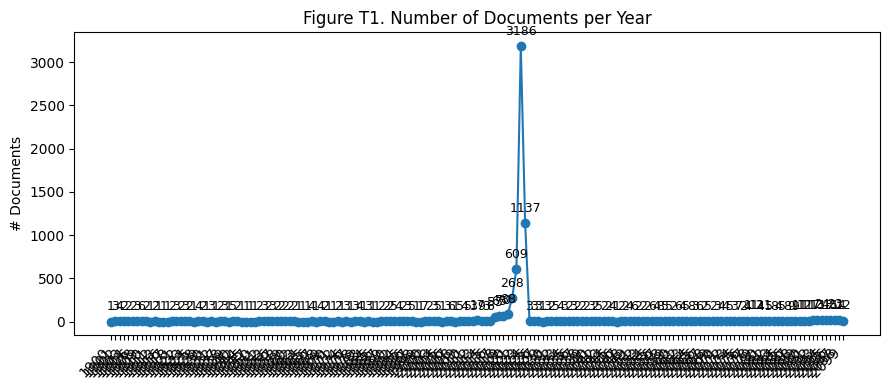


Saved figure:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_240126/Figure_T1_docs_per_year.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_240126/Figure_T1_docs_per_year.pdf


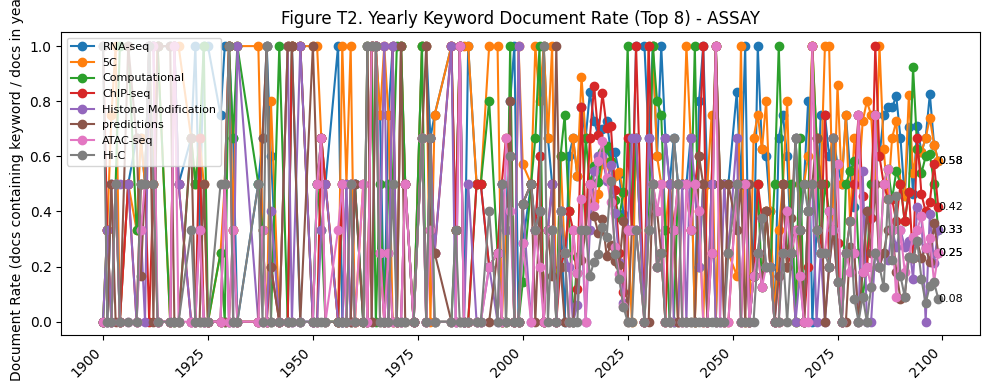


Saved figure:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_240126/Figure_T2_docrate_top8_ASSAY.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_240126/Figure_T2_docrate_top8_ASSAY.pdf


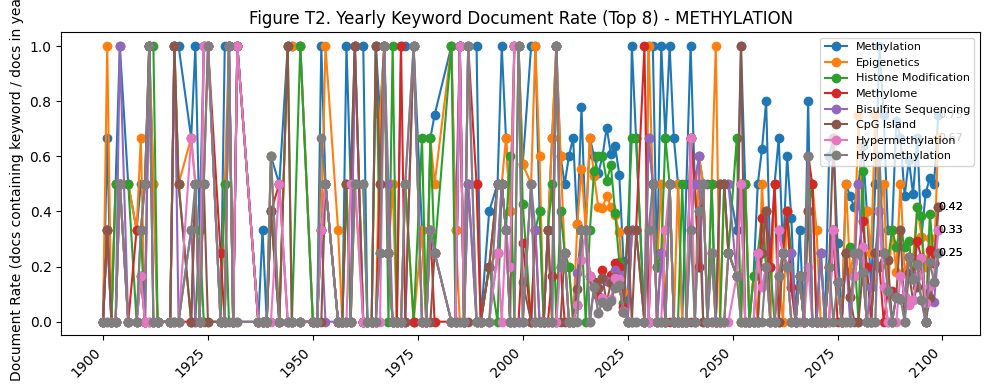


Saved figure:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_240126/Figure_T2_docrate_top8_METHYLATION.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_240126/Figure_T2_docrate_top8_METHYLATION.pdf


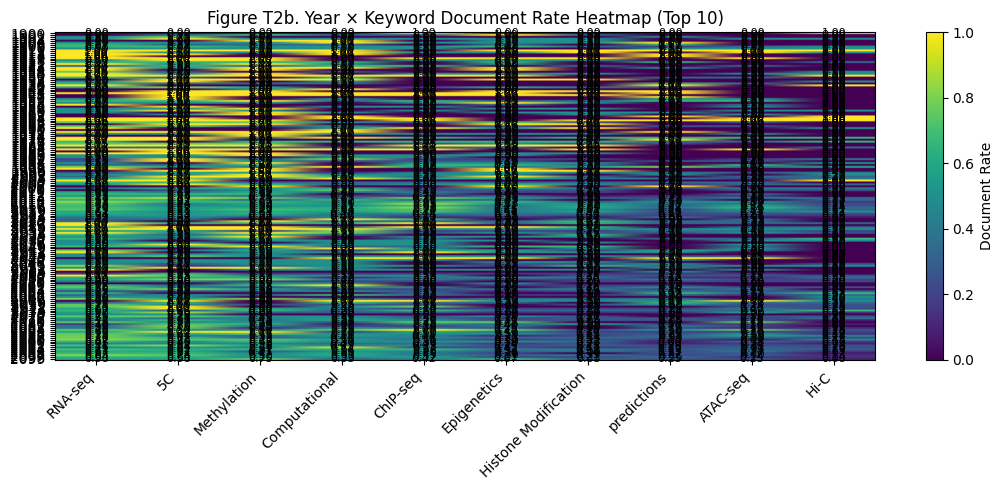


Saved figure:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_240126/Figure_T2b_heatmap_year_x_keyword_docrate_top10.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_240126/Figure_T2b_heatmap_year_x_keyword_docrate_top10.pdf


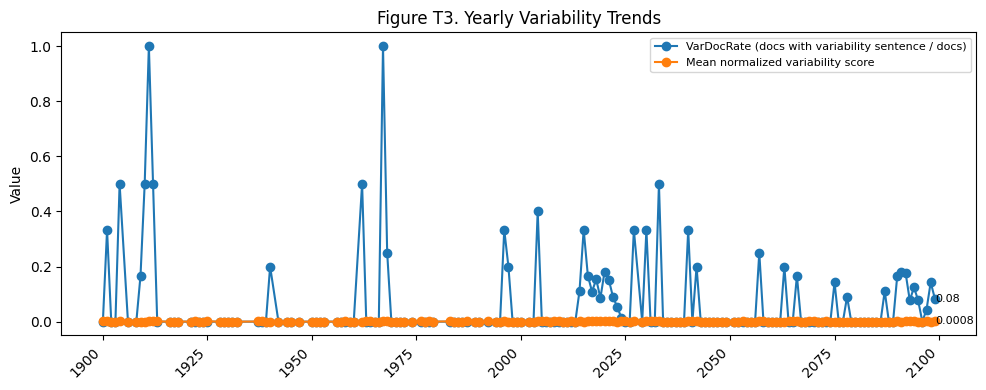


Saved figure:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_240126/Figure_T3_variability_trends.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_240126/Figure_T3_variability_trends.pdf

DONE. Output folder:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_240126


In [ ]:
# =========================================
# Colab: Temporal Trend Analysis for Epigenomics Full-text Corpus (.txt folder)
# - Reads all .txt files in a folder (1 file = 1 document)
# - Extracts document year (tries: filename -> text metadata)
# - Computes:
#   (T1) #docs per year
#   (T2) keyword doc-rate per year: #(docs containing kw)/#(docs in year)
#        + (optional) keyword TF per year
#   (T3) variability trend per year:
#        - VarDocRate: #(docs with variability sentence)/#docs
#        - mean normalized variability score per year
# - Saves: CSVs + paper-ready figures (PNG 600dpi + PDF vector)
# - Figures:
#   Figure T1: Docs per year (line + value labels)
#   Figure T2: Top-N keyword doc-rate lines + last-point value labels
#   Figure T2b: Year × keyword doc-rate heatmap (cell values)
#   Figure T3: Variability trends per year (2 lines + value labels)
# =========================================

# 0) Google Drive mount (Colab)
from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) PATHS
# =========================
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR    = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_240126"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) KEYWORDS (너 연구 키워드 세트)
# =========================
assay_keywords = [
    "5C", "ChIA-PET", "Hi-C", "DNase-seq", "FAIRE-seq", "ATAC-seq", "ChIP-seq",
    "WGBS", "RRBS", "methylation array", "Computational", "predictions",
    "RNA-seq", "CLIP-seq", "RIP-seq", "Histone Modification"
]

methylation_keywords = [
    "Methylation", "CpG Island", "Hypermethylation", "Hypomethylation",
    "Epigenetics", "Histone Modification", "Gene Silencing", "DNMT",
    "Methylome", "Bisulfite Sequencing"
]

# Variability patterns (네가 기존에 쓰던 것)
variability_patterns = [
    "chromatin variability",
    "chromatin heterogeneity",
    "dynamic chromatin",
    "chromatin plasticity",
    "chromatin state variation",
    "epigenetic variability",
    "epigenetic plasticity",
    "epigenetic heterogeneity"
]

# Variability score terms (literature-based variability score용)
variability_terms = ["variability", "heterogeneity", "dynamic", "plasticity"]

# 분석 대상 키워드 묶음(원하면 하나만 써도 됨)
KEYWORD_GROUPS = {
    "ASSAY": assay_keywords,
    "METHYLATION": methylation_keywords,
}

# =========================
# 3) PARAMETERS
# =========================
PROGRESS_EVERY = 200

# Top-N keyword lines in Figure T2 (그룹별로 각각 top N 뽑음)
TOP_N_PER_GROUP = 8

# Heatmap size: Year × keyword (그룹 합쳐서 top K만)
HEATMAP_TOP_K = 10

# (속도/정확도 옵션)
COMPUTE_TF = False  # True면 연도별 TF도 저장(느려질 수 있음)

# =========================
# 4) HELPERS
# =========================
YEAR_RE = re.compile(r"(19\d{2}|20\d{2})")

def load_txt_file(fp: str) -> str:
    with open(fp, "r", encoding="utf-8", errors="ignore") as f:
        return f.read()

def extract_year_from_filename(filename: str):
    # 파일명에 4자리 연도가 있으면 우선 채택
    m = YEAR_RE.search(filename)
    if m:
        y = int(m.group(1))
        if 1900 <= y <= 2100:
            return y
    return None

def extract_year_from_text(text: str):
    """
    본문에서 'Published/Received/Accepted/©' 근처 연도 우선 탐색.
    완벽하지 않으므로, 가능한 경우 PMID-Year 매핑 같은 메타데이터 조인이 최선.
    """
    t = text.lower()

    # 1) 메타 키워드 주변 연도 (우선순위)
    patterns = [
        r"(published|publication|received|accepted|revised|copyright|©)\D{0,50}((19\d{2}|20\d{2}))",
        r"((19\d{2}|20\d{2}))\D{0,50}(published|publication|received|accepted|revised|copyright|©)"
    ]
    for p in patterns:
        m = re.search(p, t)
        if m:
            # 캡쳐 그룹에서 연도만 골라내기
            ys = YEAR_RE.findall(m.group(0))
            if ys:
                y = int(ys[0])
                if 1900 <= y <= 2100:
                    return y

    # 2) 그냥 아무 연도나(마지막 fallback) — 잡음 가능
    ys = YEAR_RE.findall(t)
    if ys:
        # 너무 옛날 연도(예: 19xx references)도 섞일 수 있어 최근값 우선
        candidates = [int(x) for x in ys if 1900 <= int(x) <= 2100]
        if candidates:
            return max(candidates)  # 가장 최근 연도
    return None

def safe_count_occurrences(text_lower: str, kw_lower: str) -> int:
    # 간단 count (정확한 토큰 매칭은 아니지만 대용량에 안정적)
    return text_lower.count(kw_lower)

def doc_contains(text_lower: str, kw_lower: str) -> bool:
    return kw_lower in text_lower

def split_sentences_simple(text_lower: str):
    # 대용량 안정용 단순 분리
    return re.split(r"(?<=[.!?])\s+", text_lower)

# =========================
# 5) FILE LIST
# =========================
files = [fn for fn in sorted(os.listdir(CORPUS_DIR)) if fn.lower().endswith(".txt")]
total_files = len(files)
print("Found documents:", total_files)

# =========================
# 6) ACCUMULATORS (year → stats)
# =========================
docs_per_year = Counter()
unknown_year_files = 0

# group -> year -> keyword -> doc_count_with_kw
doc_with_kw = {g: defaultdict(Counter) for g in KEYWORD_GROUPS.keys()}

# (optional) group -> year -> keyword -> TF_sum
tf_sum = {g: defaultdict(Counter) for g in KEYWORD_GROUPS.keys()}

# variability per year
var_docs_per_year = Counter()  # docs with ≥1 variability sentence
var_score_sum_per_year = defaultdict(float)
var_doclen_tokens_sum_per_year = defaultdict(int)  # for optional normalization check
var_doc_count_per_year = Counter()

# =========================
# 7) MAIN LOOP
# =========================
for i, fn in enumerate(files, 1):
    fp = os.path.join(CORPUS_DIR, fn)
    text = load_txt_file(fp)
    text_lower = text.lower()

    # --- year extraction (filename -> text) ---
    year = extract_year_from_filename(fn)
    if year is None:
        year = extract_year_from_text(text)

    if year is None:
        unknown_year_files += 1
        # year가 없으면 연도 분석에 넣기 어렵기 때문에 제외(원하면 별도 처리 가능)
        # 여기서는 skip
        if i % PROGRESS_EVERY == 0 or i == 1 or i == total_files:
            print(f"Processed {i}/{total_files} docs... | unknown_year_docs={unknown_year_files}")
        continue

    docs_per_year[year] += 1

    # --- keyword doc-rate stats ---
    for group_name, kws in KEYWORD_GROUPS.items():
        for kw in kws:
            kw_lower = kw.lower()
            if doc_contains(text_lower, kw_lower):
                doc_with_kw[group_name][year][kw] += 1
                if COMPUTE_TF:
                    tf_sum[group_name][year][kw] += safe_count_occurrences(text_lower, kw_lower)

    # --- variability trends ---
    var_doc_count_per_year[year] += 1

    # doc-level normalized variability score
    score = 0
    for vt in variability_terms:
        score += safe_count_occurrences(text_lower, vt.lower())

    # normalized by token count
    tok_count = max(1, len(text_lower.split()))
    norm_score = score / tok_count
    var_score_sum_per_year[year] += norm_score
    var_doclen_tokens_sum_per_year[year] += tok_count

    # variability sentence existence
    sents = split_sentences_simple(text_lower)
    has_var_sent = any(any(pat in s for pat in [p.lower() for p in variability_patterns]) for s in sents)
    if has_var_sent:
        var_docs_per_year[year] += 1

    # progress
    if i % PROGRESS_EVERY == 0 or i == 1 or i == total_files:
        print(f"Processed {i}/{total_files} docs... | years_collected={len(docs_per_year)} | unknown_year_docs={unknown_year_files}")

print("\nDONE.")
print(" - Docs with extracted year:", sum(docs_per_year.values()))
print(" - Docs missing year:", unknown_year_files)
print(" - Year range:", (min(docs_per_year) if docs_per_year else None), "~", (max(docs_per_year) if docs_per_year else None))

# =========================
# 8) BUILD DATAFRAMES
# =========================
years_sorted = sorted(docs_per_year.keys())

# T1: docs per year
t1_df = pd.DataFrame({
    "year": years_sorted,
    "n_docs": [docs_per_year[y] for y in years_sorted]
})

# T2: doc-rate per year for each keyword
# Build group-wise doc-rate tables
docrate_tables = {}
tf_tables = {}

for group_name, kws in KEYWORD_GROUPS.items():
    # df: index=year, columns=keyword, values=doc_rate
    dr = pd.DataFrame(index=years_sorted, columns=kws, data=0.0)
    for y in years_sorted:
        denom = docs_per_year[y]
        for kw in kws:
            num = doc_with_kw[group_name][y].get(kw, 0)
            dr.at[y, kw] = (num / denom) if denom > 0 else 0.0
    docrate_tables[group_name] = dr

    if COMPUTE_TF:
        tf = pd.DataFrame(index=years_sorted, columns=kws, data=0)
        for y in years_sorted:
            for kw in kws:
                tf.at[y, kw] = int(tf_sum[group_name][y].get(kw, 0))
        tf_tables[group_name] = tf

# T3: variability trends per year
t3_df = pd.DataFrame({
    "year": years_sorted,
    "n_docs": [docs_per_year[y] for y in years_sorted],
    "var_docs": [var_docs_per_year.get(y, 0) for y in years_sorted],
    "var_doc_rate": [(var_docs_per_year.get(y, 0) / docs_per_year[y]) if docs_per_year[y] > 0 else 0.0 for y in years_sorted],
    "mean_normalized_variability_score": [(var_score_sum_per_year[y] / var_doc_count_per_year[y]) if var_doc_count_per_year[y] > 0 else 0.0 for y in years_sorted],
})

# =========================
# 9) SAVE CSVs
# =========================
t1_path = os.path.join(OUT_DIR, "T1_docs_per_year.csv")
t3_path = os.path.join(OUT_DIR, "T3_variability_trends_per_year.csv")
t1_df.to_csv(t1_path, index=False, encoding="utf-8-sig")
t3_df.to_csv(t3_path, index=False, encoding="utf-8-sig")

print("\nSaved:")
print(" -", t1_path)
print(" -", t3_path)

# Save doc-rate tables
for group_name, dr in docrate_tables.items():
    outp = os.path.join(OUT_DIR, f"T2_docrate_per_year_{group_name}.csv")
    dr.reset_index().rename(columns={"index": "year"}).to_csv(outp, index=False, encoding="utf-8-sig")
    print(" -", outp)

# Save TF tables if enabled
if COMPUTE_TF:
    for group_name, tf in tf_tables.items():
        outp = os.path.join(OUT_DIR, f"T2_TF_per_year_{group_name}.csv")
        tf.reset_index().rename(columns={"index": "year"}).to_csv(outp, index=False, encoding="utf-8-sig")
        print(" -", outp)

# =========================
# 10) FIGURES (600dpi PNG + PDF)
# =========================

# ---- Figure T1: Docs per year (line + value labels) ----
plt.figure(figsize=(9,4))
x = list(range(len(years_sorted)))
y = [docs_per_year[yr] for yr in years_sorted]

plt.plot(x, y, marker="o")
plt.xticks(x, years_sorted, rotation=45, ha="right")
plt.ylabel("# Documents")
plt.title("Figure T1. Number of Documents per Year")

y_max = max(y) if y else 1
base_offset = max(1, int(y_max * 0.03))

for i_pt, val in enumerate(y):
    plt.text(i_pt, val + base_offset, str(val), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
fig_t1_png = os.path.join(OUT_DIR, "Figure_T1_docs_per_year.png")
fig_t1_pdf = os.path.join(OUT_DIR, "Figure_T1_docs_per_year.pdf")
plt.savefig(fig_t1_png, dpi=600)
plt.savefig(fig_t1_pdf)
plt.show()

print("\nSaved figure:")
print(" -", fig_t1_png)
print(" -", fig_t1_pdf)

# ---- Figure T2: Top-N keyword doc-rate lines (group-wise) ----
# Top selection criterion: overall average doc-rate across years
for group_name, dr in docrate_tables.items():
    avg_rates = dr.mean(axis=0).sort_values(ascending=False)
    top_kws = list(avg_rates.head(TOP_N_PER_GROUP).index)

    plt.figure(figsize=(10,4))
    for kw in top_kws:
        series = dr[kw].values.tolist()
        plt.plot(years_sorted, series, marker="o", label=kw)

        # label last point value only (겹침 최소화)
        if len(series) > 0:
            last_val = series[-1]
            plt.text(years_sorted[-1], last_val, f"{last_val:.2f}", fontsize=8, va="center")

    plt.ylabel("Document Rate (docs containing keyword / docs in year)")
    plt.title(f"Figure T2. Yearly Keyword Document Rate (Top {TOP_N_PER_GROUP}) - {group_name}")
    plt.xticks(rotation=45, ha="right")
    plt.legend(loc="best", frameon=True, fontsize=8)
    plt.tight_layout()

    fig_t2_png = os.path.join(OUT_DIR, f"Figure_T2_docrate_top{TOP_N_PER_GROUP}_{group_name}.png")
    fig_t2_pdf = os.path.join(OUT_DIR, f"Figure_T2_docrate_top{TOP_N_PER_GROUP}_{group_name}.pdf")
    plt.savefig(fig_t2_png, dpi=600)
    plt.savefig(fig_t2_pdf)
    plt.show()

    print("\nSaved figure:")
    print(" -", fig_t2_png)
    print(" -", fig_t2_pdf)

# ---- Figure T2b: Heatmap (Year × Keyword doc-rate, top-K overall) ----
# combine all groups → pick top-K by average doc-rate
all_dr = None
for group_name, dr in docrate_tables.items():
    all_dr = dr.copy() if all_dr is None else pd.concat([all_dr, dr], axis=1)

# remove duplicate columns if any (e.g., "Histone Modification" exists in multiple groups)
all_dr = all_dr.loc[:, ~all_dr.columns.duplicated()]

top_cols = all_dr.mean(axis=0).sort_values(ascending=False).head(HEATMAP_TOP_K).index.tolist()
heat = all_dr[top_cols].copy()

plt.figure(figsize=(11, 5))
im = plt.imshow(heat.values, aspect="auto")
plt.xticks(range(len(top_cols)), top_cols, rotation=45, ha="right")
plt.yticks(range(len(years_sorted)), years_sorted)
plt.colorbar(im, label="Document Rate")
plt.title(f"Figure T2b. Year × Keyword Document Rate Heatmap (Top {HEATMAP_TOP_K})")

# cell values
for i_r in range(heat.shape[0]):
    for j_c in range(heat.shape[1]):
        val = float(heat.iat[i_r, j_c])
        plt.text(j_c, i_r, f"{val:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
fig_t2b_png = os.path.join(OUT_DIR, f"Figure_T2b_heatmap_year_x_keyword_docrate_top{HEATMAP_TOP_K}.png")
fig_t2b_pdf = os.path.join(OUT_DIR, f"Figure_T2b_heatmap_year_x_keyword_docrate_top{HEATMAP_TOP_K}.pdf")
plt.savefig(fig_t2b_png, dpi=600)
plt.savefig(fig_t2b_pdf)
plt.show()

print("\nSaved figure:")
print(" -", fig_t2b_png)
print(" -", fig_t2b_pdf)

# ---- Figure T3: Variability trends per year (2 lines + value labels) ----
plt.figure(figsize=(10,4))

var_doc_rate = t3_df["var_doc_rate"].values.tolist()
mean_var_score = t3_df["mean_normalized_variability_score"].values.tolist()

plt.plot(years_sorted, var_doc_rate, marker="o", label="VarDocRate (docs with variability sentence / docs)")
plt.plot(years_sorted, mean_var_score, marker="o", label="Mean normalized variability score")

# value labels: last point only (겹침 최소화)
if years_sorted:
    plt.text(years_sorted[-1], var_doc_rate[-1], f"{var_doc_rate[-1]:.2f}", fontsize=8, va="center")
    plt.text(years_sorted[-1], mean_var_score[-1], f"{mean_var_score[-1]:.4f}", fontsize=8, va="center")

plt.ylabel("Value")
plt.title("Figure T3. Yearly Variability Trends")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="best", frameon=True, fontsize=8)
plt.tight_layout()

fig_t3_png = os.path.join(OUT_DIR, "Figure_T3_variability_trends.png")
fig_t3_pdf = os.path.join(OUT_DIR, "Figure_T3_variability_trends.pdf")
plt.savefig(fig_t3_png, dpi=600)
plt.savefig(fig_t3_pdf)
plt.show()

print("\nSaved figure:")
print(" -", fig_t3_png)
print(" -", fig_t3_pdf)

print("\nDONE. Output folder:")
print(" -", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Found .txt files: 6152
Processed 1/6152 docs... kept=1
Processed 200/6152 docs... kept=193
Processed 400/6152 docs... kept=364
Processed 600/6152 docs... kept=536
Processed 800/6152 docs... kept=727
Processed 1000/6152 docs... kept=915
Processed 1200/6152 docs... kept=1106
Processed 1400/6152 docs... kept=1294
Processed 1600/6152 docs... kept=1486
Processed 1800/6152 docs... kept=1677
Processed 2000/6152 docs... kept=1872
Processed 2200/6152 docs... kept=2064
Processed 2600/6152 docs... kept=2421
Processed 2800/6152 docs... kept=2614
Processed 3000/6152 docs... kept=2808
Processed 3200/6152 docs... kept=3004
Processed 3400/6152 docs... kept=3197
Processed 3600/6152 docs... kept=3393
Processed 3800/6152 docs... kept=3576
Processed 4000/6152 docs... kept=3775
Processed 4200/6152 docs... kept=3973
Processed 4400/6152 docs... kept=4151
Processed 4600/6152 docs..

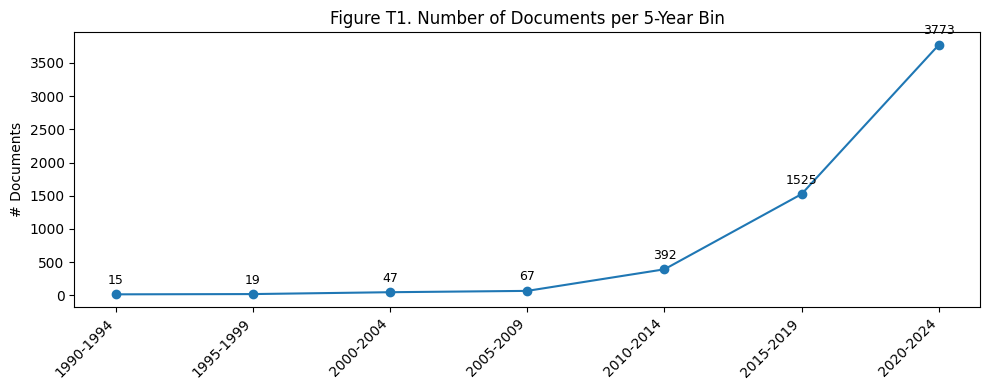

 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/FigureT1_docs_per_5yearbin.png
 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/FigureT1_docs_per_5yearbin.pdf


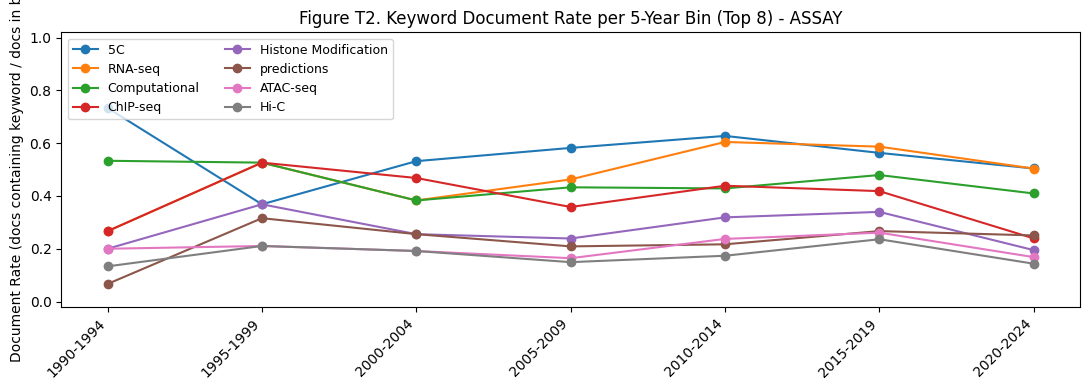

 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/FigureT2_assay_doc_rate_5yearbin_top8.png
 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/FigureT2_assay_doc_rate_5yearbin_top8.pdf


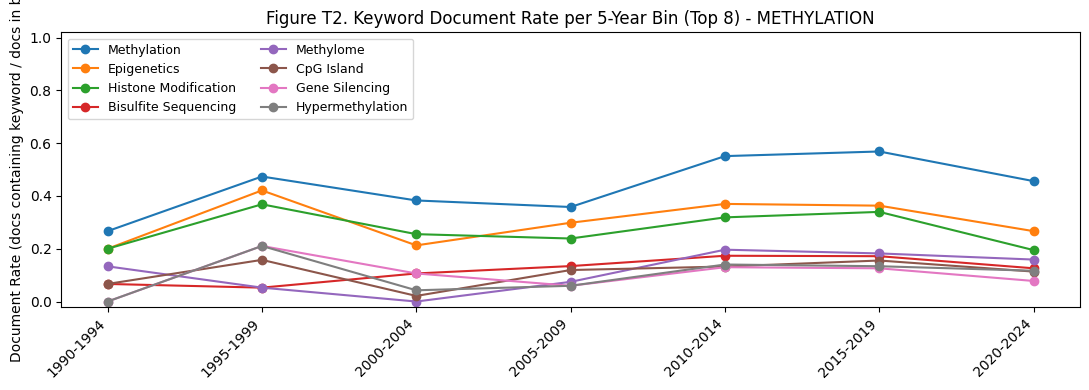

 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/FigureT2_methylation_doc_rate_5yearbin_top8.png
 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/FigureT2_methylation_doc_rate_5yearbin_top8.pdf


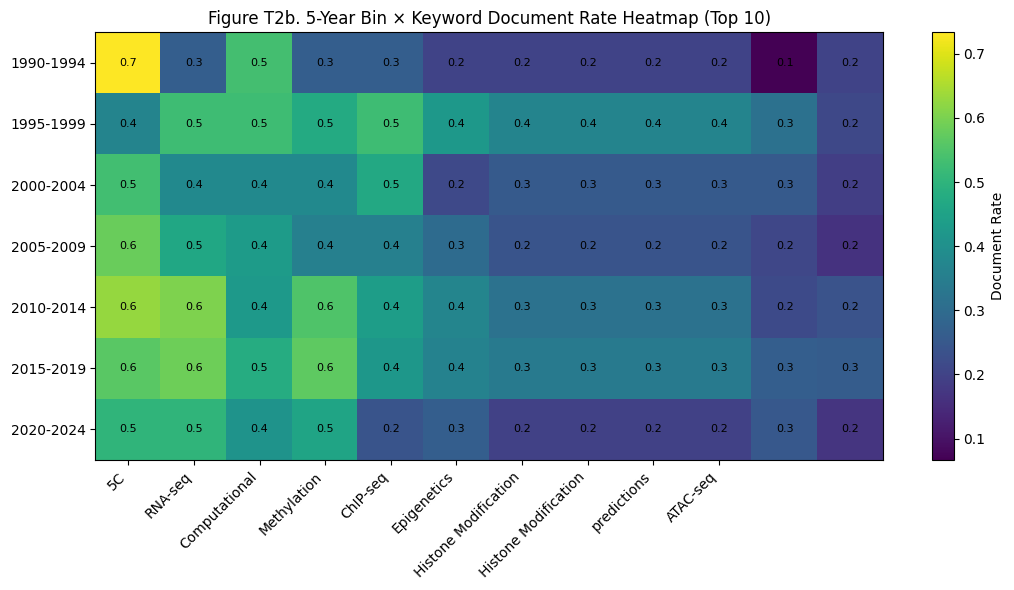

 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/FigureT2b_heatmap_keyword_rate_5yearbin_top10.png
 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/FigureT2b_heatmap_keyword_rate_5yearbin_top10.pdf


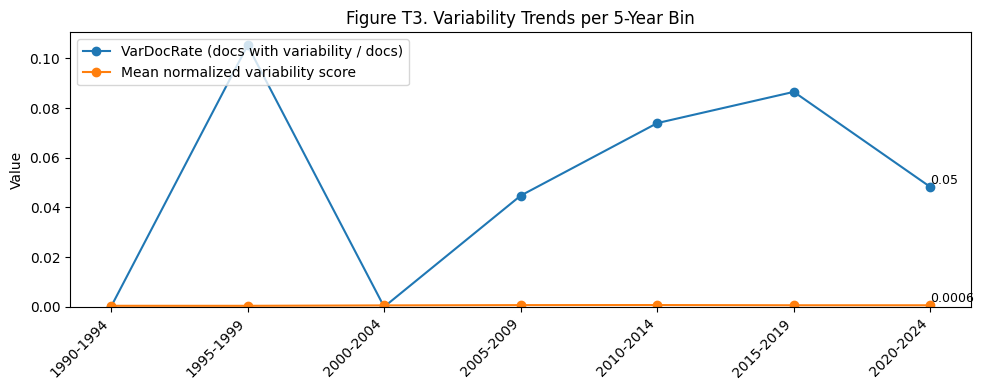

 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/FigureT3_variability_trend_5yearbin.png
 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/FigureT3_variability_trend_5yearbin.pdf

 DONE. Output folder:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add


In [ ]:
# =========================================
# Colab: Temporal Trend Analysis (Paper-ready, fixed)
# - Reads all .txt files in a folder (1 file = 1 document)
# - Extracts YEAR from (A) filename patterns or (B) text patterns
# - Cleans unrealistic years, bins years (e.g., 5-year)
# - Computes:
#   (T1) #docs per year/bin
#   (T2) keyword document rate per year/bin (Top K)
#   (T2b) heatmap: Year(bin) × Keyword rate (Top K) + in-cell values
#   (T3) variability trend:
#        (a) VarDocRate = docs with variability sentence / docs
#        (b) Mean normalized variability score per year/bin
# - Saves: CSVs + figures (PNG 600dpi + PDF vector)
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) PATHS
# =========================
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR    = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) KEYWORDS
# =========================
assay_keywords = [
    "5C", "ChIA-PET", "Hi-C", "DNase-seq", "FAIRE-seq", "ATAC-seq", "ChIP-seq",
    "WGBS", "RRBS", "methylation array", "Computational", "predictions",
    "RNA-seq", "CLIP-seq", "RIP-seq", "Histone Modification"
]

methylation_keywords = [
    "Methylation", "CpG Island", "Hypermethylation", "Hypomethylation",
    "Epigenetics", "Histone Modification", "Gene Silencing", "DNMT",
    "Methylome", "Bisulfite Sequencing"
]

# variability (T3)
variability_patterns = [
    "chromatin variability",
    "chromatin heterogeneity",
    "dynamic chromatin",
    "chromatin plasticity",
    "chromatin state variation",
    "epigenetic variability",
    "epigenetic plasticity",
    "epigenetic heterogeneity"
]

variability_terms_for_score = ["variability", "heterogeneity", "dynamic", "plasticity"]

# =========================
# 3) PARAMETERS (논문용 정리 핵심)
# =========================
# 분석 연도 범위 (현실적인 범위로 제한)
YEAR_MIN = 1990
YEAR_MAX = 2025

# 연도 binning (권장: 5년)
BIN_SIZE = 5

# 연도별 문서 수가 너무 적으면 비율이 0/1로 튀므로 컷
MIN_DOCS_PER_BIN = 10

# T2: 상위 몇 개 키워드만 그림에 그릴지
TOP_K_ASSAY = 8
TOP_K_METH  = 8
TOP_K_HEATMAP = 10  # T2b heatmap columns

PROGRESS_EVERY = 200

# =========================
# 4) HELPERS
# =========================
def normalize_text(t: str) -> str:
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

def load_txt_files_from_folder(folder_path: str):
    files = []
    for fn in sorted(os.listdir(folder_path)):
        if fn.lower().endswith(".txt"):
            fp = os.path.join(folder_path, fn)
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                files.append((fn, f.read()))
    return files

def extract_year_from_filename(fn: str):
    # 흔한 패턴: 2019, 2020...
    m = re.search(r"(19\d{2}|20\d{2})", fn)
    if m:
        return int(m.group(1))
    return None

def extract_year_from_text(text: str):
    # 텍스트 안에 "Published: 2019" / "© 2020" / "2018;" 등 다양한 경우가 있어
    # 너무 많이 잡히면 안 되므로 "19xx/20xx"를 모두 찾고 가장 그럴듯한 값을 선택
    years = re.findall(r"(19\d{2}|20\d{2})", text)
    if not years:
        return None
    years = [int(y) for y in years]
    # 후보 중 가장 많이 등장하는 연도를 대표값으로
    c = Counter(years)
    return c.most_common(1)[0][0]

def pick_doc_year(filename: str, text: str):
    y = extract_year_from_filename(filename)
    if y is None:
        y = extract_year_from_text(text)
    return y

def clamp_year(y):
    if y is None:
        return None
    if YEAR_MIN <= y <= YEAR_MAX:
        return y
    return None

def year_to_bin(y: int):
    # ex) 1990-1994 -> 1990, 1995-1999 -> 1995 ...
    start = (y // BIN_SIZE) * BIN_SIZE
    # YEAR_MIN 아래로 내려가지 않도록
    while start + BIN_SIZE - 1 < YEAR_MIN:
        start += BIN_SIZE
    return start

def contains_any_kw(text_lower: str, kws):
    return any(k.lower() in text_lower for k in kws)

def doc_contains_kw(text_lower: str, kw: str):
    return kw.lower() in text_lower

def variability_sentence_present(text_lower: str):
    return any(p.lower() in text_lower for p in variability_patterns)

def variability_score(text_lower: str):
    # corpus-level이 아니라 doc-level score
    return sum(text_lower.count(t) for t in variability_terms_for_score)

def normalized_variability_score(text_lower: str):
    n_words = max(1, len(text_lower.split()))
    return variability_score(text_lower) / n_words

# =========================
# 5) LOAD CORPUS
# =========================
docs = load_txt_files_from_folder(CORPUS_DIR)
print(" Found .txt files:", len(docs))

# =========================
# 6) BUILD DOC TABLE (year/bin + hits)
# =========================
rows = []
skipped_no_year = 0
skipped_out_of_range = 0

for i, (fn, text) in enumerate(docs, 1):
    text_norm = normalize_text(text)
    y = pick_doc_year(fn, text)
    y = clamp_year(y)

    if y is None:
        # 연도 파싱 실패 or 범위 밖
        # 원인을 구분하고 싶으면 아래처럼 체크
        y_raw = pick_doc_year(fn, text)
        if y_raw is None:
            skipped_no_year += 1
        else:
            skipped_out_of_range += 1
        continue

    ybin = year_to_bin(y)

    # keyword presence (doc-level)
    assay_present = {k: int(doc_contains_kw(text_norm, k)) for k in assay_keywords}
    meth_present  = {k: int(doc_contains_kw(text_norm, k)) for k in methylation_keywords}

    # variability (doc-level)
    var_doc = int(variability_sentence_present(text_norm))
    var_score_norm = normalized_variability_score(text_norm)

    row = {"file": fn, "year": y, "year_bin": ybin,
           "var_doc": var_doc,
           "var_score_norm": var_score_norm}

    # add keyword columns
    for k, v in assay_present.items():
        row[f"ASSAY__{k}"] = v
    for k, v in meth_present.items():
        row[f"METH__{k}"] = v

    rows.append(row)

    if i % PROGRESS_EVERY == 0 or i == 1 or i == len(docs):
        print(f"Processed {i}/{len(docs)} docs... kept={len(rows)}")

df = pd.DataFrame(rows)
print("\n Kept docs with valid years:", len(df))
print(" Skipped (no year):", skipped_no_year)
print(" Skipped (out of range):", skipped_out_of_range)

doc_table_path = os.path.join(OUT_DIR, "doc_table_year_keywords_variability.csv")
df.to_csv(doc_table_path, index=False, encoding="utf-8-sig")
print(" Saved doc table:", doc_table_path)

# =========================
# 7) AGGREGATE BY YEAR_BIN
# =========================
# docs per bin
bin_counts = df.groupby("year_bin").size().rename("n_docs").to_frame()

# remove bins with too few docs to avoid 0/1 spikes
bin_counts = bin_counts[bin_counts["n_docs"] >= MIN_DOCS_PER_BIN]
valid_bins = set(bin_counts.index.tolist())
df2 = df[df["year_bin"].isin(valid_bins)].copy()

# T1: docs per bin
t1 = df2.groupby("year_bin").size().rename("n_docs").reset_index()

# T2: keyword document rate per bin
def compute_doc_rate(df_bin, prefix):
    cols = [c for c in df_bin.columns if c.startswith(prefix)]
    rates = {}
    for c in cols:
        kw = c.split("__", 1)[1]
        rates[kw] = df_bin.groupby("year_bin")[c].mean()  # mean of 0/1 => doc rate
    return pd.DataFrame(rates)

assay_rate = compute_doc_rate(df2, "ASSAY__")
meth_rate  = compute_doc_rate(df2, "METH__")

# T3: variability trend per bin
t3 = df2.groupby("year_bin").agg(
    n_docs=("file", "count"),
    var_doc_rate=("var_doc", "mean"),
    var_score_norm_mean=("var_score_norm", "mean")
).reset_index()

# save tables
t1_path = os.path.join(OUT_DIR, "T1_docs_per_yearbin.csv")
assay_rate_path = os.path.join(OUT_DIR, "T2_assay_doc_rate_per_yearbin.csv")
meth_rate_path  = os.path.join(OUT_DIR, "T2_methylation_doc_rate_per_yearbin.csv")
t3_path = os.path.join(OUT_DIR, "T3_variability_trend_per_yearbin.csv")

t1.to_csv(t1_path, index=False, encoding="utf-8-sig")
assay_rate.to_csv(assay_rate_path, encoding="utf-8-sig")
meth_rate.to_csv(meth_rate_path, encoding="utf-8-sig")
t3.to_csv(t3_path, index=False, encoding="utf-8-sig")

print("\n Saved aggregated tables:")
print(" -", t1_path)
print(" -", assay_rate_path)
print(" -", meth_rate_path)
print(" -", t3_path)

# =========================
# 8) FIGURE T1: Docs per bin (paper-ready)
# =========================
plt.figure(figsize=(10,4))
x = t1["year_bin"].tolist()
y = t1["n_docs"].tolist()

plt.plot(x, y, marker="o")
plt.xticks(x, [f"{a}-{a+BIN_SIZE-1}" for a in x], rotation=45, ha="right")
plt.ylabel("# Documents")
plt.title(f"Figure T1. Number of Documents per {BIN_SIZE}-Year Bin")

# value labels
ymax = max(y) if y else 1
offset = max(1, int(ymax * 0.03))
for xi, yi in zip(x, y):
    plt.text(xi, yi + offset, str(int(yi)), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
fig_t1_png = os.path.join(OUT_DIR, f"FigureT1_docs_per_{BIN_SIZE}yearbin.png")
fig_t1_pdf = os.path.join(OUT_DIR, f"FigureT1_docs_per_{BIN_SIZE}yearbin.pdf")
plt.savefig(fig_t1_png, dpi=600)
plt.savefig(fig_t1_pdf)
plt.show()

print(" Saved:", fig_t1_png)
print(" Saved:", fig_t1_pdf)

# =========================
# 9) FIGURE T2: Yearly keyword doc rate (Top K)
# =========================
def plot_topk_rates(rate_df, title, out_prefix, top_k=8):
    # pick top-k by overall mean rate
    top_terms = rate_df.mean(axis=0).sort_values(ascending=False).head(top_k).index.tolist()
    sub = rate_df[top_terms].copy()
    sub = sub.sort_index()

    plt.figure(figsize=(11,4))
    xbins = sub.index.tolist()
    for term in top_terms:
        plt.plot(xbins, sub[term].values, marker="o", label=term)

    plt.xticks(xbins, [f"{a}-{a+BIN_SIZE-1}" for a in xbins], rotation=45, ha="right")
    plt.ylabel("Document Rate (docs containing keyword / docs in bin)")
    plt.title(title)
    plt.ylim(-0.02, 1.02)
    plt.legend(loc="upper left", ncol=2, fontsize=9)
    plt.tight_layout()

    png = os.path.join(OUT_DIR, f"{out_prefix}_top{top_k}.png")
    pdf = os.path.join(OUT_DIR, f"{out_prefix}_top{top_k}.pdf")
    plt.savefig(png, dpi=600)
    plt.savefig(pdf)
    plt.show()
    print(" Saved:", png)
    print(" Saved:", pdf)

plot_topk_rates(
    assay_rate,
    title=f"Figure T2. Keyword Document Rate per {BIN_SIZE}-Year Bin (Top {TOP_K_ASSAY}) - ASSAY",
    out_prefix=f"FigureT2_assay_doc_rate_{BIN_SIZE}yearbin",
    top_k=TOP_K_ASSAY
)

plot_topk_rates(
    meth_rate,
    title=f"Figure T2. Keyword Document Rate per {BIN_SIZE}-Year Bin (Top {TOP_K_METH}) - METHYLATION",
    out_prefix=f"FigureT2_methylation_doc_rate_{BIN_SIZE}yearbin",
    top_k=TOP_K_METH
)

# =========================
# 10) FIGURE T2b: Heatmap (YearBin × Keyword Top10) + cell values
# =========================
# choose top keywords globally by mean rate across bins (assay+meth combined)
combined_rate = pd.concat([assay_rate, meth_rate], axis=1)
top_terms = combined_rate.mean(axis=0).sort_values(ascending=False).head(TOP_K_HEATMAP).index.tolist()
heat = combined_rate[top_terms].copy()
heat = heat.sort_index()

plt.figure(figsize=(11,6))
im = plt.imshow(heat.values, aspect="auto")
plt.xticks(range(len(top_terms)), top_terms, rotation=45, ha="right")
plt.yticks(range(len(heat.index)), [f"{a}-{a+BIN_SIZE-1}" for a in heat.index.tolist()])
plt.colorbar(im, label="Document Rate")

plt.title(f"Figure T2b. {BIN_SIZE}-Year Bin × Keyword Document Rate Heatmap (Top {TOP_K_HEATMAP})")

# in-cell values (1 decimal)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = float(heat.iat[i, j])
        # 너무 촘촘하면 지저분해져서 0.05 이상만 표시(원하면 0.0로 바꿔도 됨)
        if val >= 0.05:
            plt.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
fig_t2b_png = os.path.join(OUT_DIR, f"FigureT2b_heatmap_keyword_rate_{BIN_SIZE}yearbin_top{TOP_K_HEATMAP}.png")
fig_t2b_pdf = os.path.join(OUT_DIR, f"FigureT2b_heatmap_keyword_rate_{BIN_SIZE}yearbin_top{TOP_K_HEATMAP}.pdf")
plt.savefig(fig_t2b_png, dpi=600)
plt.savefig(fig_t2b_pdf)
plt.show()

print(" Saved:", fig_t2b_png)
print(" Saved:", fig_t2b_pdf)

# =========================
# 11) FIGURE T3: Variability Trend (doc rate + mean normalized score)
# =========================
t3 = t3.sort_values("year_bin")

plt.figure(figsize=(10,4))
x = t3["year_bin"].tolist()
y1 = t3["var_doc_rate"].tolist()
y2 = t3["var_score_norm_mean"].tolist()

plt.plot(x, y1, marker="o", label="VarDocRate (docs with variability / docs)")
plt.plot(x, y2, marker="o", label="Mean normalized variability score")

plt.xticks(x, [f"{a}-{a+BIN_SIZE-1}" for a in x], rotation=45, ha="right")
plt.ylabel("Value")
plt.title(f"Figure T3. Variability Trends per {BIN_SIZE}-Year Bin")
plt.ylim(bottom=0)

# last-point labels
if len(x) > 0:
    plt.text(x[-1], y1[-1], f"{y1[-1]:.2f}", ha="left", va="bottom", fontsize=9)
    plt.text(x[-1], y2[-1], f"{y2[-1]:.4f}", ha="left", va="bottom", fontsize=9)

plt.legend(loc="upper left")
plt.tight_layout()

fig_t3_png = os.path.join(OUT_DIR, f"FigureT3_variability_trend_{BIN_SIZE}yearbin.png")
fig_t3_pdf = os.path.join(OUT_DIR, f"FigureT3_variability_trend_{BIN_SIZE}yearbin.pdf")
plt.savefig(fig_t3_png, dpi=600)
plt.savefig(fig_t3_pdf)
plt.show()

print(" Saved:", fig_t3_png)
print(" Saved:", fig_t3_pdf)

print("\n DONE. Output folder:")
print(" -", OUT_DIR)

하이픈 수정

Mounted at /content/drive


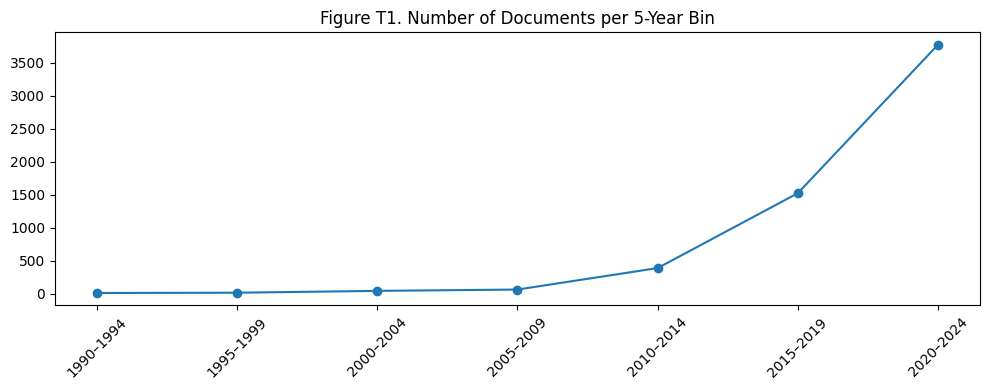

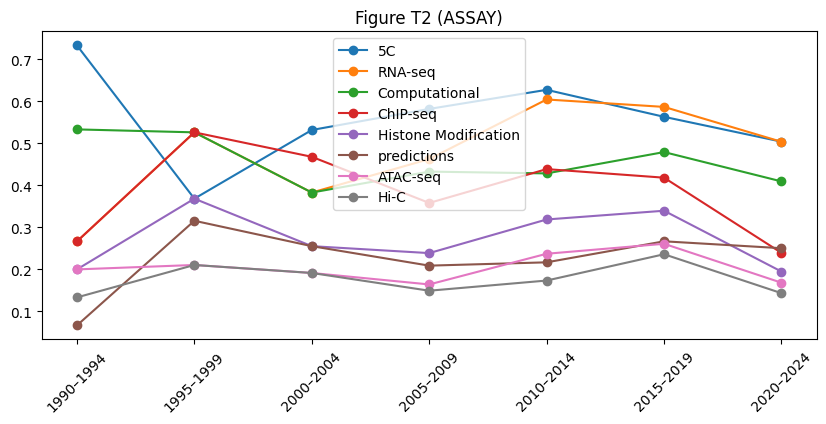

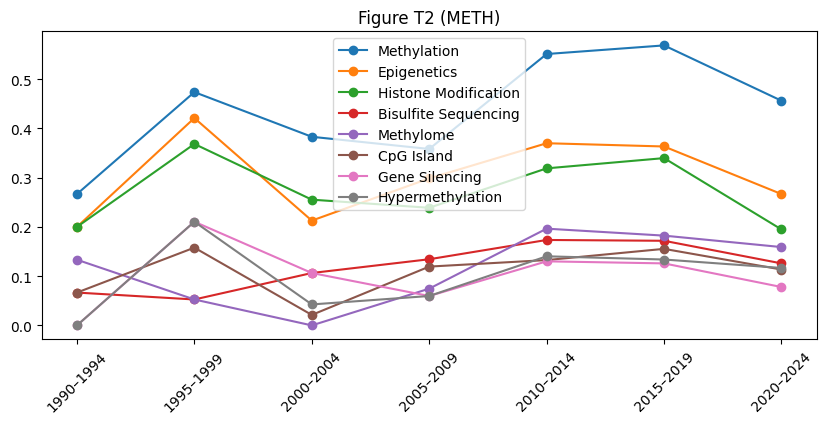

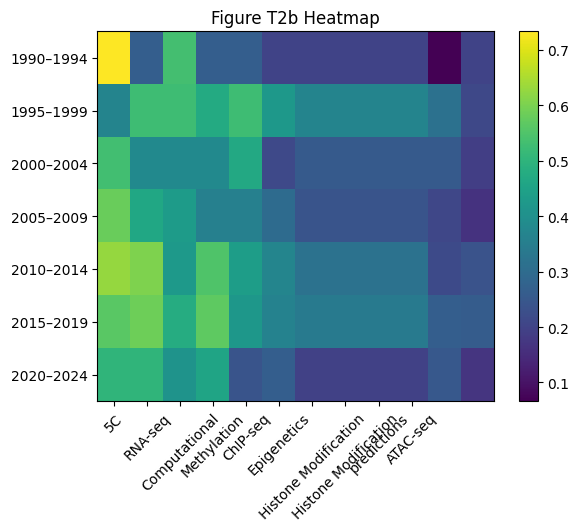

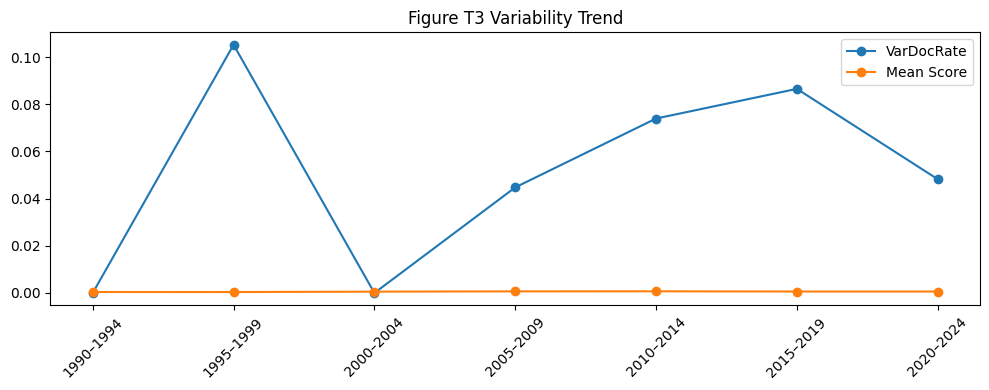

In [ ]:
# =========================================
# Colab: Temporal Trend Analysis (Paper-ready, fixed)
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) PATHS
# =========================
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR    = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) KEYWORDS
# =========================
assay_keywords = [
    "5C", "ChIA-PET", "Hi-C", "DNase-seq", "FAIRE-seq", "ATAC-seq", "ChIP-seq",
    "WGBS", "RRBS", "methylation array", "Computational", "predictions",
    "RNA-seq", "CLIP-seq", "RIP-seq", "Histone Modification"
]

methylation_keywords = [
    "Methylation", "CpG Island", "Hypermethylation", "Hypomethylation",
    "Epigenetics", "Histone Modification", "Gene Silencing", "DNMT",
    "Methylome", "Bisulfite Sequencing"
]

variability_patterns = [
    "chromatin variability", "chromatin heterogeneity", "dynamic chromatin",
    "chromatin plasticity", "chromatin state variation",
    "epigenetic variability", "epigenetic plasticity", "epigenetic heterogeneity"
]

variability_terms_for_score = ["variability", "heterogeneity", "dynamic", "plasticity"]

# =========================
# 3) PARAMETERS
# =========================
YEAR_MIN = 1990
YEAR_MAX = 2025
BIN_SIZE = 5
MIN_DOCS_PER_BIN = 10
TOP_K_ASSAY = 8
TOP_K_METH  = 8
TOP_K_HEATMAP = 10
PROGRESS_EVERY = 200

# =========================
# 4) HELPERS
# =========================
def normalize_text(t: str) -> str:
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

def load_txt_files_from_folder(folder_path: str):
    files = []
    for fn in sorted(os.listdir(folder_path)):
        if fn.lower().endswith(".txt"):
            fp = os.path.join(folder_path, fn)
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                files.append((fn, f.read()))
    return files

def extract_year_from_filename(fn: str):
    m = re.search(r"(19\d{2}|20\d{2})", fn)
    return int(m.group(1)) if m else None

def extract_year_from_text(text: str):
    years = re.findall(r"(19\d{2}|20\d{2})", text)
    if not years:
        return None
    years = [int(y) for y in years]
    return Counter(years).most_common(1)[0][0]

def pick_doc_year(filename: str, text: str):
    y = extract_year_from_filename(filename)
    return y if y else extract_year_from_text(text)

def clamp_year(y):
    return y if (y and YEAR_MIN <= y <= YEAR_MAX) else None

def year_to_bin(y: int):
    start = (y // BIN_SIZE) * BIN_SIZE
    while start + BIN_SIZE - 1 < YEAR_MIN:
        start += BIN_SIZE
    return start

def doc_contains_kw(text_lower: str, kw: str):
    return kw.lower() in text_lower

def variability_sentence_present(text_lower: str):
    return any(p in text_lower for p in variability_patterns)

def normalized_variability_score(text_lower: str):
    return sum(text_lower.count(t) for t in variability_terms_for_score) / max(1, len(text_lower.split()))

# =========================
# 5) LOAD CORPUS
# =========================
docs = load_txt_files_from_folder(CORPUS_DIR)

# =========================
# 6) BUILD TABLE
# =========================
rows = []

for i, (fn, text) in enumerate(docs, 1):
    text_norm = normalize_text(text)
    y = clamp_year(pick_doc_year(fn, text))
    if y is None:
        continue

    ybin = year_to_bin(y)

    row = {
        "file": fn,
        "year": y,
        "year_bin": ybin,
        "var_doc": int(variability_sentence_present(text_norm)),
        "var_score_norm": normalized_variability_score(text_norm)
    }

    for k in assay_keywords:
        row[f"ASSAY__{k}"] = int(doc_contains_kw(text_norm, k))
    for k in methylation_keywords:
        row[f"METH__{k}"] = int(doc_contains_kw(text_norm, k))

    rows.append(row)

df = pd.DataFrame(rows)

# =========================
# 7) AGGREGATE
# =========================
bin_counts = df.groupby("year_bin").size()
valid_bins = set(bin_counts[bin_counts >= MIN_DOCS_PER_BIN].index)
df2 = df[df["year_bin"].isin(valid_bins)]

t1 = df2.groupby("year_bin").size().reset_index(name="n_docs")

def compute_doc_rate(df_bin, prefix):
    cols = [c for c in df_bin.columns if c.startswith(prefix)]
    return pd.DataFrame({
        c.split("__")[1]: df_bin.groupby("year_bin")[c].mean()
        for c in cols
    })

assay_rate = compute_doc_rate(df2, "ASSAY__")
meth_rate  = compute_doc_rate(df2, "METH__")

t3 = df2.groupby("year_bin").agg(
    n_docs=("file", "count"),
    var_doc_rate=("var_doc", "mean"),
    var_score_norm_mean=("var_score_norm", "mean")
).reset_index()

# =========================
# 8) FIGURE T1
# =========================
plt.figure(figsize=(10,4))
x = t1["year_bin"]
y = t1["n_docs"]

plt.plot(x, y, marker="o")
plt.xticks(x, [f"{a}–{a+BIN_SIZE-1}" for a in x], rotation=45)
plt.title("Figure T1. Number of Documents per 5-Year Bin")

plt.tight_layout()
plt.show()

# =========================
# 9) FIGURE T2
# =========================
def plot_topk(rate_df, title):
    top_terms = rate_df.mean().sort_values(ascending=False).head(8).index
    sub = rate_df[top_terms]

    plt.figure(figsize=(10,4))
    for term in top_terms:
        plt.plot(sub.index, sub[term], marker="o", label=term)

    plt.xticks(sub.index, [f"{a}–{a+BIN_SIZE-1}" for a in sub.index], rotation=45)
    plt.legend()
    plt.title(title)
    plt.show()

plot_topk(assay_rate, "Figure T2 (ASSAY)")
plot_topk(meth_rate, "Figure T2 (METH)")

# =========================
# 10) FIGURE T2b
# =========================
combined = pd.concat([assay_rate, meth_rate], axis=1)
top_terms = combined.mean().sort_values(ascending=False).head(10).index
heat = combined[top_terms]

plt.imshow(heat.values, aspect="auto")
plt.xticks(range(len(top_terms)), top_terms, rotation=45)
plt.yticks(range(len(heat.index)), [f"{a}–{a+BIN_SIZE-1}" for a in heat.index])
plt.title("Figure T2b Heatmap")
plt.colorbar()
plt.show()

# =========================
# 11) FIGURE T3
# =========================
plt.figure(figsize=(10,4))
x = t3["year_bin"]

plt.plot(x, t3["var_doc_rate"], marker="o", label="VarDocRate")
plt.plot(x, t3["var_score_norm_mean"], marker="o", label="Mean Score")

plt.xticks(x, [f"{a}–{a+BIN_SIZE-1}" for a in x], rotation=45)
plt.legend()
plt.title("Figure T3 Variability Trend")

plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found .txt files: 6152
Processed 1/6152 docs... kept=1
Processed 200/6152 docs... kept=193
Processed 400/6152 docs... kept=364
Processed 600/6152 docs... kept=536
Processed 800/6152 docs... kept=727
Processed 1000/6152 docs... kept=915
Processed 1200/6152 docs... kept=1106
Processed 1400/6152 docs... kept=1294
Processed 1600/6152 docs... kept=1486
Processed 1800/6152 docs... kept=1677
Processed 2000/6152 docs... kept=1872
Processed 2200/6152 docs... kept=2064
Processed 2600/6152 docs... kept=2421
Processed 2800/6152 docs... kept=2614
Processed 3000/6152 docs... kept=2808
Processed 3200/6152 docs... kept=3004
Processed 3400/6152 docs... kept=3197
Processed 3600/6152 docs... kept=3393
Processed 3800/6152 docs... kept=3576
Processed 4000/6152 docs... kept=3775
Processed 4200/6152 docs... kept=3973
Processed 4400/6152 docs... kept=4151
Processed 4600/6152 docs...

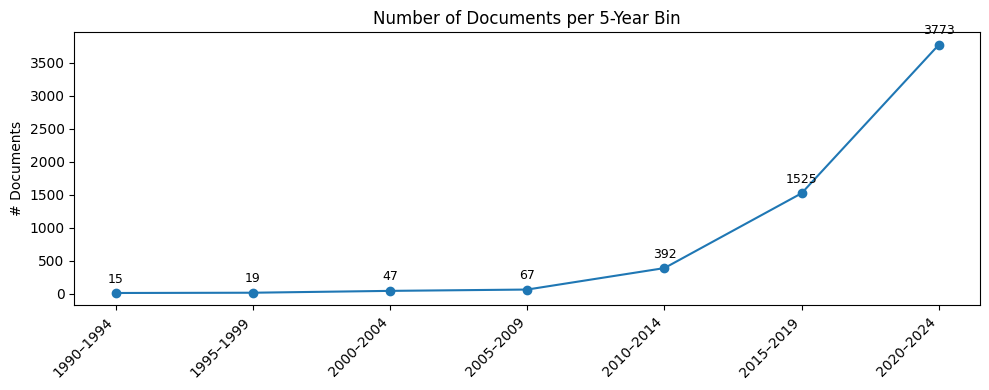

Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/docs_per_5yearbin.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/docs_per_5yearbin.pdf


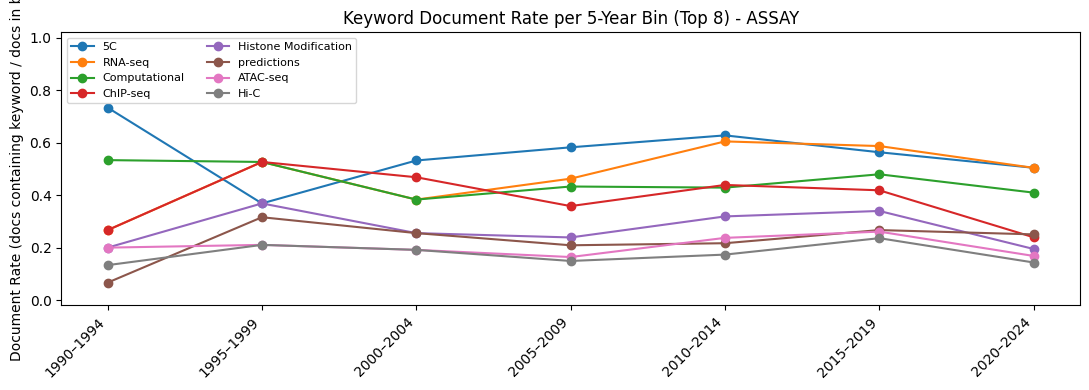

Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/assay_doc_rate_5yearbin_top8.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/assay_doc_rate_5yearbin_top8.pdf


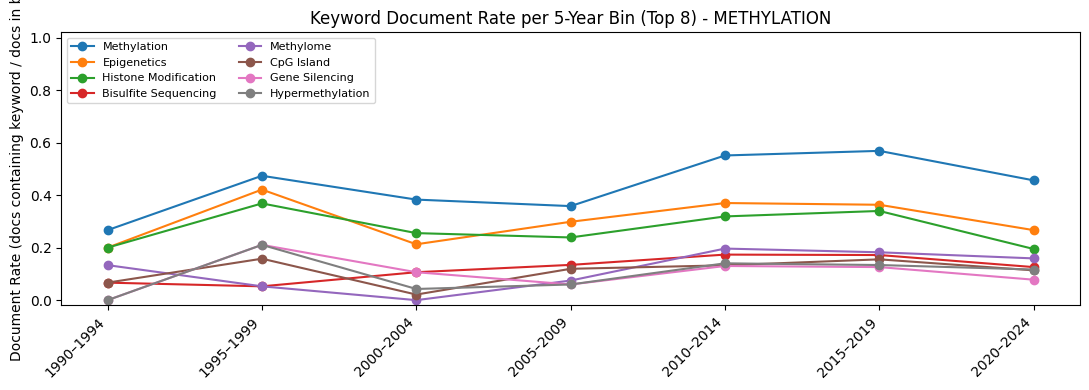

Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/methylation_doc_rate_5yearbin_top8.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/methylation_doc_rate_5yearbin_top8.pdf


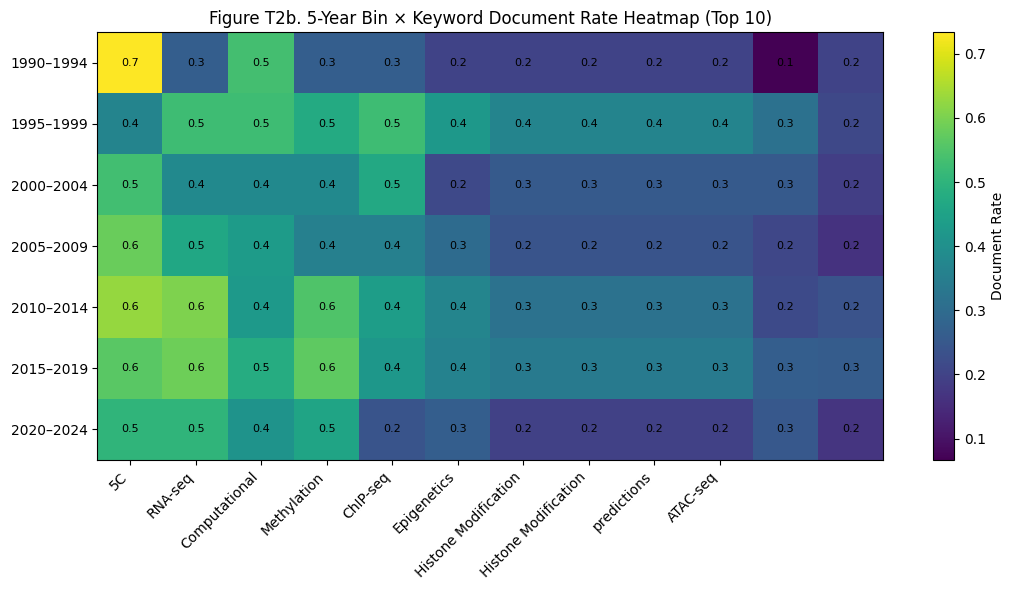

Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/FigureT2b_heatmap_keyword_rate_5yearbin_top10.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/FigureT2b_heatmap_keyword_rate_5yearbin_top10.pdf


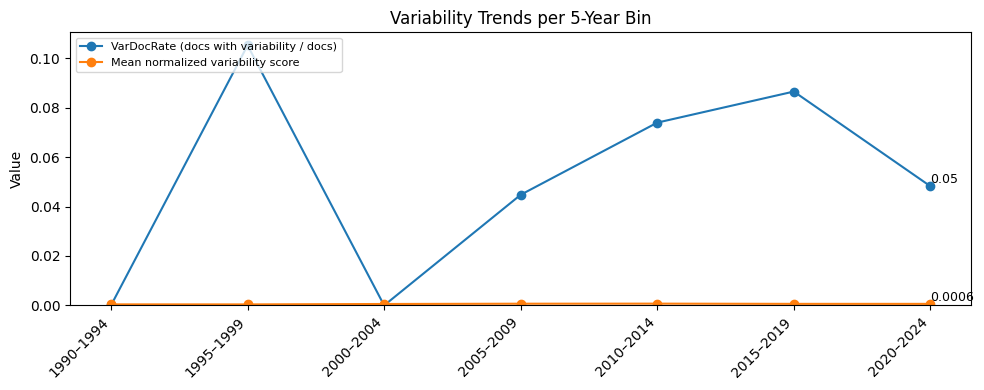

Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/variability_trend_5yearbin.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/variability_trend_5yearbin.pdf

DONE. Output folder:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add


In [ ]:
# =========================================
# Colab: Temporal Trend Analysis (Paper-ready, fixed)
# - En dash applied to numeric ranges
# - Figure titles preserved as shown
# - Legend adjusted to avoid excessive overlap
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) PATHS
# =========================
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR    = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) KEYWORDS
# =========================
assay_keywords = [
    "5C", "ChIA-PET", "Hi-C", "DNase-seq", "FAIRE-seq", "ATAC-seq", "ChIP-seq",
    "WGBS", "RRBS", "methylation array", "Computational", "predictions",
    "RNA-seq", "CLIP-seq", "RIP-seq", "Histone Modification"
]

methylation_keywords = [
    "Methylation", "CpG Island", "Hypermethylation", "Hypomethylation",
    "Epigenetics", "Histone Modification", "Gene Silencing", "DNMT",
    "Methylome", "Bisulfite Sequencing"
]

variability_patterns = [
    "chromatin variability",
    "chromatin heterogeneity",
    "dynamic chromatin",
    "chromatin plasticity",
    "chromatin state variation",
    "epigenetic variability",
    "epigenetic plasticity",
    "epigenetic heterogeneity"
]

variability_terms_for_score = ["variability", "heterogeneity", "dynamic", "plasticity"]

# =========================
# 3) PARAMETERS
# =========================
YEAR_MIN = 1990
YEAR_MAX = 2025

BIN_SIZE = 5
MIN_DOCS_PER_BIN = 10

TOP_K_ASSAY = 8
TOP_K_METH  = 8
TOP_K_HEATMAP = 10

PROGRESS_EVERY = 200

# =========================
# 4) HELPERS
# =========================
def normalize_text(t: str) -> str:
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

def load_txt_files_from_folder(folder_path: str):
    files = []
    for fn in sorted(os.listdir(folder_path)):
        if fn.lower().endswith(".txt"):
            fp = os.path.join(folder_path, fn)
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                files.append((fn, f.read()))
    return files

def extract_year_from_filename(fn: str):
    m = re.search(r"(19\d{2}|20\d{2})", fn)
    if m:
        return int(m.group(1))
    return None

def extract_year_from_text(text: str):
    years = re.findall(r"(19\d{2}|20\d{2})", text)
    if not years:
        return None
    years = [int(y) for y in years]
    c = Counter(years)
    return c.most_common(1)[0][0]

def pick_doc_year(filename: str, text: str):
    y = extract_year_from_filename(filename)
    if y is None:
        y = extract_year_from_text(text)
    return y

def clamp_year(y):
    if y is None:
        return None
    if YEAR_MIN <= y <= YEAR_MAX:
        return y
    return None

def year_to_bin(y: int):
    start = (y // BIN_SIZE) * BIN_SIZE
    while start + BIN_SIZE - 1 < YEAR_MIN:
        start += BIN_SIZE
    return start

def doc_contains_kw(text_lower: str, kw: str):
    return kw.lower() in text_lower

def variability_sentence_present(text_lower: str):
    return any(p.lower() in text_lower for p in variability_patterns)

def variability_score(text_lower: str):
    return sum(text_lower.count(t) for t in variability_terms_for_score)

def normalized_variability_score(text_lower: str):
    n_words = max(1, len(text_lower.split()))
    return variability_score(text_lower) / n_words

def year_range_label(a):
    return f"{a}–{a+BIN_SIZE-1}"

# =========================
# 5) LOAD CORPUS
# =========================
docs = load_txt_files_from_folder(CORPUS_DIR)
print("Found .txt files:", len(docs))

# =========================
# 6) BUILD DOC TABLE
# =========================
rows = []
skipped_no_year = 0
skipped_out_of_range = 0

for i, (fn, text) in enumerate(docs, 1):
    text_norm = normalize_text(text)
    y_raw = pick_doc_year(fn, text)
    y = clamp_year(y_raw)

    if y is None:
        if y_raw is None:
            skipped_no_year += 1
        else:
            skipped_out_of_range += 1
        continue

    ybin = year_to_bin(y)

    assay_present = {k: int(doc_contains_kw(text_norm, k)) for k in assay_keywords}
    meth_present  = {k: int(doc_contains_kw(text_norm, k)) for k in methylation_keywords}

    var_doc = int(variability_sentence_present(text_norm))
    var_score_norm = normalized_variability_score(text_norm)

    row = {
        "file": fn,
        "year": y,
        "year_bin": ybin,
        "var_doc": var_doc,
        "var_score_norm": var_score_norm
    }

    for k, v in assay_present.items():
        row[f"ASSAY__{k}"] = v

    for k, v in meth_present.items():
        row[f"METH__{k}"] = v

    rows.append(row)

    if i % PROGRESS_EVERY == 0 or i == 1 or i == len(docs):
        print(f"Processed {i}/{len(docs)} docs... kept={len(rows)}")

df = pd.DataFrame(rows)

print("\nKept docs with valid years:", len(df))
print("Skipped no year:", skipped_no_year)
print("Skipped out of range:", skipped_out_of_range)

doc_table_path = os.path.join(OUT_DIR, "doc_table_year_keywords_variability.csv")
df.to_csv(doc_table_path, index=False, encoding="utf-8-sig")
print("Saved doc table:", doc_table_path)

# =========================
# 7) AGGREGATE BY YEAR_BIN
# =========================
bin_counts = df.groupby("year_bin").size().rename("n_docs").to_frame()
bin_counts = bin_counts[bin_counts["n_docs"] >= MIN_DOCS_PER_BIN]

valid_bins = set(bin_counts.index.tolist())
df2 = df[df["year_bin"].isin(valid_bins)].copy()

t1 = df2.groupby("year_bin").size().rename("n_docs").reset_index()

def compute_doc_rate(df_bin, prefix):
    cols = [c for c in df_bin.columns if c.startswith(prefix)]
    rates = {}
    for c in cols:
        kw = c.split("__", 1)[1]
        rates[kw] = df_bin.groupby("year_bin")[c].mean()
    return pd.DataFrame(rates)

assay_rate = compute_doc_rate(df2, "ASSAY__")
meth_rate  = compute_doc_rate(df2, "METH__")

t3 = df2.groupby("year_bin").agg(
    n_docs=("file", "count"),
    var_doc_rate=("var_doc", "mean"),
    var_score_norm_mean=("var_score_norm", "mean")
).reset_index()

# =========================
# 8) SAVE TABLES
# =========================
t1_path = os.path.join(OUT_DIR, "T1_docs_per_yearbin.csv")
assay_rate_path = os.path.join(OUT_DIR, "T2_assay_doc_rate_per_yearbin.csv")
meth_rate_path  = os.path.join(OUT_DIR, "T2_methylation_doc_rate_per_yearbin.csv")
t3_path = os.path.join(OUT_DIR, "T3_variability_trend_per_yearbin.csv")

t1.to_csv(t1_path, index=False, encoding="utf-8-sig")
assay_rate.to_csv(assay_rate_path, encoding="utf-8-sig")
meth_rate.to_csv(meth_rate_path, encoding="utf-8-sig")
t3.to_csv(t3_path, index=False, encoding="utf-8-sig")

print("\nSaved aggregated tables:")
print(" -", t1_path)
print(" -", assay_rate_path)
print(" -", meth_rate_path)
print(" -", t3_path)

# =========================
# 9) FIGURE T1
# =========================
plt.figure(figsize=(10,4))

x = t1["year_bin"].tolist()
y = t1["n_docs"].tolist()

plt.plot(x, y, marker="o")
plt.xticks(x, [year_range_label(a) for a in x], rotation=45, ha="right")
plt.ylabel("# Documents")
plt.title(f"Number of Documents per {BIN_SIZE}-Year Bin")

ymax = max(y) if y else 1
offset = max(1, int(ymax * 0.03))

for xi, yi in zip(x, y):
    plt.text(xi, yi + offset, str(int(yi)), ha="center", va="bottom", fontsize=9)

plt.tight_layout()

fig_t1_png = os.path.join(OUT_DIR, f"docs_per_{BIN_SIZE}yearbin.png")
fig_t1_pdf = os.path.join(OUT_DIR, f"docs_per_{BIN_SIZE}yearbin.pdf")

plt.savefig(fig_t1_png, dpi=600)
plt.savefig(fig_t1_pdf)
plt.show()

print("Saved:", fig_t1_png)
print("Saved:", fig_t1_pdf)

# =========================
# 10) FIGURE T2
# =========================
def plot_topk_rates(rate_df, title, out_prefix, top_k=8):
    top_terms = rate_df.mean(axis=0).sort_values(ascending=False).head(top_k).index.tolist()
    sub = rate_df[top_terms].copy()
    sub = sub.sort_index()

    plt.figure(figsize=(11,4))

    xbins = sub.index.tolist()

    for term in top_terms:
        plt.plot(xbins, sub[term].values, marker="o", label=term)

    plt.xticks(xbins, [year_range_label(a) for a in xbins], rotation=45, ha="right")
    plt.ylabel("Document Rate (docs containing keyword / docs in bin)")
    plt.title(title)
    plt.ylim(-0.02, 1.02)

    # 범례를 그림처럼 왼쪽 위에 두되, 너무 크게 가리지 않도록 조정
    plt.legend(
        loc="upper left",
        ncol=2,
        fontsize=8,
        frameon=True
    )

    plt.tight_layout()

    png = os.path.join(OUT_DIR, f"{out_prefix}_top{top_k}.png")
    pdf = os.path.join(OUT_DIR, f"{out_prefix}_top{top_k}.pdf")

    plt.savefig(png, dpi=600)
    plt.savefig(pdf)
    plt.show()

    print("Saved:", png)
    print("Saved:", pdf)

plot_topk_rates(
    assay_rate,
    title=f"Keyword Document Rate per {BIN_SIZE}-Year Bin (Top {TOP_K_ASSAY}) - ASSAY",
    out_prefix=f"assay_doc_rate_{BIN_SIZE}yearbin",
    top_k=TOP_K_ASSAY
)

plot_topk_rates(
    meth_rate,
    title=f"Keyword Document Rate per {BIN_SIZE}-Year Bin (Top {TOP_K_METH}) - METHYLATION",
    out_prefix=f"methylation_doc_rate_{BIN_SIZE}yearbin",
    top_k=TOP_K_METH
)

# =========================
# 11) FIGURE T2b HEATMAP
# =========================
combined_rate = pd.concat([assay_rate, meth_rate], axis=1)

top_terms = combined_rate.mean(axis=0).sort_values(ascending=False).head(TOP_K_HEATMAP).index.tolist()
heat = combined_rate[top_terms].copy()
heat = heat.sort_index()

plt.figure(figsize=(11,6))

im = plt.imshow(heat.values, aspect="auto")

plt.xticks(range(len(top_terms)), top_terms, rotation=45, ha="right")
plt.yticks(range(len(heat.index)), [year_range_label(a) for a in heat.index.tolist()])
plt.colorbar(im, label="Document Rate")

plt.title(f"Figure T2b. {BIN_SIZE}-Year Bin × Keyword Document Rate Heatmap (Top {TOP_K_HEATMAP})")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = float(heat.iat[i, j])
        if val >= 0.05:
            plt.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8)

plt.tight_layout()

fig_t2b_png = os.path.join(OUT_DIR, f"FigureT2b_heatmap_keyword_rate_{BIN_SIZE}yearbin_top{TOP_K_HEATMAP}.png")
fig_t2b_pdf = os.path.join(OUT_DIR, f"FigureT2b_heatmap_keyword_rate_{BIN_SIZE}yearbin_top{TOP_K_HEATMAP}.pdf")

plt.savefig(fig_t2b_png, dpi=600)
plt.savefig(fig_t2b_pdf)
plt.show()

print("Saved:", fig_t2b_png)
print("Saved:", fig_t2b_pdf)

# =========================
# 12) FIGURE T3
# =========================
t3 = t3.sort_values("year_bin")

plt.figure(figsize=(10,4))

x = t3["year_bin"].tolist()
y1 = t3["var_doc_rate"].tolist()
y2 = t3["var_score_norm_mean"].tolist()

plt.plot(x, y1, marker="o", label="VarDocRate (docs with variability / docs)")
plt.plot(x, y2, marker="o", label="Mean normalized variability score")

plt.xticks(x, [year_range_label(a) for a in x], rotation=45, ha="right")
plt.ylabel("Value")
plt.title(f"Variability Trends per {BIN_SIZE}-Year Bin")
plt.ylim(bottom=0)

if len(x) > 0:
    plt.text(x[-1], y1[-1], f"{y1[-1]:.2f}", ha="left", va="bottom", fontsize=9)
    plt.text(x[-1], y2[-1], f"{y2[-1]:.4f}", ha="left", va="bottom", fontsize=9)

plt.legend(
    loc="upper left",
    fontsize=8,
    frameon=True
)

plt.tight_layout()

fig_t3_png = os.path.join(OUT_DIR, f"variability_trend_{BIN_SIZE}yearbin.png")
fig_t3_pdf = os.path.join(OUT_DIR, f"variability_trend_{BIN_SIZE}yearbin.pdf")

plt.savefig(fig_t3_png, dpi=600)
plt.savefig(fig_t3_pdf)
plt.show()

print("Saved:", fig_t3_png)
print("Saved:", fig_t3_pdf)

print("\nDONE. Output folder:")
print(" -", OUT_DIR)

(b), (c)부분 글씨 안보임 해결

Mounted at /content/drive
Found .txt files: 6152
Processed 1/6152 docs... kept=1
Processed 200/6152 docs... kept=193
Processed 400/6152 docs... kept=364
Processed 600/6152 docs... kept=536
Processed 800/6152 docs... kept=727
Processed 1000/6152 docs... kept=915
Processed 1200/6152 docs... kept=1106
Processed 1400/6152 docs... kept=1294
Processed 1600/6152 docs... kept=1486
Processed 1800/6152 docs... kept=1677
Processed 2000/6152 docs... kept=1872
Processed 2200/6152 docs... kept=2064
Processed 2600/6152 docs... kept=2421
Processed 2800/6152 docs... kept=2614
Processed 3000/6152 docs... kept=2808
Processed 3200/6152 docs... kept=3004
Processed 3400/6152 docs... kept=3197
Processed 3600/6152 docs... kept=3393
Processed 3800/6152 docs... kept=3576
Processed 4000/6152 docs... kept=3775
Processed 4200/6152 docs... kept=3973
Processed 4400/6152 docs... kept=4151
Processed 4600/6152 docs... kept=4348
Processed 4800/6152 docs... kept=4543
Processed 5000/6152 docs... kept=4738
Processed 5200/6

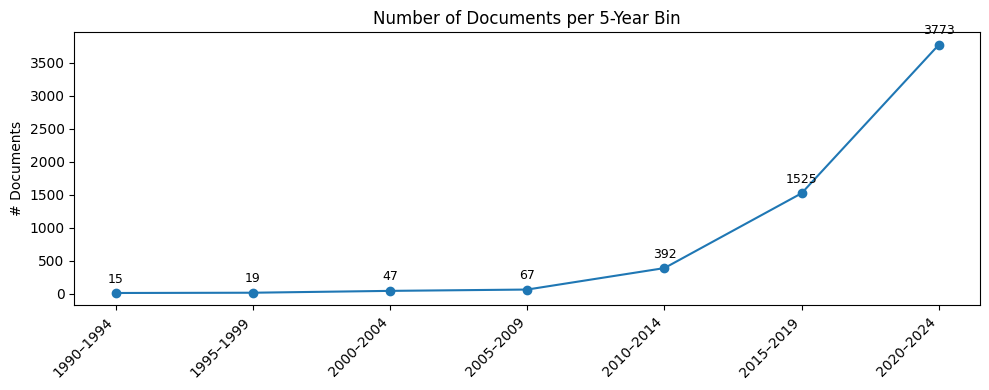

Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/docs_per_5yearbin.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/docs_per_5yearbin.pdf


/tmp/ipykernel_7071/2616409372.py:508: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0.14)


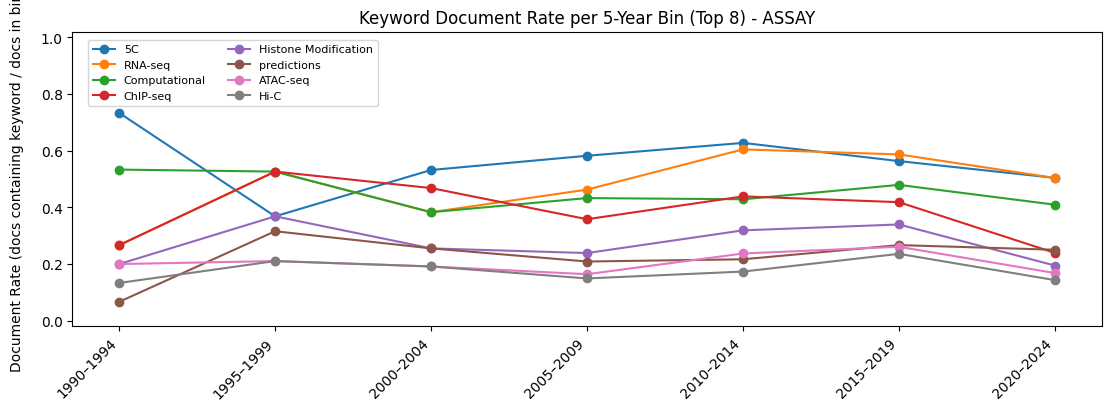

Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/assay_doc_rate_5yearbin_top8.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/assay_doc_rate_5yearbin_top8.pdf


/tmp/ipykernel_7071/2616409372.py:508: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0.14)


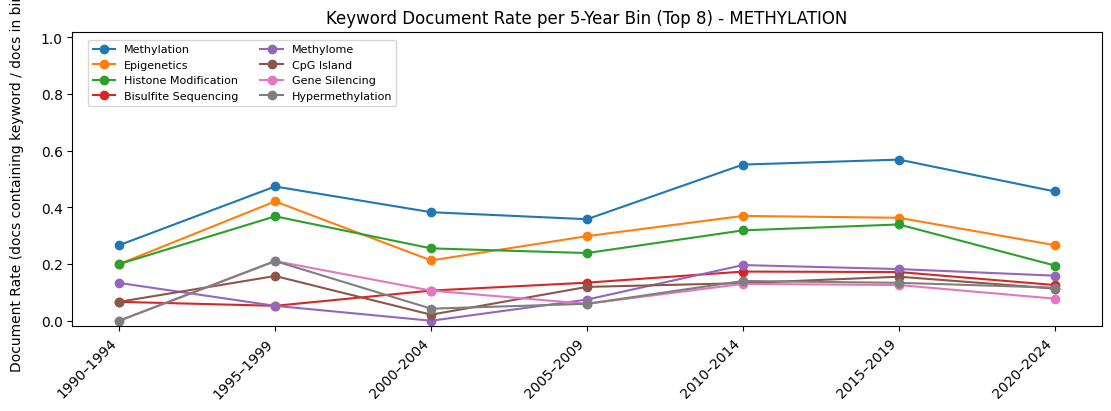

Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/methylation_doc_rate_5yearbin_top8.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/methylation_doc_rate_5yearbin_top8.pdf


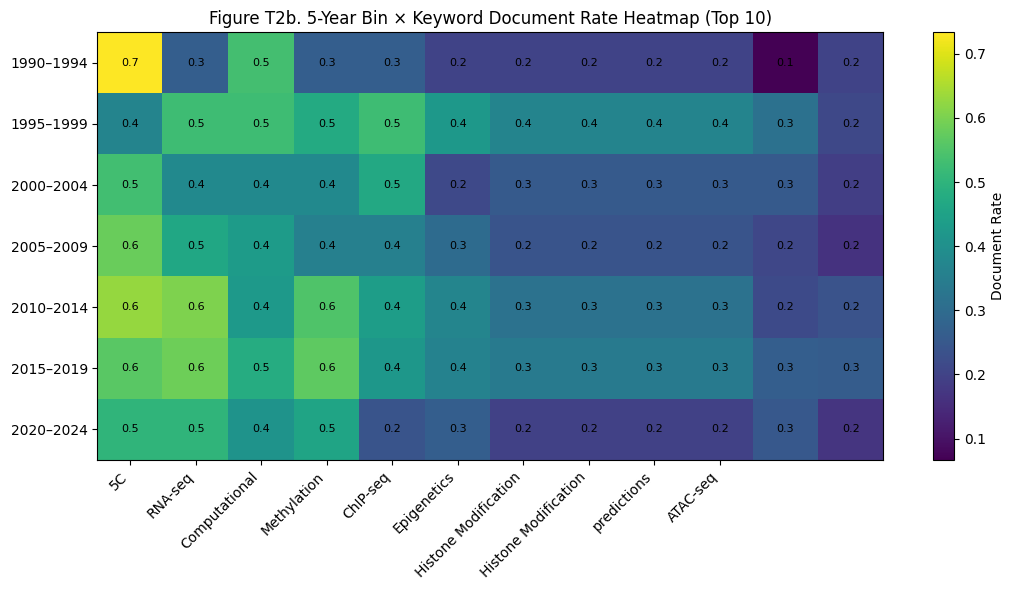

Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/FigureT2b_heatmap_keyword_rate_5yearbin_top10.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/FigureT2b_heatmap_keyword_rate_5yearbin_top10.pdf


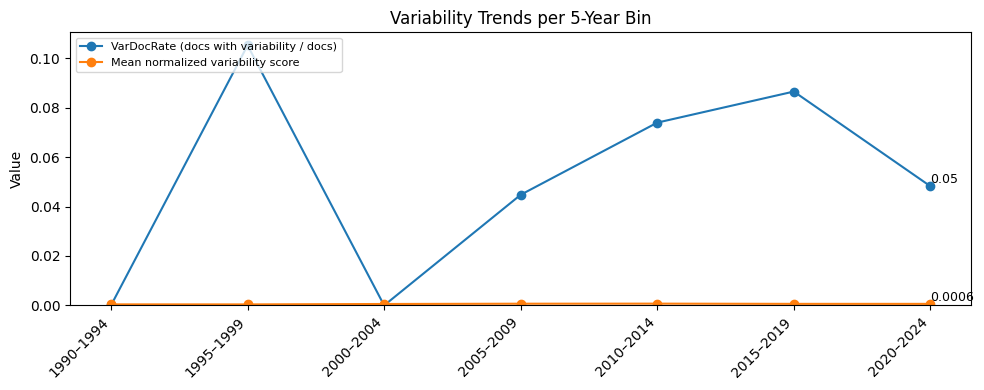

Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/variability_trend_5yearbin.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/variability_trend_5yearbin.pdf

DONE. Output folder:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add


In [ ]:
# =========================================
# Colab: Temporal Trend Analysis (Paper-ready, fixed)
# - En dash applied to numeric ranges
# - Figure titles preserved as shown
# - Legend adjusted to avoid excessive overlap
# - FIXED: y-axis label clipping in Figure (b), (c)
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) PATHS
# =========================
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"

OUT_DIR = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add"

os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) KEYWORDS
# =========================
assay_keywords = [
    "5C",
    "ChIA-PET",
    "Hi-C",
    "DNase-seq",
    "FAIRE-seq",
    "ATAC-seq",
    "ChIP-seq",
    "WGBS",
    "RRBS",
    "methylation array",
    "Computational",
    "predictions",
    "RNA-seq",
    "CLIP-seq",
    "RIP-seq",
    "Histone Modification"
]

methylation_keywords = [
    "Methylation",
    "CpG Island",
    "Hypermethylation",
    "Hypomethylation",
    "Epigenetics",
    "Histone Modification",
    "Gene Silencing",
    "DNMT",
    "Methylome",
    "Bisulfite Sequencing"
]

variability_patterns = [
    "chromatin variability",
    "chromatin heterogeneity",
    "dynamic chromatin",
    "chromatin plasticity",
    "chromatin state variation",
    "epigenetic variability",
    "epigenetic plasticity",
    "epigenetic heterogeneity"
]

variability_terms_for_score = [
    "variability",
    "heterogeneity",
    "dynamic",
    "plasticity"
]

# =========================
# 3) PARAMETERS
# =========================
YEAR_MIN = 1990
YEAR_MAX = 2025

BIN_SIZE = 5
MIN_DOCS_PER_BIN = 10

TOP_K_ASSAY = 8
TOP_K_METH = 8
TOP_K_HEATMAP = 10

PROGRESS_EVERY = 200

# =========================
# 4) HELPERS
# =========================
def normalize_text(t: str):
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

def load_txt_files_from_folder(folder_path: str):
    files = []

    for fn in sorted(os.listdir(folder_path)):

        if fn.lower().endswith(".txt"):

            fp = os.path.join(folder_path, fn)

            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                files.append((fn, f.read()))

    return files

def extract_year_from_filename(fn: str):

    m = re.search(r"(19\d{2}|20\d{2})", fn)

    if m:
        return int(m.group(1))

    return None

def extract_year_from_text(text: str):

    years = re.findall(r"(19\d{2}|20\d{2})", text)

    if not years:
        return None

    years = [int(y) for y in years]

    c = Counter(years)

    return c.most_common(1)[0][0]

def pick_doc_year(filename: str, text: str):

    y = extract_year_from_filename(filename)

    if y is None:
        y = extract_year_from_text(text)

    return y

def clamp_year(y):

    if y is None:
        return None

    if YEAR_MIN <= y <= YEAR_MAX:
        return y

    return None

def year_to_bin(y: int):

    start = (y // BIN_SIZE) * BIN_SIZE

    while start + BIN_SIZE - 1 < YEAR_MIN:
        start += BIN_SIZE

    return start

def doc_contains_kw(text_lower: str, kw: str):
    return kw.lower() in text_lower

def variability_sentence_present(text_lower: str):

    return any(
        p.lower() in text_lower
        for p in variability_patterns
    )

def variability_score(text_lower: str):

    return sum(
        text_lower.count(t)
        for t in variability_terms_for_score
    )

def normalized_variability_score(text_lower: str):

    n_words = max(1, len(text_lower.split()))

    return variability_score(text_lower) / n_words

def year_range_label(a):

    return f"{a}–{a+BIN_SIZE-1}"

# =========================
# 5) LOAD CORPUS
# =========================
docs = load_txt_files_from_folder(CORPUS_DIR)

print("Found .txt files:", len(docs))

# =========================
# 6) BUILD DOC TABLE
# =========================
rows = []

skipped_no_year = 0
skipped_out_of_range = 0

for i, (fn, text) in enumerate(docs, 1):

    text_norm = normalize_text(text)

    y_raw = pick_doc_year(fn, text)

    y = clamp_year(y_raw)

    if y is None:

        if y_raw is None:
            skipped_no_year += 1

        else:
            skipped_out_of_range += 1

        continue

    ybin = year_to_bin(y)

    assay_present = {
        k: int(doc_contains_kw(text_norm, k))
        for k in assay_keywords
    }

    meth_present = {
        k: int(doc_contains_kw(text_norm, k))
        for k in methylation_keywords
    }

    var_doc = int(
        variability_sentence_present(text_norm)
    )

    var_score_norm = normalized_variability_score(text_norm)

    row = {
        "file": fn,
        "year": y,
        "year_bin": ybin,
        "var_doc": var_doc,
        "var_score_norm": var_score_norm
    }

    for k, v in assay_present.items():
        row[f"ASSAY__{k}"] = v

    for k, v in meth_present.items():
        row[f"METH__{k}"] = v

    rows.append(row)

    if i % PROGRESS_EVERY == 0 or i == 1 or i == len(docs):

        print(
            f"Processed {i}/{len(docs)} docs... kept={len(rows)}"
        )

df = pd.DataFrame(rows)

print("\nKept docs with valid years:", len(df))
print("Skipped no year:", skipped_no_year)
print("Skipped out of range:", skipped_out_of_range)

doc_table_path = os.path.join(
    OUT_DIR,
    "doc_table_year_keywords_variability.csv"
)

df.to_csv(
    doc_table_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved doc table:", doc_table_path)

# =========================
# 7) AGGREGATE BY YEAR_BIN
# =========================
bin_counts = (
    df.groupby("year_bin")
    .size()
    .rename("n_docs")
    .to_frame()
)

bin_counts = bin_counts[
    bin_counts["n_docs"] >= MIN_DOCS_PER_BIN
]

valid_bins = set(bin_counts.index.tolist())

df2 = df[
    df["year_bin"].isin(valid_bins)
].copy()

t1 = (
    df2.groupby("year_bin")
    .size()
    .rename("n_docs")
    .reset_index()
)

def compute_doc_rate(df_bin, prefix):

    cols = [
        c for c in df_bin.columns
        if c.startswith(prefix)
    ]

    rates = {}

    for c in cols:

        kw = c.split("__", 1)[1]

        rates[kw] = (
            df_bin.groupby("year_bin")[c]
            .mean()
        )

    return pd.DataFrame(rates)

assay_rate = compute_doc_rate(df2, "ASSAY__")
meth_rate  = compute_doc_rate(df2, "METH__")

t3 = (
    df2.groupby("year_bin")
    .agg(
        n_docs=("file", "count"),
        var_doc_rate=("var_doc", "mean"),
        var_score_norm_mean=("var_score_norm", "mean")
    )
    .reset_index()
)

# =========================
# 8) SAVE TABLES
# =========================
t1_path = os.path.join(
    OUT_DIR,
    "T1_docs_per_yearbin.csv"
)

assay_rate_path = os.path.join(
    OUT_DIR,
    "T2_assay_doc_rate_per_yearbin.csv"
)

meth_rate_path = os.path.join(
    OUT_DIR,
    "T2_methylation_doc_rate_per_yearbin.csv"
)

t3_path = os.path.join(
    OUT_DIR,
    "T3_variability_trend_per_yearbin.csv"
)

t1.to_csv(t1_path, index=False, encoding="utf-8-sig")
assay_rate.to_csv(assay_rate_path, encoding="utf-8-sig")
meth_rate.to_csv(meth_rate_path, encoding="utf-8-sig")
t3.to_csv(t3_path, index=False, encoding="utf-8-sig")

print("\nSaved aggregated tables:")
print(" -", t1_path)
print(" -", assay_rate_path)
print(" -", meth_rate_path)
print(" -", t3_path)

# =========================
# 9) FIGURE T1
# =========================
plt.figure(figsize=(10,4))

x = t1["year_bin"].tolist()
y = t1["n_docs"].tolist()

plt.plot(x, y, marker="o")

plt.xticks(
    x,
    [year_range_label(a) for a in x],
    rotation=45,
    ha="right"
)

plt.ylabel("# Documents")

plt.title(
    f"Number of Documents per {BIN_SIZE}-Year Bin"
)

ymax = max(y) if y else 1

offset = max(1, int(ymax * 0.03))

for xi, yi in zip(x, y):

    plt.text(
        xi,
        yi + offset,
        str(int(yi)),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

fig_t1_png = os.path.join(
    OUT_DIR,
    f"docs_per_{BIN_SIZE}yearbin.png"
)

fig_t1_pdf = os.path.join(
    OUT_DIR,
    f"docs_per_{BIN_SIZE}yearbin.pdf"
)

plt.savefig(fig_t1_png, dpi=600)
plt.savefig(fig_t1_pdf)

plt.show()

print("Saved:", fig_t1_png)
print("Saved:", fig_t1_pdf)

# =========================
# 10) FIGURE T2
# FIXED VERSION
# =========================
def plot_topk_rates(rate_df, title, out_prefix, top_k=8):

    top_terms = (
        rate_df.mean(axis=0)
        .sort_values(ascending=False)
        .head(top_k)
        .index.tolist()
    )

    sub = rate_df[top_terms].copy()

    sub = sub.sort_index()

    # =========================
    # FIX:
    # constrained_layout + left margin
    # =========================
    fig, ax = plt.subplots(
        figsize=(11,4),
        constrained_layout=True
    )

    xbins = sub.index.tolist()

    for term in top_terms:

        ax.plot(
            xbins,
            sub[term].values,
            marker="o",
            label=term
        )

    ax.set_xticks(xbins)

    ax.set_xticklabels(
        [year_range_label(a) for a in xbins],
        rotation=45,
        ha="right"
    )

    # =========================
    # FIX:
    # y-label clipping
    # =========================
    ax.set_ylabel(
        "Document Rate (docs containing keyword / docs in bin)",
        labelpad=12
    )

    ax.set_title(title)

    ax.set_ylim(-0.02, 1.02)

    ax.legend(
        loc="upper left",
        ncol=2,
        fontsize=8,
        frameon=True,
        bbox_to_anchor=(0.01, 0.99)
    )

    # =========================
    # FIX:
    # left margin
    # =========================
    plt.subplots_adjust(left=0.14)

    png = os.path.join(
        OUT_DIR,
        f"{out_prefix}_top{top_k}.png"
    )

    pdf = os.path.join(
        OUT_DIR,
        f"{out_prefix}_top{top_k}.pdf"
    )

    plt.savefig(
        png,
        dpi=600,
        bbox_inches="tight"
    )

    plt.savefig(
        pdf,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", png)
    print("Saved:", pdf)

# =========================
# (b) ASSAY
# =========================
plot_topk_rates(
    assay_rate,
    title=f"Keyword Document Rate per {BIN_SIZE}-Year Bin (Top {TOP_K_ASSAY}) - ASSAY",
    out_prefix=f"assay_doc_rate_{BIN_SIZE}yearbin",
    top_k=TOP_K_ASSAY
)

# =========================
# (c) METHYLATION
# =========================
plot_topk_rates(
    meth_rate,
    title=f"Keyword Document Rate per {BIN_SIZE}-Year Bin (Top {TOP_K_METH}) - METHYLATION",
    out_prefix=f"methylation_doc_rate_{BIN_SIZE}yearbin",
    top_k=TOP_K_METH
)

# =========================
# 11) FIGURE T2b HEATMAP
# =========================
combined_rate = pd.concat(
    [assay_rate, meth_rate],
    axis=1
)

top_terms = (
    combined_rate.mean(axis=0)
    .sort_values(ascending=False)
    .head(TOP_K_HEATMAP)
    .index.tolist()
)

heat = combined_rate[top_terms].copy()

heat = heat.sort_index()

plt.figure(figsize=(11,6))

im = plt.imshow(
    heat.values,
    aspect="auto"
)

plt.xticks(
    range(len(top_terms)),
    top_terms,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(heat.index)),
    [year_range_label(a) for a in heat.index.tolist()]
)

plt.colorbar(im, label="Document Rate")

plt.title(
    f"Figure T2b. {BIN_SIZE}-Year Bin × Keyword Document Rate Heatmap (Top {TOP_K_HEATMAP})"
)

for i in range(heat.shape[0]):

    for j in range(heat.shape[1]):

        val = float(heat.iat[i, j])

        if val >= 0.05:

            plt.text(
                j,
                i,
                f"{val:.1f}",
                ha="center",
                va="center",
                fontsize=8
            )

plt.tight_layout()

fig_t2b_png = os.path.join(
    OUT_DIR,
    f"FigureT2b_heatmap_keyword_rate_{BIN_SIZE}yearbin_top{TOP_K_HEATMAP}.png"
)

fig_t2b_pdf = os.path.join(
    OUT_DIR,
    f"FigureT2b_heatmap_keyword_rate_{BIN_SIZE}yearbin_top{TOP_K_HEATMAP}.pdf"
)

plt.savefig(fig_t2b_png, dpi=600)
plt.savefig(fig_t2b_pdf)

plt.show()

print("Saved:", fig_t2b_png)
print("Saved:", fig_t2b_pdf)

# =========================
# 12) FIGURE T3
# =========================
t3 = t3.sort_values("year_bin")

plt.figure(figsize=(10,4))

x = t3["year_bin"].tolist()

y1 = t3["var_doc_rate"].tolist()
y2 = t3["var_score_norm_mean"].tolist()

plt.plot(
    x,
    y1,
    marker="o",
    label="VarDocRate (docs with variability / docs)"
)

plt.plot(
    x,
    y2,
    marker="o",
    label="Mean normalized variability score"
)

plt.xticks(
    x,
    [year_range_label(a) for a in x],
    rotation=45,
    ha="right"
)

plt.ylabel("Value")

plt.title(
    f"Variability Trends per {BIN_SIZE}-Year Bin"
)

plt.ylim(bottom=0)

if len(x) > 0:

    plt.text(
        x[-1],
        y1[-1],
        f"{y1[-1]:.2f}",
        ha="left",
        va="bottom",
        fontsize=9
    )

    plt.text(
        x[-1],
        y2[-1],
        f"{y2[-1]:.4f}",
        ha="left",
        va="bottom",
        fontsize=9
    )

plt.legend(
    loc="upper left",
    fontsize=8,
    frameon=True
)

plt.tight_layout()

fig_t3_png = os.path.join(
    OUT_DIR,
    f"variability_trend_{BIN_SIZE}yearbin.png"
)

fig_t3_pdf = os.path.join(
    OUT_DIR,
    f"variability_trend_{BIN_SIZE}yearbin.pdf"
)

plt.savefig(fig_t3_png, dpi=600)
plt.savefig(fig_t3_pdf)

plt.show()

print("Saved:", fig_t3_png)
print("Saved:", fig_t3_pdf)

print("\nDONE. Output folder:")
print(" -", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found .txt files: 6152
Processed 1/6152 docs... kept=1
Processed 200/6152 docs... kept=193
Processed 400/6152 docs... kept=364
Processed 600/6152 docs... kept=536
Processed 800/6152 docs... kept=727
Processed 1000/6152 docs... kept=915
Processed 1200/6152 docs... kept=1106
Processed 1400/6152 docs... kept=1294
Processed 1600/6152 docs... kept=1486
Processed 1800/6152 docs... kept=1677
Processed 2000/6152 docs... kept=1872
Processed 2200/6152 docs... kept=2064
Processed 2600/6152 docs... kept=2421
Processed 2800/6152 docs... kept=2614
Processed 3000/6152 docs... kept=2808
Processed 3200/6152 docs... kept=3004
Processed 3400/6152 docs... kept=3197
Processed 3600/6152 docs... kept=3393
Processed 3800/6152 docs... kept=3576
Processed 4000/6152 docs... kept=3775
Processed 4200/6152 docs... kept=3973
Processed 4400/6152 docs... kept=4151
Processed 4600/6152 docs...

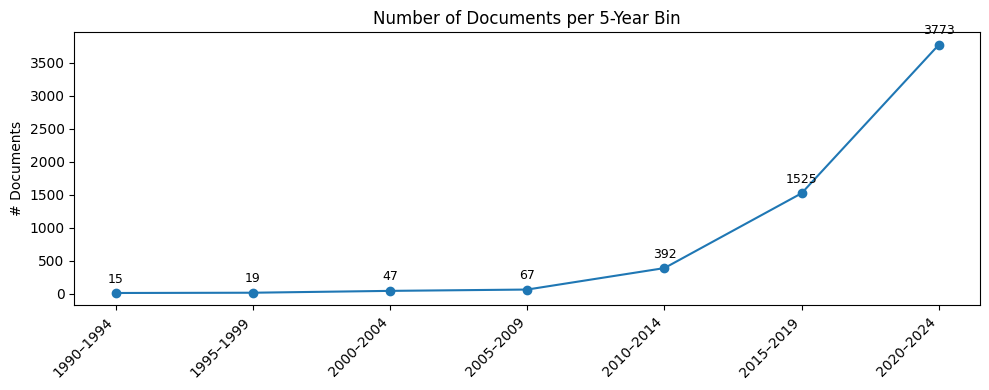

Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/docs_per_5yearbin.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/docs_per_5yearbin.pdf


/tmp/ipykernel_7071/1379887018.py:509: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0.16)


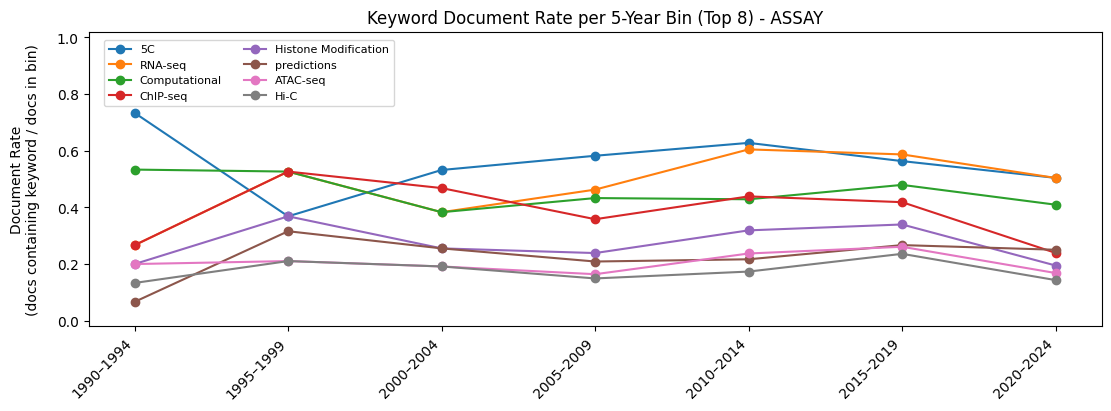

Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/assay_doc_rate_5yearbin_top8.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/assay_doc_rate_5yearbin_top8.pdf


/tmp/ipykernel_7071/1379887018.py:509: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0.16)


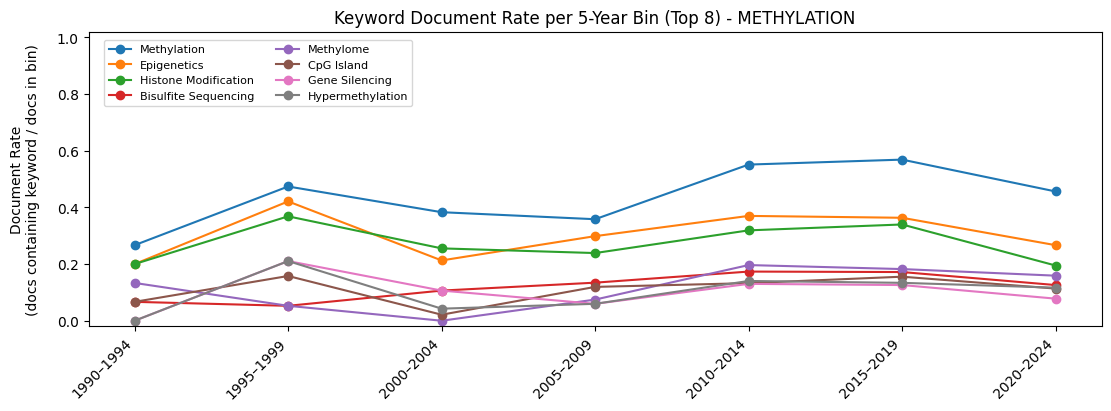

Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/methylation_doc_rate_5yearbin_top8.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/methylation_doc_rate_5yearbin_top8.pdf


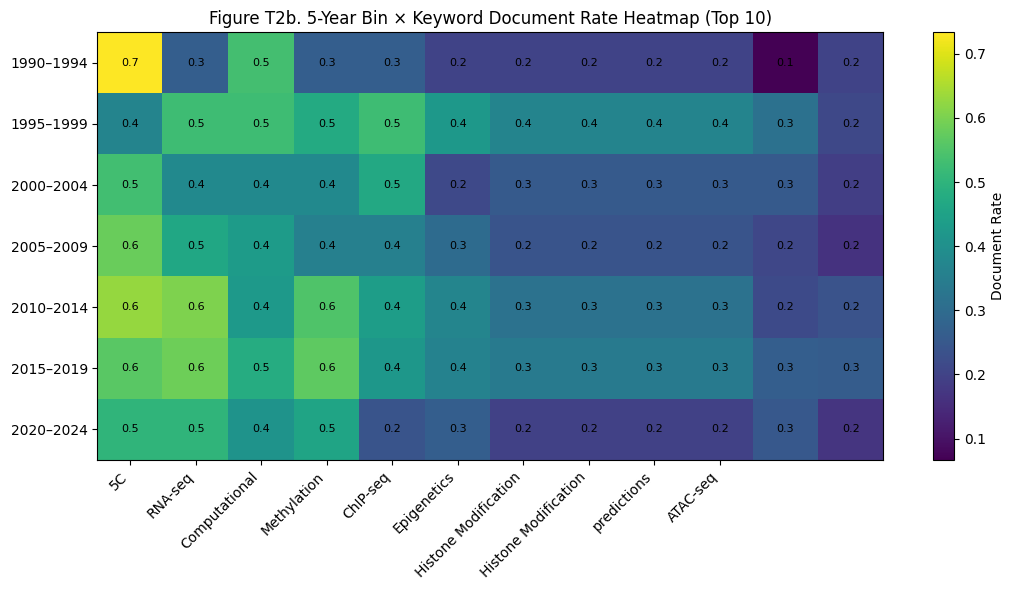

Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/FigureT2b_heatmap_keyword_rate_5yearbin_top10.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/FigureT2b_heatmap_keyword_rate_5yearbin_top10.pdf


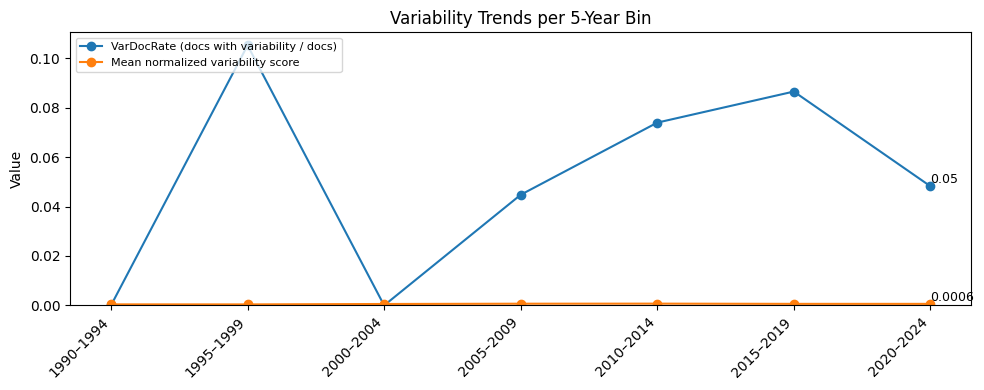

Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/variability_trend_5yearbin.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add/variability_trend_5yearbin.pdf

DONE. Output folder:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add


In [ ]:
# =========================================
# Colab: Temporal Trend Analysis (Paper-ready, fixed)
# - En dash applied to numeric ranges
# - Figure titles preserved as shown
# - Legend adjusted to avoid excessive overlap
# - FIXED: y-axis label clipping in Figure (b), (c)
# - UPDATED: y-axis label changed to 2 lines
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) PATHS
# =========================
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"

OUT_DIR = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_trends_fixed_240126_add"

os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) KEYWORDS
# =========================
assay_keywords = [
    "5C",
    "ChIA-PET",
    "Hi-C",
    "DNase-seq",
    "FAIRE-seq",
    "ATAC-seq",
    "ChIP-seq",
    "WGBS",
    "RRBS",
    "methylation array",
    "Computational",
    "predictions",
    "RNA-seq",
    "CLIP-seq",
    "RIP-seq",
    "Histone Modification"
]

methylation_keywords = [
    "Methylation",
    "CpG Island",
    "Hypermethylation",
    "Hypomethylation",
    "Epigenetics",
    "Histone Modification",
    "Gene Silencing",
    "DNMT",
    "Methylome",
    "Bisulfite Sequencing"
]

variability_patterns = [
    "chromatin variability",
    "chromatin heterogeneity",
    "dynamic chromatin",
    "chromatin plasticity",
    "chromatin state variation",
    "epigenetic variability",
    "epigenetic plasticity",
    "epigenetic heterogeneity"
]

variability_terms_for_score = [
    "variability",
    "heterogeneity",
    "dynamic",
    "plasticity"
]

# =========================
# 3) PARAMETERS
# =========================
YEAR_MIN = 1990
YEAR_MAX = 2025

BIN_SIZE = 5
MIN_DOCS_PER_BIN = 10

TOP_K_ASSAY = 8
TOP_K_METH = 8
TOP_K_HEATMAP = 10

PROGRESS_EVERY = 200

# =========================
# 4) HELPERS
# =========================
def normalize_text(t: str):
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

def load_txt_files_from_folder(folder_path: str):

    files = []

    for fn in sorted(os.listdir(folder_path)):

        if fn.lower().endswith(".txt"):

            fp = os.path.join(folder_path, fn)

            with open(
                fp,
                "r",
                encoding="utf-8",
                errors="ignore"
            ) as f:

                files.append((fn, f.read()))

    return files

def extract_year_from_filename(fn: str):

    m = re.search(r"(19\d{2}|20\d{2})", fn)

    if m:
        return int(m.group(1))

    return None

def extract_year_from_text(text: str):

    years = re.findall(r"(19\d{2}|20\d{2})", text)

    if not years:
        return None

    years = [int(y) for y in years]

    c = Counter(years)

    return c.most_common(1)[0][0]

def pick_doc_year(filename: str, text: str):

    y = extract_year_from_filename(filename)

    if y is None:
        y = extract_year_from_text(text)

    return y

def clamp_year(y):

    if y is None:
        return None

    if YEAR_MIN <= y <= YEAR_MAX:
        return y

    return None

def year_to_bin(y: int):

    start = (y // BIN_SIZE) * BIN_SIZE

    while start + BIN_SIZE - 1 < YEAR_MIN:
        start += BIN_SIZE

    return start

def doc_contains_kw(text_lower: str, kw: str):

    return kw.lower() in text_lower

def variability_sentence_present(text_lower: str):

    return any(
        p.lower() in text_lower
        for p in variability_patterns
    )

def variability_score(text_lower: str):

    return sum(
        text_lower.count(t)
        for t in variability_terms_for_score
    )

def normalized_variability_score(text_lower: str):

    n_words = max(1, len(text_lower.split()))

    return variability_score(text_lower) / n_words

def year_range_label(a):

    return f"{a}–{a+BIN_SIZE-1}"

# =========================
# 5) LOAD CORPUS
# =========================
docs = load_txt_files_from_folder(CORPUS_DIR)

print("Found .txt files:", len(docs))

# =========================
# 6) BUILD DOC TABLE
# =========================
rows = []

skipped_no_year = 0
skipped_out_of_range = 0

for i, (fn, text) in enumerate(docs, 1):

    text_norm = normalize_text(text)

    y_raw = pick_doc_year(fn, text)

    y = clamp_year(y_raw)

    if y is None:

        if y_raw is None:
            skipped_no_year += 1

        else:
            skipped_out_of_range += 1

        continue

    ybin = year_to_bin(y)

    assay_present = {
        k: int(doc_contains_kw(text_norm, k))
        for k in assay_keywords
    }

    meth_present = {
        k: int(doc_contains_kw(text_norm, k))
        for k in methylation_keywords
    }

    var_doc = int(
        variability_sentence_present(text_norm)
    )

    var_score_norm = normalized_variability_score(text_norm)

    row = {
        "file": fn,
        "year": y,
        "year_bin": ybin,
        "var_doc": var_doc,
        "var_score_norm": var_score_norm
    }

    for k, v in assay_present.items():
        row[f"ASSAY__{k}"] = v

    for k, v in meth_present.items():
        row[f"METH__{k}"] = v

    rows.append(row)

    if i % PROGRESS_EVERY == 0 or i == 1 or i == len(docs):

        print(
            f"Processed {i}/{len(docs)} docs... kept={len(rows)}"
        )

df = pd.DataFrame(rows)

print("\nKept docs with valid years:", len(df))
print("Skipped no year:", skipped_no_year)
print("Skipped out of range:", skipped_out_of_range)

doc_table_path = os.path.join(
    OUT_DIR,
    "doc_table_year_keywords_variability.csv"
)

df.to_csv(
    doc_table_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved doc table:", doc_table_path)

# =========================
# 7) AGGREGATE BY YEAR_BIN
# =========================
bin_counts = (
    df.groupby("year_bin")
    .size()
    .rename("n_docs")
    .to_frame()
)

bin_counts = bin_counts[
    bin_counts["n_docs"] >= MIN_DOCS_PER_BIN
]

valid_bins = set(bin_counts.index.tolist())

df2 = df[
    df["year_bin"].isin(valid_bins)
].copy()

t1 = (
    df2.groupby("year_bin")
    .size()
    .rename("n_docs")
    .reset_index()
)

def compute_doc_rate(df_bin, prefix):

    cols = [
        c for c in df_bin.columns
        if c.startswith(prefix)
    ]

    rates = {}

    for c in cols:

        kw = c.split("__", 1)[1]

        rates[kw] = (
            df_bin.groupby("year_bin")[c]
            .mean()
        )

    return pd.DataFrame(rates)

assay_rate = compute_doc_rate(df2, "ASSAY__")
meth_rate  = compute_doc_rate(df2, "METH__")

t3 = (
    df2.groupby("year_bin")
    .agg(
        n_docs=("file", "count"),
        var_doc_rate=("var_doc", "mean"),
        var_score_norm_mean=("var_score_norm", "mean")
    )
    .reset_index()
)

# =========================
# 8) SAVE TABLES
# =========================
t1_path = os.path.join(
    OUT_DIR,
    "T1_docs_per_yearbin.csv"
)

assay_rate_path = os.path.join(
    OUT_DIR,
    "T2_assay_doc_rate_per_yearbin.csv"
)

meth_rate_path = os.path.join(
    OUT_DIR,
    "T2_methylation_doc_rate_per_yearbin.csv"
)

t3_path = os.path.join(
    OUT_DIR,
    "T3_variability_trend_per_yearbin.csv"
)

t1.to_csv(t1_path, index=False, encoding="utf-8-sig")
assay_rate.to_csv(assay_rate_path, encoding="utf-8-sig")
meth_rate.to_csv(meth_rate_path, encoding="utf-8-sig")
t3.to_csv(t3_path, index=False, encoding="utf-8-sig")

print("\nSaved aggregated tables:")
print(" -", t1_path)
print(" -", assay_rate_path)
print(" -", meth_rate_path)
print(" -", t3_path)

# =========================
# 9) FIGURE T1
# =========================
plt.figure(figsize=(10,4))

x = t1["year_bin"].tolist()
y = t1["n_docs"].tolist()

plt.plot(x, y, marker="o")

plt.xticks(
    x,
    [year_range_label(a) for a in x],
    rotation=45,
    ha="right"
)

plt.ylabel("# Documents")

plt.title(
    f"Number of Documents per {BIN_SIZE}-Year Bin"
)

ymax = max(y) if y else 1

offset = max(1, int(ymax * 0.03))

for xi, yi in zip(x, y):

    plt.text(
        xi,
        yi + offset,
        str(int(yi)),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

fig_t1_png = os.path.join(
    OUT_DIR,
    f"docs_per_{BIN_SIZE}yearbin.png"
)

fig_t1_pdf = os.path.join(
    OUT_DIR,
    f"docs_per_{BIN_SIZE}yearbin.pdf"
)

plt.savefig(fig_t1_png, dpi=600)
plt.savefig(fig_t1_pdf)

plt.show()

print("Saved:", fig_t1_png)
print("Saved:", fig_t1_pdf)

# =========================
# 10) FIGURE T2
# UPDATED VERSION
# =========================
def plot_topk_rates(rate_df, title, out_prefix, top_k=8):

    top_terms = (
        rate_df.mean(axis=0)
        .sort_values(ascending=False)
        .head(top_k)
        .index.tolist()
    )

    sub = rate_df[top_terms].copy()

    sub = sub.sort_index()

    fig, ax = plt.subplots(
        figsize=(11,4),
        constrained_layout=True
    )

    xbins = sub.index.tolist()

    for term in top_terms:

        ax.plot(
            xbins,
            sub[term].values,
            marker="o",
            label=term
        )

    ax.set_xticks(xbins)

    ax.set_xticklabels(
        [year_range_label(a) for a in xbins],
        rotation=45,
        ha="right"
    )

    # =========================
    # UPDATED:
    # 2-line y-axis label
    # =========================
    ax.set_ylabel(
        "Document Rate\n(docs containing keyword / docs in bin)",
        labelpad=12
    )

    ax.set_title(title)

    ax.set_ylim(-0.02, 1.02)

    ax.legend(
        loc="upper left",
        ncol=2,
        fontsize=8,
        frameon=True,
        bbox_to_anchor=(0.01, 0.99)
    )

    plt.subplots_adjust(left=0.16)

    png = os.path.join(
        OUT_DIR,
        f"{out_prefix}_top{top_k}.png"
    )

    pdf = os.path.join(
        OUT_DIR,
        f"{out_prefix}_top{top_k}.pdf"
    )

    plt.savefig(
        png,
        dpi=600,
        bbox_inches="tight"
    )

    plt.savefig(
        pdf,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", png)
    print("Saved:", pdf)

# =========================
# (b) ASSAY
# =========================
plot_topk_rates(
    assay_rate,
    title=f"Keyword Document Rate per {BIN_SIZE}-Year Bin (Top {TOP_K_ASSAY}) - ASSAY",
    out_prefix=f"assay_doc_rate_{BIN_SIZE}yearbin",
    top_k=TOP_K_ASSAY
)

# =========================
# (c) METHYLATION
# =========================
plot_topk_rates(
    meth_rate,
    title=f"Keyword Document Rate per {BIN_SIZE}-Year Bin (Top {TOP_K_METH}) - METHYLATION",
    out_prefix=f"methylation_doc_rate_{BIN_SIZE}yearbin",
    top_k=TOP_K_METH
)

# =========================
# 11) FIGURE T2b HEATMAP
# =========================
combined_rate = pd.concat(
    [assay_rate, meth_rate],
    axis=1
)

top_terms = (
    combined_rate.mean(axis=0)
    .sort_values(ascending=False)
    .head(TOP_K_HEATMAP)
    .index.tolist()
)

heat = combined_rate[top_terms].copy()

heat = heat.sort_index()

plt.figure(figsize=(11,6))

im = plt.imshow(
    heat.values,
    aspect="auto"
)

plt.xticks(
    range(len(top_terms)),
    top_terms,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(heat.index)),
    [year_range_label(a) for a in heat.index.tolist()]
)

plt.colorbar(im, label="Document Rate")

plt.title(
    f"Figure T2b. {BIN_SIZE}-Year Bin × Keyword Document Rate Heatmap (Top {TOP_K_HEATMAP})"
)

for i in range(heat.shape[0]):

    for j in range(heat.shape[1]):

        val = float(heat.iat[i, j])

        if val >= 0.05:

            plt.text(
                j,
                i,
                f"{val:.1f}",
                ha="center",
                va="center",
                fontsize=8
            )

plt.tight_layout()

fig_t2b_png = os.path.join(
    OUT_DIR,
    f"FigureT2b_heatmap_keyword_rate_{BIN_SIZE}yearbin_top{TOP_K_HEATMAP}.png"
)

fig_t2b_pdf = os.path.join(
    OUT_DIR,
    f"FigureT2b_heatmap_keyword_rate_{BIN_SIZE}yearbin_top{TOP_K_HEATMAP}.pdf"
)

plt.savefig(fig_t2b_png, dpi=600)
plt.savefig(fig_t2b_pdf)

plt.show()

print("Saved:", fig_t2b_png)
print("Saved:", fig_t2b_pdf)

# =========================
# 12) FIGURE T3
# =========================
t3 = t3.sort_values("year_bin")

plt.figure(figsize=(10,4))

x = t3["year_bin"].tolist()

y1 = t3["var_doc_rate"].tolist()
y2 = t3["var_score_norm_mean"].tolist()

plt.plot(
    x,
    y1,
    marker="o",
    label="VarDocRate (docs with variability / docs)"
)

plt.plot(
    x,
    y2,
    marker="o",
    label="Mean normalized variability score"
)

plt.xticks(
    x,
    [year_range_label(a) for a in x],
    rotation=45,
    ha="right"
)

plt.ylabel("Value")

plt.title(
    f"Variability Trends per {BIN_SIZE}-Year Bin"
)

plt.ylim(bottom=0)

if len(x) > 0:

    plt.text(
        x[-1],
        y1[-1],
        f"{y1[-1]:.2f}",
        ha="left",
        va="bottom",
        fontsize=9
    )

    plt.text(
        x[-1],
        y2[-1],
        f"{y2[-1]:.4f}",
        ha="left",
        va="bottom",
        fontsize=9
    )

plt.legend(
    loc="upper left",
    fontsize=8,
    frameon=True
)

plt.tight_layout()

fig_t3_png = os.path.join(
    OUT_DIR,
    f"variability_trend_{BIN_SIZE}yearbin.png"
)

fig_t3_pdf = os.path.join(
    OUT_DIR,
    f"variability_trend_{BIN_SIZE}yearbin.pdf"
)

plt.savefig(fig_t3_png, dpi=600)
plt.savefig(fig_t3_pdf)

plt.show()

print("Saved:", fig_t3_png)
print("Saved:", fig_t3_pdf)

print("\nDONE. Output folder:")
print(" -", OUT_DIR)

**Journal-level Stratification**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Found .txt files: 6152

 Kept docs with journal extracted: 87
 Skipped (no journal found): 6065
 Saved doc table: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126/doc_table_with_journal_keywords.csv

 Saved Table J1: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126/Table_J1_group_definition_counts.csv
 Saved Table J2: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126/Table_J2_group_metrics_keyword_doc_rates.csv
 Saved journal stats: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126/journal_stats_group_assignment.csv


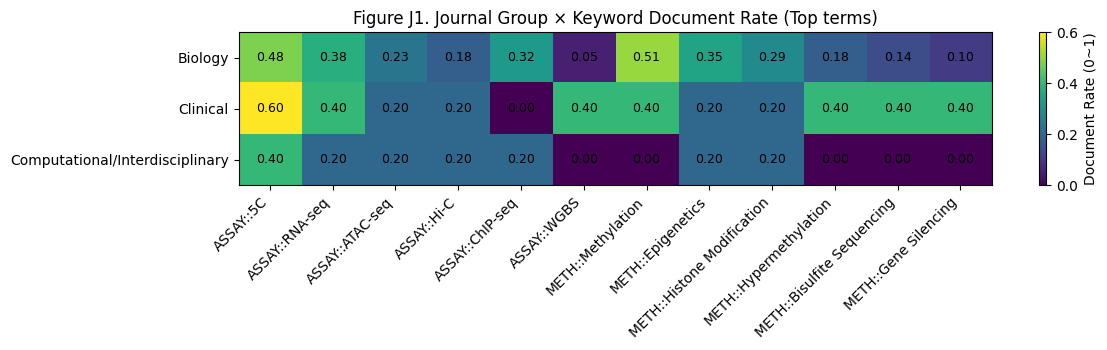

 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126/FigureJ1_group_keyword_heatmap.png
 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126/FigureJ1_group_keyword_heatmap.pdf


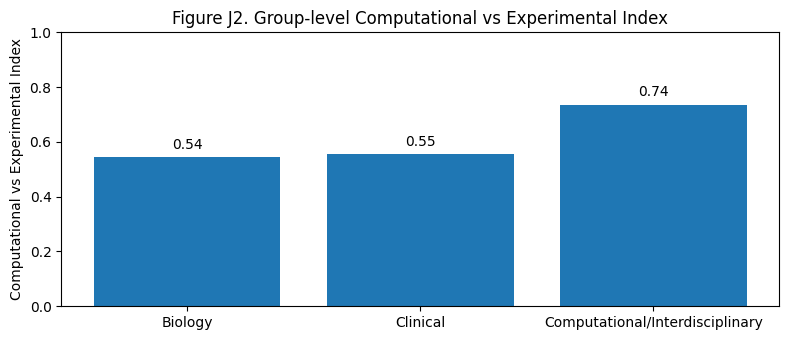

 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126/FigureJ2_comp_vs_exp_index.png
 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126/FigureJ2_comp_vs_exp_index.pdf

 DONE. Output folder:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126


In [ ]:
# =========================================
# Colab: Journal-level Stratification (Paper-ready)
# - Reads all .txt files in a folder (1 file = 1 document)
# - Extracts JOURNAL name from:
#   (A) filename (optional patterns) OR
#   (B) text fields (PubMed-style JT / Journal / Source / etc.)
# - Stratifies journals into 3 groups:
#   (1) Rule-based by journal title keywords  (easy to explain)
#   (2) Score-based by computational keyword rate (more "computational")
# - Computes group-level metrics:
#   - ASSAY keyword doc ratio
#   - METHYLATION keyword doc ratio
#   - Computational vs Experimental index
# - Outputs:
#   Table J1: group definition + #journals + #docs
#   Table J2: group × (metrics & keyword doc rates)
#   Figure J1: group × keyword doc rate heatmap (cell values)
#   Figure J2: group-level summary bar (Comp-vs-Exp index)
# - Saves: CSV + PNG(600dpi) + PDF(vector)
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) PATHS
# =========================
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR    = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) KEYWORDS
# =========================
assay_keywords = [
    "5C", "ChIA-PET", "Hi-C", "DNase-seq", "FAIRE-seq", "ATAC-seq", "ChIP-seq",
    "WGBS", "RRBS", "methylation array", "RNA-seq", "CLIP-seq", "RIP-seq"
]

methylation_keywords = [
    "Methylation", "CpG Island", "Hypermethylation", "Hypomethylation",
    "Epigenetics", "Histone Modification", "Gene Silencing", "DNMT",
    "Methylome", "Bisulfite Sequencing"
]

mechanism_keywords = [
    "DNA methylation", "histone modification", "chromatin remodeling",
    "noncoding RNA", "epigenetic regulation"
]

# computational / experimental keyword sets for a simple index
computational_keywords = [
    "computational", "prediction", "predictions", "model", "models",
    "machine learning", "deep learning", "neural", "algorithm",
    "bioinformatics", "in silico", "simulation", "pipeline"
]

experimental_keywords = [
    "assay", "sequencing", "experiment", "experimental", "in vitro", "in vivo",
    "chip-seq", "atac-seq", "wgbs", "rrbs", "bisulfite", "dnase-seq", "hi-c"
]

# =========================
# 3) PARAMETERS
# =========================
PROGRESS_EVERY = 200

# --- Journal extraction ---
# Some corpora store journal names in text (PubMed / exported metadata).
# We'll try multiple patterns.
MAX_SCAN_CHARS_FOR_JOURNAL = 80_000  # scan head only (faster, usually enough)

# --- Stratification method ---
# "rule"  : rule-based by journal title keywords (추천: 논문 설명 쉬움)
# "score" : score-based by computational ratio (조금 더 계산적)
STRATIFY_METHOD = "rule"   # "rule" or "score"

# For score-based split: top=Computational, mid=Biology, low=Clinical (or vice versa)
# You can adjust thresholds after seeing distribution.
SCORE_TOP_Q = 0.67   # upper quantile
SCORE_LOW_Q = 0.33   # lower quantile

# =========================
# 4) HELPERS
# =========================
def normalize_text(t: str) -> str:
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

def load_txt_files_from_folder(folder_path: str):
    files = []
    for fn in sorted(os.listdir(folder_path)):
        if fn.lower().endswith(".txt"):
            fp = os.path.join(folder_path, fn)
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                files.append((fn, f.read()))
    return files

def doc_contains_kw(text_lower: str, kw: str) -> int:
    return int(kw.lower() in text_lower)

def any_hit(text_lower: str, kws) -> int:
    return int(any(k.lower() in text_lower for k in kws))

def count_hits(text_lower: str, kws) -> int:
    # counts substring occurrences (rough but ok for index)
    return sum(text_lower.count(k.lower()) for k in kws)

def extract_journal_from_text(raw_text: str):
    # Search likely journal fields.
    # Try common PubMed export tags:
    # "JT  - Journal Title"
    # "Journal: Nature Genetics"
    # "Source: ..."
    # We'll scan only the first part for speed.
    head = raw_text[:MAX_SCAN_CHARS_FOR_JOURNAL]

    patterns = [
        r"\bJT\s*-\s*(.+)",                         # PubMed
        r"\bJournal\s*:\s*(.+)",                    # generic
        r"\bSOURCE\s*:\s*(.+)",                     # some exports
        r"\bSO\s*-\s*(.+)",                         # MEDLINE-like
        r"\bT2\s*-\s*(.+)",                         # RIS-like
    ]

    for pat in patterns:
        m = re.search(pat, head, flags=re.IGNORECASE)
        if m:
            j = m.group(1).strip()
            # cut at line break or overly long tail
            j = re.split(r"[\r\n]", j)[0].strip()
            j = re.split(r"\s{2,}", j)[0].strip()
            # remove trailing metadata-like separators
            j = re.sub(r"\s*\.\s*$", "", j)
            # sanity: keep moderate length
            if 3 <= len(j) <= 160:
                return j
    return None

def extract_journal_from_filename(fn: str):
    # If your filenames embed journal like "...__Nature_Genetics__2019.txt"
    # you can customize here. By default: None.
    return None

def pick_journal(fn: str, text: str):
    j = extract_journal_from_filename(fn)
    if j is None:
        j = extract_journal_from_text(text)
    return j

# ---- Rule-based journal grouping (easy to justify in paper) ----
BIO_RULE = ["bio", "biology", "genomic", "genetics", "molecular", "epigen", "chromatin", "cell", "nucleic"]
CLIN_RULE = ["clinical", "medicine", "medical", "bmj", "lancet", "oncology", "neurology", "psychiatry", "diabetes", "cancer"]
COMP_RULE = ["bioinformatics", "computational", "systems", "informatics", "machine learning", "artificial intelligence", "data", "algorithm", "model"]

def rule_group_journal(journal: str):
    j = journal.lower()
    comp = any(w in j for w in COMP_RULE)
    clin = any(w in j for w in CLIN_RULE)
    bio  = any(w in j for w in BIO_RULE)

    # priority: Computational > Clinical > Biology (조정 가능)
    if comp:
        return "Computational/Interdisciplinary"
    if clin:
        return "Clinical"
    if bio:
        return "Biology"
    # fallback
    return "Biology"

# ---- Score-based journal grouping (more "computational") ----
def computational_score_for_doc(text_lower: str):
    # score = (computational hits) / (computational+experimental hits + 1)
    c = count_hits(text_lower, computational_keywords)
    e = count_hits(text_lower, experimental_keywords)
    return c / (c + e + 1e-9)

# =========================
# 5) LOAD CORPUS & BUILD DOC TABLE
# =========================
docs = load_txt_files_from_folder(CORPUS_DIR)
print(" Found .txt files:", len(docs))

rows = []
skipped_no_journal = 0

for i, (fn, text) in enumerate(docs, 1):
    j = pick_journal(fn, text)
    if j is None:
        skipped_no_journal += 1
        continue

    text_lower = normalize_text(text)

    row = {
        "file": fn,
        "journal": j,
        "assay_any": any_hit(text_lower, assay_keywords),
        "meth_any": any_hit(text_lower, methylation_keywords),
        "mech_any": any_hit(text_lower, mechanism_keywords),
    }

    # doc-level keyword presence for ratios
    for k in assay_keywords:
        row[f"ASSAY__{k}"] = doc_contains_kw(text_lower, k)
    for k in methylation_keywords:
        row[f"METH__{k}"] = doc_contains_kw(text_lower, k)

    # computational/experimental counts for index
    row["comp_hits"] = count_hits(text_lower, computational_keywords)
    row["exp_hits"]  = count_hits(text_lower, experimental_keywords)
    row["comp_score_doc"] = computational_score_for_doc(text_lower)

    rows.append(row)

    if i % PROGRESS_EVERY == 0 or i == 1 or i == len(docs):
        print(f"Processed {i}/{len(docs)} docs... kept={len(rows)}")

df = pd.DataFrame(rows)
print("\n Kept docs with journal extracted:", len(df))
print(" Skipped (no journal found):", skipped_no_journal)

doc_table_path = os.path.join(OUT_DIR, "doc_table_with_journal_keywords.csv")
df.to_csv(doc_table_path, index=False, encoding="utf-8-sig")
print(" Saved doc table:", doc_table_path)

# =========================
# 6) STRATIFY JOURNALS INTO 3 GROUPS
# =========================
# journal-level aggregates
j_stats = df.groupby("journal").agg(
    n_docs=("file", "count"),
    comp_score_mean=("comp_score_doc", "mean"),
).reset_index()

if STRATIFY_METHOD == "rule":
    j_stats["group"] = j_stats["journal"].apply(rule_group_journal)

elif STRATIFY_METHOD == "score":
    # split journals by computational score quantiles
    q_low = j_stats["comp_score_mean"].quantile(SCORE_LOW_Q)
    q_top = j_stats["comp_score_mean"].quantile(SCORE_TOP_Q)

    def score_group(s):
        if s >= q_top:
            return "Computational/Interdisciplinary"
        if s <= q_low:
            return "Clinical"
        return "Biology"

    j_stats["group"] = j_stats["comp_score_mean"].apply(score_group)

else:
    raise ValueError("STRATIFY_METHOD must be 'rule' or 'score'")

# attach group back to docs
df = df.merge(j_stats[["journal", "group"]], on="journal", how="left")

# =========================
# 7) TABLE J1: group definition + #journals + #docs
# =========================
group_summary = df.groupby("group").agg(
    n_journals=("journal", "nunique"),
    n_docs=("file", "count"),
    mean_comp_score=("comp_score_doc", "mean"),
).reset_index()

# group rule text for paper
if STRATIFY_METHOD == "rule":
    criteria_text = {
        "Biology": "Journal title contains bio/biology/genomic/genetics/molecular/epigen/chromatin/cell… (fallback group).",
        "Clinical": "Journal title contains clinical/medicine/medical/BMJ/Lancet/oncology/neurology/psychiatry…",
        "Computational/Interdisciplinary": "Journal title contains bioinformatics/computational/systems/informatics/ML/AI/data/algorithm/model… (priority)."
    }
else:
    criteria_text = {
        "Biology": f"Middle quantiles of journal-level computational score (between {SCORE_LOW_Q:.2f} and {SCORE_TOP_Q:.2f}).",
        "Clinical": f"Lower quantile journals (≤ Q{SCORE_LOW_Q:.2f}) by computational score (more experimental/clinical leaning).",
        "Computational/Interdisciplinary": f"Upper quantile journals (≥ Q{SCORE_TOP_Q:.2f}) by computational score."
    }

group_summary["group_definition"] = group_summary["group"].map(criteria_text)

table_j1_path = os.path.join(OUT_DIR, "Table_J1_group_definition_counts.csv")
group_summary.to_csv(table_j1_path, index=False, encoding="utf-8-sig")
print("\n Saved Table J1:", table_j1_path)

# =========================
# 8) GROUP-LEVEL METRICS + KEYWORD DOC RATIOS (Table J2)
# =========================
# simple comp-vs-exp index at group level:
# (sum comp_hits) / (sum comp_hits + sum exp_hits)
g_metrics = df.groupby("group").agg(
    n_docs=("file", "count"),
    assay_doc_ratio=("assay_any", "mean"),
    meth_doc_ratio=("meth_any", "mean"),
    mech_doc_ratio=("mech_any", "mean"),
    comp_hits_sum=("comp_hits", "sum"),
    exp_hits_sum=("exp_hits", "sum"),
).reset_index()

g_metrics["comp_vs_exp_index"] = g_metrics["comp_hits_sum"] / (g_metrics["comp_hits_sum"] + g_metrics["exp_hits_sum"] + 1e-9)

# keyword doc ratios per group (ASSAY + METH)
assay_cols = [c for c in df.columns if c.startswith("ASSAY__")]
meth_cols  = [c for c in df.columns if c.startswith("METH__")]

assay_rate = df.groupby("group")[assay_cols].mean()
assay_rate.columns = [c.split("__",1)[1] for c in assay_rate.columns]
meth_rate = df.groupby("group")[meth_cols].mean()
meth_rate.columns  = [c.split("__",1)[1] for c in meth_rate.columns]

# combine into one wide table for J2
j2 = g_metrics.set_index("group")
j2 = j2.join(assay_rate.add_prefix("ASSAY_rate__"), how="left")
j2 = j2.join(meth_rate.add_prefix("METH_rate__"),  how="left")
j2 = j2.reset_index()

table_j2_path = os.path.join(OUT_DIR, "Table_J2_group_metrics_keyword_doc_rates.csv")
j2.to_csv(table_j2_path, index=False, encoding="utf-8-sig")
print(" Saved Table J2:", table_j2_path)

# Also save journal-level stats (optional for appendix)
journal_stats_path = os.path.join(OUT_DIR, "journal_stats_group_assignment.csv")
j_stats.sort_values(["group","n_docs"], ascending=[True, False]).to_csv(journal_stats_path, index=False, encoding="utf-8-sig")
print(" Saved journal stats:", journal_stats_path)

# =========================
# 9) FIGURE J1: group × keyword doc rate heatmap + cell values
# =========================
# Choose top keywords globally by average doc rate
assay_top = assay_rate.mean(axis=0).sort_values(ascending=False).head(6).index.tolist()
meth_top  = meth_rate.mean(axis=0).sort_values(ascending=False).head(6).index.tolist()
heat_terms = [f"ASSAY::{t}" for t in assay_top] + [f"METH::{t}" for t in meth_top]

# build heat matrix [group x term]
groups = sorted(df["group"].dropna().unique().tolist())
heat = []
for g in groups:
    row = []
    for t in assay_top:
        row.append(float(assay_rate.loc[g, t]) if (g in assay_rate.index and t in assay_rate.columns) else 0.0)
    for t in meth_top:
        row.append(float(meth_rate.loc[g, t]) if (g in meth_rate.index and t in meth_rate.columns) else 0.0)
    heat.append(row)

plt.figure(figsize=(12, 3.6))
im = plt.imshow(heat, aspect="auto")
plt.xticks(range(len(heat_terms)), heat_terms, rotation=45, ha="right")
plt.yticks(range(len(groups)), groups)
plt.colorbar(im, label="Document Rate (0~1)")
plt.title("Figure J1. Journal Group × Keyword Document Rate (Top terms)")

# in-cell values
for i in range(len(groups)):
    for j in range(len(heat_terms)):
        val = float(heat[i][j])
        plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
fig_j1_png = os.path.join(OUT_DIR, "FigureJ1_group_keyword_heatmap.png")
fig_j1_pdf = os.path.join(OUT_DIR, "FigureJ1_group_keyword_heatmap.pdf")
plt.savefig(fig_j1_png, dpi=600)
plt.savefig(fig_j1_pdf)
plt.show()

print(" Saved:", fig_j1_png)
print(" Saved:", fig_j1_pdf)

# =========================
# 10) FIGURE J2: group-level Comp vs Exp index (simple, interpretable)
# =========================
tmp = g_metrics.copy()
tmp = tmp.set_index("group").loc[groups].reset_index()

plt.figure(figsize=(8, 3.5))
plt.bar(tmp["group"], tmp["comp_vs_exp_index"])
plt.ylim(0, 1.0)
plt.ylabel("Computational vs Experimental Index")
plt.title("Figure J2. Group-level Computational vs Experimental Index")

# value labels
for x, y in zip(range(len(tmp)), tmp["comp_vs_exp_index"].tolist()):
    plt.text(x, y + 0.02, f"{y:.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
fig_j2_png = os.path.join(OUT_DIR, "FigureJ2_comp_vs_exp_index.png")
fig_j2_pdf = os.path.join(OUT_DIR, "FigureJ2_comp_vs_exp_index.pdf")
plt.savefig(fig_j2_png, dpi=600)
plt.savefig(fig_j2_pdf)
plt.show()

print(" Saved:", fig_j2_png)
print(" Saved:", fig_j2_pdf)

print("\n DONE. Output folder:")
print(" -", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Found .txt files: 6152

 Kept docs with journal extracted: 87
 Skipped (no journal found): 6065
 Saved doc table: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126_add/doc_table_with_journal_keywords.csv

 Saved Table J1: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126_add/Table_J1_group_definition_counts.csv
 Saved Table J2: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126_add/Table_J2_group_metrics_keyword_doc_rates.csv
 Saved journal stats: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126_add/journal_stats_group_assignment.csv


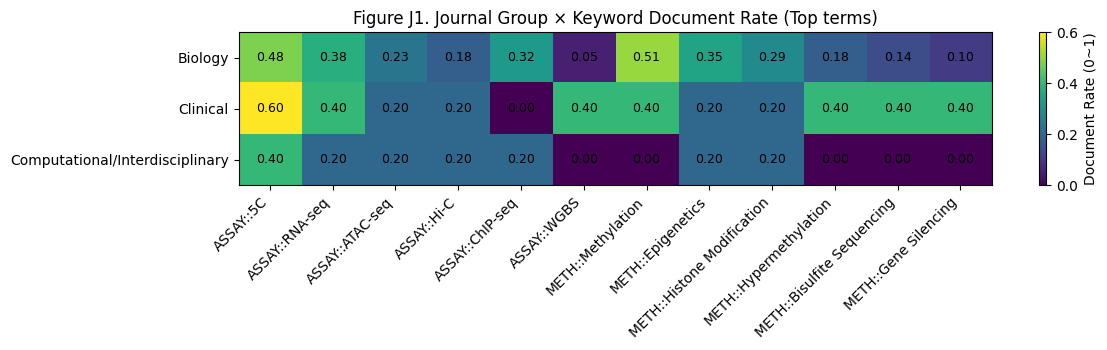

 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126_add/FigureJ1_group_keyword_heatmap.png
 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126_add/FigureJ1_group_keyword_heatmap.pdf


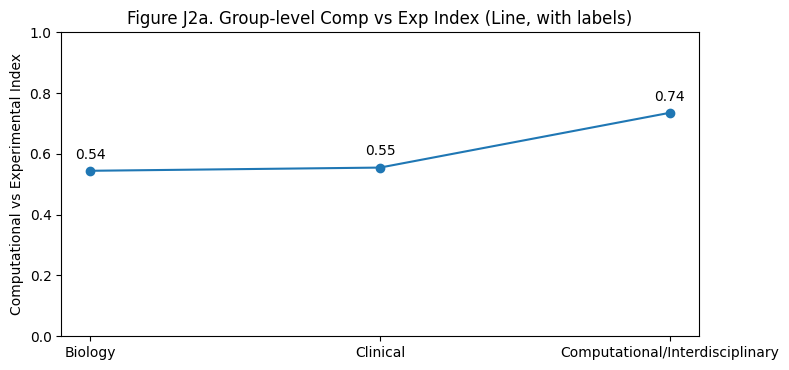

 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126_add/FigureJ2a_comp_vs_exp_index_line_with_labels.png
 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126_add/FigureJ2a_comp_vs_exp_index_line_with_labels.pdf


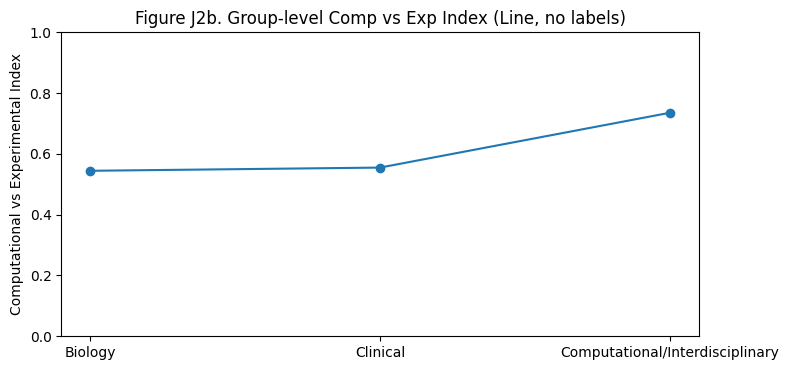

 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126_add/FigureJ2b_comp_vs_exp_index_line_no_labels.png
 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126_add/FigureJ2b_comp_vs_exp_index_line_no_labels.pdf

 DONE. Output folder:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126_add


In [ ]:
# =========================================
# Colab: Journal-level Stratification (Paper-ready)
# UPDATE:
# - Figure J2 (Comp-vs-Exp index) -> LINE plots (2 versions)
#   (1) with value labels
#   (2) without value labels
# - Saves: PNG(600dpi) + PDF(vector) for both
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) PATHS
# =========================
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR    = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/journal_stratification_240126_add"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) KEYWORDS
# =========================
assay_keywords = [
    "5C", "ChIA-PET", "Hi-C", "DNase-seq", "FAIRE-seq", "ATAC-seq", "ChIP-seq",
    "WGBS", "RRBS", "methylation array", "RNA-seq", "CLIP-seq", "RIP-seq"
]

methylation_keywords = [
    "Methylation", "CpG Island", "Hypermethylation", "Hypomethylation",
    "Epigenetics", "Histone Modification", "Gene Silencing", "DNMT",
    "Methylome", "Bisulfite Sequencing"
]

mechanism_keywords = [
    "DNA methylation", "histone modification", "chromatin remodeling",
    "noncoding RNA", "epigenetic regulation"
]

computational_keywords = [
    "computational", "prediction", "predictions", "model", "models",
    "machine learning", "deep learning", "neural", "algorithm",
    "bioinformatics", "in silico", "simulation", "pipeline"
]

experimental_keywords = [
    "assay", "sequencing", "experiment", "experimental", "in vitro", "in vivo",
    "chip-seq", "atac-seq", "wgbs", "rrbs", "bisulfite", "dnase-seq", "hi-c"
]

# =========================
# 3) PARAMETERS
# =========================
PROGRESS_EVERY = 200

MAX_SCAN_CHARS_FOR_JOURNAL = 80_000

# stratification method
STRATIFY_METHOD = "rule"  # "rule" or "score"
SCORE_TOP_Q = 0.67
SCORE_LOW_Q = 0.33

# =========================
# 4) HELPERS
# =========================
def normalize_text(t: str) -> str:
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

def load_txt_files_from_folder(folder_path: str):
    files = []
    for fn in sorted(os.listdir(folder_path)):
        if fn.lower().endswith(".txt"):
            fp = os.path.join(folder_path, fn)
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                files.append((fn, f.read()))
    return files

def doc_contains_kw(text_lower: str, kw: str) -> int:
    return int(kw.lower() in text_lower)

def any_hit(text_lower: str, kws) -> int:
    return int(any(k.lower() in text_lower for k in kws))

def count_hits(text_lower: str, kws) -> int:
    return sum(text_lower.count(k.lower()) for k in kws)

def extract_journal_from_text(raw_text: str):
    head = raw_text[:MAX_SCAN_CHARS_FOR_JOURNAL]
    patterns = [
        r"\bJT\s*-\s*(.+)",
        r"\bJournal\s*:\s*(.+)",
        r"\bSOURCE\s*:\s*(.+)",
        r"\bSO\s*-\s*(.+)",
        r"\bT2\s*-\s*(.+)",
    ]
    for pat in patterns:
        m = re.search(pat, head, flags=re.IGNORECASE)
        if m:
            j = m.group(1).strip()
            j = re.split(r"[\r\n]", j)[0].strip()
            j = re.split(r"\s{2,}", j)[0].strip()
            j = re.sub(r"\s*\.\s*$", "", j)
            if 3 <= len(j) <= 160:
                return j
    return None

def extract_journal_from_filename(fn: str):
    # customize if your filename includes journal
    return None

def pick_journal(fn: str, text: str):
    j = extract_journal_from_filename(fn)
    if j is None:
        j = extract_journal_from_text(text)
    return j

BIO_RULE  = ["bio", "biology", "genomic", "genetics", "molecular", "epigen", "chromatin", "cell", "nucleic"]
CLIN_RULE = ["clinical", "medicine", "medical", "bmj", "lancet", "oncology", "neurology", "psychiatry", "diabetes", "cancer"]
COMP_RULE = ["bioinformatics", "computational", "systems", "informatics", "machine learning", "artificial intelligence", "data", "algorithm", "model"]

def rule_group_journal(journal: str):
    j = journal.lower()
    comp = any(w in j for w in COMP_RULE)
    clin = any(w in j for w in CLIN_RULE)
    bio  = any(w in j for w in BIO_RULE)
    if comp:
        return "Computational/Interdisciplinary"
    if clin:
        return "Clinical"
    if bio:
        return "Biology"
    return "Biology"

def computational_score_for_doc(text_lower: str):
    c = count_hits(text_lower, computational_keywords)
    e = count_hits(text_lower, experimental_keywords)
    return c / (c + e + 1e-9)

# =========================
# 5) LOAD CORPUS & BUILD DOC TABLE
# =========================
docs = load_txt_files_from_folder(CORPUS_DIR)
print(" Found .txt files:", len(docs))

rows = []
skipped_no_journal = 0

for i, (fn, text) in enumerate(docs, 1):
    j = pick_journal(fn, text)
    if j is None:
        skipped_no_journal += 1
        continue

    text_lower = normalize_text(text)

    row = {
        "file": fn,
        "journal": j,
        "assay_any": any_hit(text_lower, assay_keywords),
        "meth_any": any_hit(text_lower, methylation_keywords),
        "mech_any": any_hit(text_lower, mechanism_keywords),
        "comp_hits": count_hits(text_lower, computational_keywords),
        "exp_hits":  count_hits(text_lower, experimental_keywords),
        "comp_score_doc": computational_score_for_doc(text_lower),
    }

    for k in assay_keywords:
        row[f"ASSAY__{k}"] = doc_contains_kw(text_lower, k)
    for k in methylation_keywords:
        row[f"METH__{k}"] = doc_contains_kw(text_lower, k)

    rows.append(row)

    if i % PROGRESS_EVERY == 0 or i == 1 or i == len(docs):
        print(f"Processed {i}/{len(docs)} docs... kept={len(rows)}")

df = pd.DataFrame(rows)
print("\n Kept docs with journal extracted:", len(df))
print(" Skipped (no journal found):", skipped_no_journal)

doc_table_path = os.path.join(OUT_DIR, "doc_table_with_journal_keywords.csv")
df.to_csv(doc_table_path, index=False, encoding="utf-8-sig")
print(" Saved doc table:", doc_table_path)

# =========================
# 6) STRATIFY JOURNALS INTO 3 GROUPS
# =========================
j_stats = df.groupby("journal").agg(
    n_docs=("file", "count"),
    comp_score_mean=("comp_score_doc", "mean"),
).reset_index()

if STRATIFY_METHOD == "rule":
    j_stats["group"] = j_stats["journal"].apply(rule_group_journal)

elif STRATIFY_METHOD == "score":
    q_low = j_stats["comp_score_mean"].quantile(SCORE_LOW_Q)
    q_top = j_stats["comp_score_mean"].quantile(SCORE_TOP_Q)

    def score_group(s):
        if s >= q_top:
            return "Computational/Interdisciplinary"
        if s <= q_low:
            return "Clinical"
        return "Biology"

    j_stats["group"] = j_stats["comp_score_mean"].apply(score_group)
else:
    raise ValueError("STRATIFY_METHOD must be 'rule' or 'score'")

df = df.merge(j_stats[["journal", "group"]], on="journal", how="left")

# =========================
# 7) TABLE J1: group definition + #journals + #docs
# =========================
group_summary = df.groupby("group").agg(
    n_journals=("journal", "nunique"),
    n_docs=("file", "count"),
    mean_comp_score=("comp_score_doc", "mean"),
).reset_index()

if STRATIFY_METHOD == "rule":
    criteria_text = {
        "Biology": "Journal title contains bio/biology/genomic/genetics/molecular/epigen/chromatin/cell… (fallback).",
        "Clinical": "Journal title contains clinical/medicine/medical/BMJ/Lancet/oncology/neurology/psychiatry…",
        "Computational/Interdisciplinary": "Journal title contains bioinformatics/computational/systems/informatics/ML/AI/data/algorithm/model… (priority)."
    }
else:
    criteria_text = {
        "Biology": f"Middle quantiles of journal-level computational score (between Q{SCORE_LOW_Q:.2f} and Q{SCORE_TOP_Q:.2f}).",
        "Clinical": f"Lower quantile journals (≤ Q{SCORE_LOW_Q:.2f}) by computational score.",
        "Computational/Interdisciplinary": f"Upper quantile journals (≥ Q{SCORE_TOP_Q:.2f}) by computational score."
    }

group_summary["group_definition"] = group_summary["group"].map(criteria_text)

table_j1_path = os.path.join(OUT_DIR, "Table_J1_group_definition_counts.csv")
group_summary.to_csv(table_j1_path, index=False, encoding="utf-8-sig")
print("\n Saved Table J1:", table_j1_path)

# =========================
# 8) TABLE J2: group-level metrics + keyword doc ratios
# =========================
g_metrics = df.groupby("group").agg(
    n_docs=("file", "count"),
    assay_doc_ratio=("assay_any", "mean"),
    meth_doc_ratio=("meth_any", "mean"),
    mech_doc_ratio=("mech_any", "mean"),
    comp_hits_sum=("comp_hits", "sum"),
    exp_hits_sum=("exp_hits", "sum"),
).reset_index()

g_metrics["comp_vs_exp_index"] = g_metrics["comp_hits_sum"] / (g_metrics["comp_hits_sum"] + g_metrics["exp_hits_sum"] + 1e-9)

assay_cols = [c for c in df.columns if c.startswith("ASSAY__")]
meth_cols  = [c for c in df.columns if c.startswith("METH__")]

assay_rate = df.groupby("group")[assay_cols].mean()
assay_rate.columns = [c.split("__",1)[1] for c in assay_rate.columns]
meth_rate = df.groupby("group")[meth_cols].mean()
meth_rate.columns  = [c.split("__",1)[1] for c in meth_rate.columns]

j2 = g_metrics.set_index("group")
j2 = j2.join(assay_rate.add_prefix("ASSAY_rate__"), how="left")
j2 = j2.join(meth_rate.add_prefix("METH_rate__"),  how="left")
j2 = j2.reset_index()

table_j2_path = os.path.join(OUT_DIR, "Table_J2_group_metrics_keyword_doc_rates.csv")
j2.to_csv(table_j2_path, index=False, encoding="utf-8-sig")
print(" Saved Table J2:", table_j2_path)

journal_stats_path = os.path.join(OUT_DIR, "journal_stats_group_assignment.csv")
j_stats.sort_values(["group","n_docs"], ascending=[True, False]).to_csv(journal_stats_path, index=False, encoding="utf-8-sig")
print(" Saved journal stats:", journal_stats_path)

# =========================
# 9) FIGURE J1: group × keyword doc rate heatmap + cell values
# =========================
assay_top = assay_rate.mean(axis=0).sort_values(ascending=False).head(6).index.tolist()
meth_top  = meth_rate.mean(axis=0).sort_values(ascending=False).head(6).index.tolist()
heat_terms = [f"ASSAY::{t}" for t in assay_top] + [f"METH::{t}" for t in meth_top]

groups = sorted(df["group"].dropna().unique().tolist())
heat = []
for g in groups:
    row = []
    for t in assay_top:
        row.append(float(assay_rate.loc[g, t]) if (g in assay_rate.index and t in assay_rate.columns) else 0.0)
    for t in meth_top:
        row.append(float(meth_rate.loc[g, t]) if (g in meth_rate.index and t in meth_rate.columns) else 0.0)
    heat.append(row)

plt.figure(figsize=(12, 3.6))
im = plt.imshow(heat, aspect="auto")
plt.xticks(range(len(heat_terms)), heat_terms, rotation=45, ha="right")
plt.yticks(range(len(groups)), groups)
plt.colorbar(im, label="Document Rate (0~1)")
plt.title("Figure J1. Journal Group × Keyword Document Rate (Top terms)")

for i in range(len(groups)):
    for j in range(len(heat_terms)):
        val = float(heat[i][j])
        plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
fig_j1_png = os.path.join(OUT_DIR, "FigureJ1_group_keyword_heatmap.png")
fig_j1_pdf = os.path.join(OUT_DIR, "FigureJ1_group_keyword_heatmap.pdf")
plt.savefig(fig_j1_png, dpi=600)
plt.savefig(fig_j1_pdf)
plt.show()

print(" Saved:", fig_j1_png)
print(" Saved:", fig_j1_pdf)

# =========================
# 10) FIGURE J2 (LINE) — with value labels
# =========================
tmp = g_metrics.copy()
tmp = tmp.set_index("group").loc[groups].reset_index()

x = list(range(len(tmp)))
y = tmp["comp_vs_exp_index"].tolist()

plt.figure(figsize=(8, 3.8))
plt.plot(x, y, marker="o")
plt.xticks(x, tmp["group"], rotation=0)
plt.ylim(0, 1.0)
plt.ylabel("Computational vs Experimental Index")
plt.title("Figure J2a. Group-level Comp vs Exp Index (Line, with labels)")

for xi, yi in zip(x, y):
    plt.text(xi, yi + 0.03, f"{yi:.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
fig_j2a_png = os.path.join(OUT_DIR, "FigureJ2a_comp_vs_exp_index_line_with_labels.png")
fig_j2a_pdf = os.path.join(OUT_DIR, "FigureJ2a_comp_vs_exp_index_line_with_labels.pdf")
plt.savefig(fig_j2a_png, dpi=600)
plt.savefig(fig_j2a_pdf)
plt.show()

print(" Saved:", fig_j2a_png)
print(" Saved:", fig_j2a_pdf)

# =========================
# 11) FIGURE J2 (LINE) — without value labels
# =========================
plt.figure(figsize=(8, 3.8))
plt.plot(x, y, marker="o")
plt.xticks(x, tmp["group"], rotation=0)
plt.ylim(0, 1.0)
plt.ylabel("Computational vs Experimental Index")
plt.title("Figure J2b. Group-level Comp vs Exp Index (Line, no labels)")

plt.tight_layout()
fig_j2b_png = os.path.join(OUT_DIR, "FigureJ2b_comp_vs_exp_index_line_no_labels.png")
fig_j2b_pdf = os.path.join(OUT_DIR, "FigureJ2b_comp_vs_exp_index_line_no_labels.pdf")
plt.savefig(fig_j2b_png, dpi=600)
plt.savefig(fig_j2b_pdf)
plt.show()

print(" Saved:", fig_j2b_png)
print(" Saved:", fig_j2b_pdf)

print("\n DONE. Output folder:")
print(" -", OUT_DIR)

**Method–Concept Network Analysis**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Found .txt files: 6152
Processed 1/6152 docs... matched_docs=1 used_units=1
Processed 200/6152 docs... matched_docs=161 used_units=161
Processed 400/6152 docs... matched_docs=318 used_units=318
Processed 600/6152 docs... matched_docs=477 used_units=477
Processed 800/6152 docs... matched_docs=634 used_units=634
Processed 1000/6152 docs... matched_docs=802 used_units=802
Processed 1200/6152 docs... matched_docs=970 used_units=970
Processed 1400/6152 docs... matched_docs=1119 used_units=1119
Processed 1600/6152 docs... matched_docs=1259 used_units=1259
Processed 1800/6152 docs... matched_docs=1397 used_units=1397
Processed 2000/6152 docs... matched_docs=1497 used_units=1497
Processed 2200/6152 docs... matched_docs=1597 used_units=1597
Processed 2400/6152 docs... matched_docs=1722 used_units=1722
Processed 2600/6152 docs... matched_docs=1817 used_units=1817
Proc

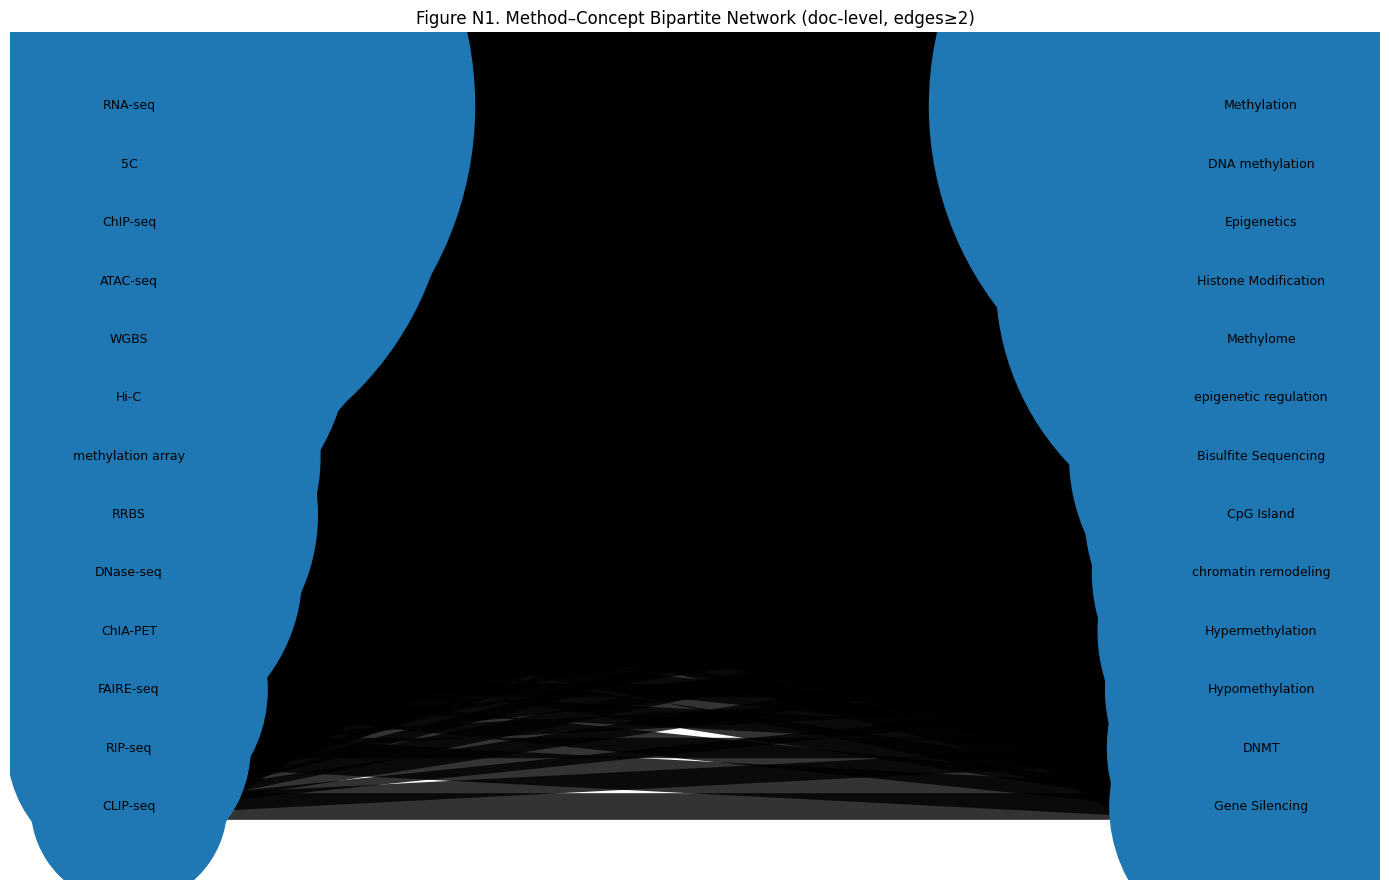


 Saved:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126/FigureN1_bipartite_network_doc_edgesge2.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126/FigureN1_bipartite_network_doc_edgesge2.pdf


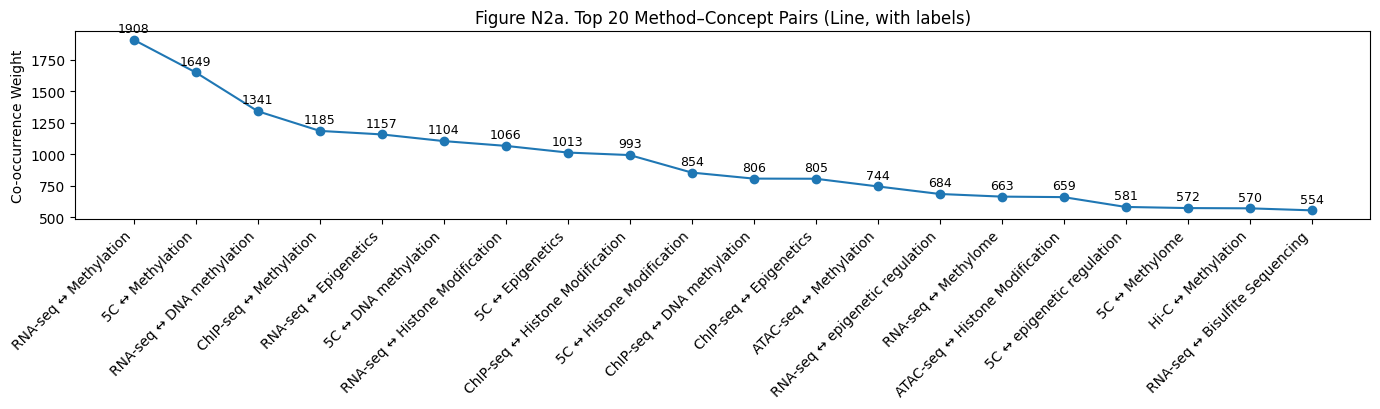

 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126/FigureN2a_top20_pairs_line_with_labels_doc.png
 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126/FigureN2a_top20_pairs_line_with_labels_doc.pdf


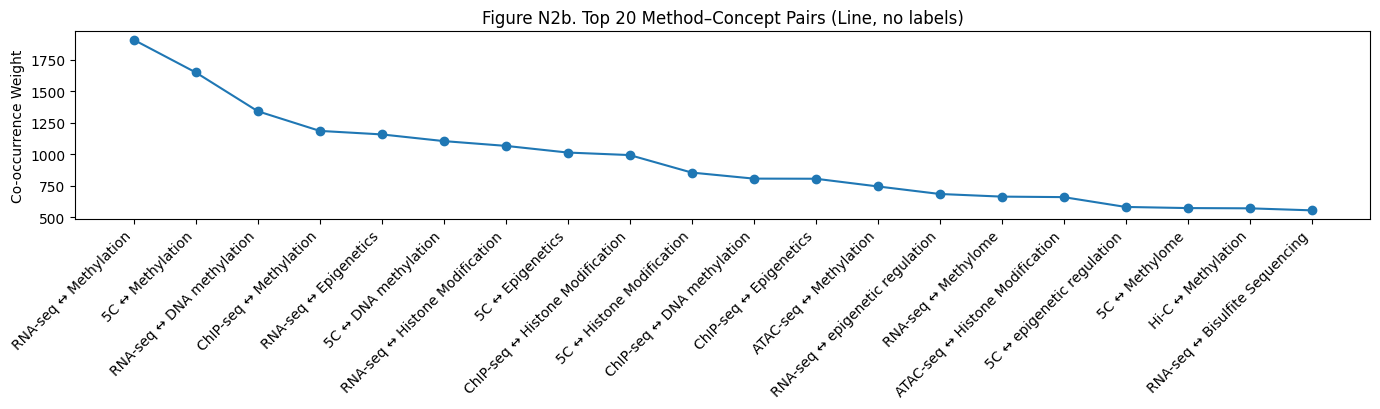

 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126/FigureN2b_top20_pairs_line_no_labels_doc.png
 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126/FigureN2b_top20_pairs_line_no_labels_doc.pdf


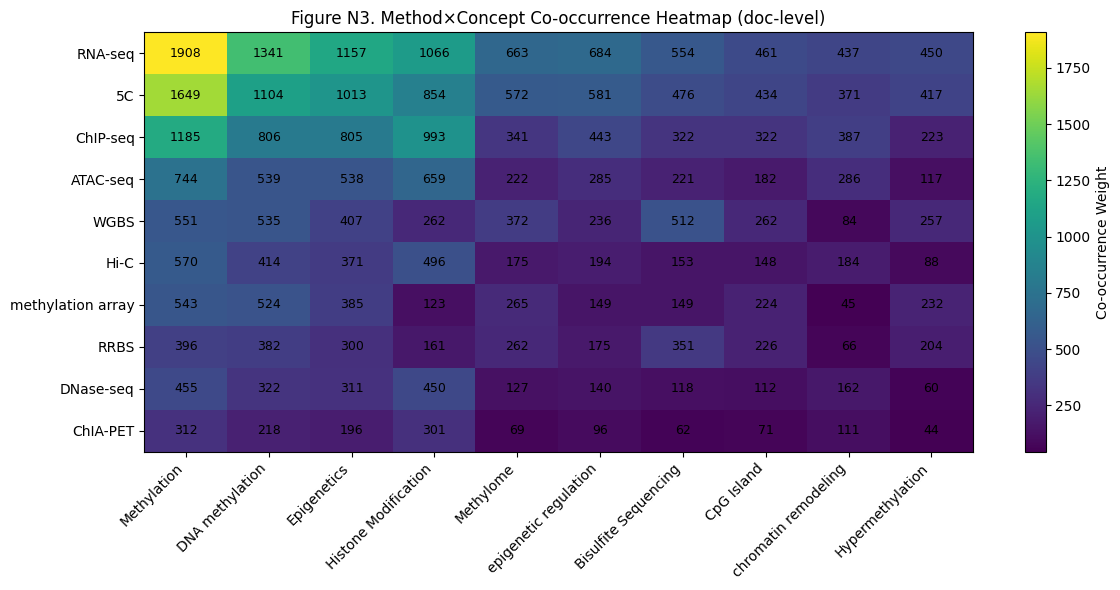

 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126/FigureN3_heatmap_method_concept_top10x10_doc.png
 Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126/FigureN3_heatmap_method_concept_top10x10_doc.pdf

 DONE. Output folder:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126


In [ ]:
# =========================================
# Colab: Method–Concept Network Analysis (Bipartite)
# - Full-text .txt corpus (your Drive folder)
# - Method nodes: epigenomics assay keywords
# - Concept nodes: methylation/epigenetic concept keywords
# - Edge weight:
#   (A) DOC-level co-occurrence  (fast, robust)
#   (B) SENT-level co-occurrence (more meaningful; slower)
# - Outputs:
#   (1) Edge list CSV (method, concept, weight)
#   (2) Node stats CSV (node, type, degree/strength)
#   (3) Table N1: Top co-occurrence pairs (Top 10) CSV
#   (4) Figure N1: bipartite network PNG(600dpi) + PDF(vector)
#   (5) Figure N2a: Top pairs line plot (with labels)
#   (6) Figure N2b: Top pairs line plot (no labels)
#   (Optional) Figure N3: Method×Concept heatmap with cell values (paper-friendly)
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import re
import math
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# =========================
# 1) PATHS
# =========================
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR    = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) KEYWORDS
# =========================
method_keywords = [
    "5C", "ChIA-PET", "Hi-C", "DNase-seq", "FAIRE-seq", "ATAC-seq", "ChIP-seq",
    "WGBS", "RRBS", "methylation array",
    "RNA-seq", "CLIP-seq", "RIP-seq"
]

concept_keywords = [
    "DNA methylation",
    "Methylation",
    "CpG Island",
    "Hypermethylation",
    "Hypomethylation",
    "Epigenetics",
    "Histone Modification",
    "Gene Silencing",
    "DNMT",
    "Methylome",
    "Bisulfite Sequencing",
    "chromatin remodeling",
    "epigenetic regulation"
]

# =========================
# 3) SETTINGS
# =========================
COOC_MODE = "doc"   # "doc" or "sent"
PROGRESS_EVERY = 200

# sentence splitting safety
MAX_SENTENCES_PER_DOC = 2000

# visualization controls
PLOT_EDGE_MIN_WEIGHT = 2
TOP_PAIRS_FOR_TABLE  = 10
TOP_PAIRS_FOR_PLOT   = 20

# heatmap controls (optional)
MAKE_HEATMAP = True
HEATMAP_TOP_METHODS  = 10
HEATMAP_TOP_CONCEPTS = 10

RANDOM_SEED = 42

# =========================
# 4) HELPERS
# =========================
def normalize_text(t: str) -> str:
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

def load_txt_files(folder_path: str):
    files = []
    for fn in sorted(os.listdir(folder_path)):
        if fn.lower().endswith(".txt"):
            fp = os.path.join(folder_path, fn)
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                files.append((fn, f.read()))
    return files

def split_sentences(text_lower: str):
    # simple splitter (fast/robust)
    return re.split(r"(?<=[.!?])\s+", text_lower)

def find_hits(text_lower: str, kws):
    hits = []
    for k in kws:
        if k.lower() in text_lower:
            hits.append(k)
    return sorted(set(hits))

# =========================
# 5) LOAD CORPUS
# =========================
docs = load_txt_files(CORPUS_DIR)
total_docs = len(docs)
print(" Found .txt files:", total_docs)

# =========================
# 6) BUILD CO-OCCURRENCE EDGES
# =========================
edge_w = defaultdict(int)     # (method, concept) -> weight
method_docfreq = Counter()    # method -> #docs (or #sents) where appears with any concept
concept_docfreq = Counter()   # concept -> #docs (or #sents) where appears with any method

used_units = 0   # docs used (doc mode) or sentences used (sent mode)
matched_docs = 0

for i, (fn, raw) in enumerate(docs, 1):
    text = normalize_text(raw)

    if COOC_MODE == "doc":
        m_hits = find_hits(text, method_keywords)
        c_hits = find_hits(text, concept_keywords)

        if not m_hits or not c_hits:
            if i % PROGRESS_EVERY == 0 or i == 1 or i == total_docs:
                print(f"Processed {i}/{total_docs} docs... matched_docs={matched_docs} used_units={used_units}")
            continue

        matched_docs += 1
        used_units += 1

        # doc-level edges
        for m in m_hits:
            for c in c_hits:
                edge_w[(m, c)] += 1

        for m in m_hits:
            method_docfreq[m] += 1
        for c in c_hits:
            concept_docfreq[c] += 1

    elif COOC_MODE == "sent":
        sents = split_sentences(text)
        if len(sents) > MAX_SENTENCES_PER_DOC:
            sents = sents[:MAX_SENTENCES_PER_DOC]

        doc_has_edge = False

        for sent in sents:
            m_hits = find_hits(sent, method_keywords)
            c_hits = find_hits(sent, concept_keywords)
            if not m_hits or not c_hits:
                continue

            doc_has_edge = True
            used_units += 1

            for m in m_hits:
                for c in c_hits:
                    edge_w[(m, c)] += 1

            for m in m_hits:
                method_docfreq[m] += 1
            for c in c_hits:
                concept_docfreq[c] += 1

        if doc_has_edge:
            matched_docs += 1

    else:
        raise ValueError("COOC_MODE must be 'doc' or 'sent'")

    if i % PROGRESS_EVERY == 0 or i == 1 or i == total_docs:
        print(f"Processed {i}/{total_docs} docs... matched_docs={matched_docs} used_units={used_units}")

print("\n DONE co-occurrence")
print(" - COOC_MODE:", COOC_MODE)
print(" - matched_docs:", matched_docs)
print(" - used_units (docs or sentences):", used_units)
print(" - unique edges:", len(edge_w))

# =========================
# 7) SAVE EDGE LIST + TOP PAIRS (Table N1)
# =========================
edges_df = pd.DataFrame(
    [{"method": m, "concept": c, "weight": w} for (m, c), w in edge_w.items()]
).sort_values("weight", ascending=False)

edges_path = os.path.join(OUT_DIR, f"method_concept_edges_{COOC_MODE}.csv")
edges_df.to_csv(edges_path, index=False, encoding="utf-8-sig")

top_pairs_df = edges_df.head(TOP_PAIRS_FOR_TABLE).copy()
top_pairs_path = os.path.join(OUT_DIR, f"Table_N1_top{TOP_PAIRS_FOR_TABLE}_pairs_{COOC_MODE}.csv")
top_pairs_df.to_csv(top_pairs_path, index=False, encoding="utf-8-sig")

print("\n Saved:")
print(" -", edges_path)
print(" -", top_pairs_path)

# =========================
# 8) BUILD BIPARTITE GRAPH (NetworkX)
# =========================
B = nx.Graph()

# add nodes
for m in method_keywords:
    B.add_node(m, bipartite="METHOD", freq=int(method_docfreq.get(m, 0)))

for c in concept_keywords:
    B.add_node(c, bipartite="CONCEPT", freq=int(concept_docfreq.get(c, 0)))

# add edges (filtered by PLOT_EDGE_MIN_WEIGHT for readability in the plot)
for (m, c), w in edge_w.items():
    B.add_edge(m, c, weight=int(w))

# node strength (sum of weights)
strength = {}
for n in B.nodes():
    strength[n] = sum(d.get("weight", 1) for _, _, d in B.edges(n, data=True))

nodes_df = pd.DataFrame({
    "node": list(B.nodes()),
    "type": [B.nodes[n].get("bipartite") for n in B.nodes()],
    "freq_units": [B.nodes[n].get("freq", 0) for n in B.nodes()],
    "weighted_degree_strength": [strength.get(n, 0) for n in B.nodes()],
}).sort_values(["type", "weighted_degree_strength"], ascending=[True, False])

nodes_path = os.path.join(OUT_DIR, f"method_concept_nodes_stats_{COOC_MODE}.csv")
nodes_df.to_csv(nodes_path, index=False, encoding="utf-8-sig")
print(" Saved:", nodes_path)

# =========================
# 9) FIGURE N1: Bipartite Network (paper-ready)
# =========================
# choose nodes to plot: keep only nodes with at least one edge >= threshold
plot_edges = [(m, c, d) for m, c, d in B.edges(data=True) if d.get("weight", 0) >= PLOT_EDGE_MIN_WEIGHT]
H = nx.Graph()
H.add_nodes_from(B.nodes(data=True))
H.add_edges_from(plot_edges)

# prune isolated nodes for plot
isolates = [n for n in H.nodes() if H.degree(n) == 0]
H.remove_nodes_from(isolates)

methods = [n for n in H.nodes() if H.nodes[n].get("bipartite") == "METHOD"]
concepts = [n for n in H.nodes() if H.nodes[n].get("bipartite") == "CONCEPT"]

# layout: two columns (cleaner than spring for bipartite)
pos = {}
# y positions by strength rank
m_sorted = sorted(methods, key=lambda x: strength.get(x, 0), reverse=True)
c_sorted = sorted(concepts, key=lambda x: strength.get(x, 0), reverse=True)

for idx, n in enumerate(m_sorted):
    pos[n] = (0.0, -idx)
for idx, n in enumerate(c_sorted):
    pos[n] = (1.0, -idx)

# node sizes scaled by strength (cap min)
node_sizes = [max(80, strength.get(n, 0) * 25) for n in H.nodes()]
edge_widths = [max(0.5, d.get("weight", 1) * 0.3) for _, _, d in H.edges(data=True)]

plt.figure(figsize=(14, 9))
nx.draw_networkx_nodes(H, pos, node_size=node_sizes)
nx.draw_networkx_edges(H, pos, width=edge_widths, alpha=0.8)
nx.draw_networkx_labels(H, pos, font_size=9)

plt.title(f"Figure N1. Method–Concept Bipartite Network ({COOC_MODE}-level, edges≥{PLOT_EDGE_MIN_WEIGHT})")
plt.axis("off")
plt.tight_layout()

fig_n1_png = os.path.join(OUT_DIR, f"FigureN1_bipartite_network_{COOC_MODE}_edgesge{PLOT_EDGE_MIN_WEIGHT}.png")
fig_n1_pdf = os.path.join(OUT_DIR, f"FigureN1_bipartite_network_{COOC_MODE}_edgesge{PLOT_EDGE_MIN_WEIGHT}.pdf")
plt.savefig(fig_n1_png, dpi=600)
plt.savefig(fig_n1_pdf)
plt.show()

print("\n Saved:")
print(" -", fig_n1_png)
print(" -", fig_n1_pdf)

# =========================
# 10) FIGURE N2: Top pairs (LINE) — with labels
# =========================
top_plot = edges_df.head(TOP_PAIRS_FOR_PLOT).copy()
top_plot["pair"] = top_plot["method"] + " ↔ " + top_plot["concept"]
x = list(range(len(top_plot)))
y = top_plot["weight"].tolist()

plt.figure(figsize=(14, 4.2))
plt.plot(x, y, marker="o")
plt.xticks(x, top_plot["pair"].tolist(), rotation=45, ha="right")
plt.ylabel("Co-occurrence Weight")
plt.title(f"Figure N2a. Top {TOP_PAIRS_FOR_PLOT} Method–Concept Pairs (Line, with labels)")

for xi, yi in zip(x, y):
    plt.text(xi, yi + (max(y)*0.02 if max(y) > 0 else 0.02), f"{yi}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
fig_n2a_png = os.path.join(OUT_DIR, f"FigureN2a_top{TOP_PAIRS_FOR_PLOT}_pairs_line_with_labels_{COOC_MODE}.png")
fig_n2a_pdf = os.path.join(OUT_DIR, f"FigureN2a_top{TOP_PAIRS_FOR_PLOT}_pairs_line_with_labels_{COOC_MODE}.pdf")
plt.savefig(fig_n2a_png, dpi=600)
plt.savefig(fig_n2a_pdf)
plt.show()

print(" Saved:", fig_n2a_png)
print(" Saved:", fig_n2a_pdf)

# =========================
# 11) FIGURE N2: Top pairs (LINE) — no labels
# =========================
plt.figure(figsize=(14, 4.2))
plt.plot(x, y, marker="o")
plt.xticks(x, top_plot["pair"].tolist(), rotation=45, ha="right")
plt.ylabel("Co-occurrence Weight")
plt.title(f"Figure N2b. Top {TOP_PAIRS_FOR_PLOT} Method–Concept Pairs (Line, no labels)")
plt.tight_layout()

fig_n2b_png = os.path.join(OUT_DIR, f"FigureN2b_top{TOP_PAIRS_FOR_PLOT}_pairs_line_no_labels_{COOC_MODE}.png")
fig_n2b_pdf = os.path.join(OUT_DIR, f"FigureN2b_top{TOP_PAIRS_FOR_PLOT}_pairs_line_no_labels_{COOC_MODE}.pdf")
plt.savefig(fig_n2b_png, dpi=600)
plt.savefig(fig_n2b_pdf)
plt.show()

print(" Saved:", fig_n2b_png)
print(" Saved:", fig_n2b_pdf)

# =========================
# 12) (OPTIONAL) FIGURE N3: Method×Concept heatmap + cell values
# =========================
if MAKE_HEATMAP and len(edges_df) > 0:
    top_m = edges_df.groupby("method")["weight"].sum().sort_values(ascending=False).head(HEATMAP_TOP_METHODS).index.tolist()
    top_c = edges_df.groupby("concept")["weight"].sum().sort_values(ascending=False).head(HEATMAP_TOP_CONCEPTS).index.tolist()

    mat = []
    for m in top_m:
        row = []
        for c in top_c:
            row.append(int(edge_w.get((m, c), 0)))
        mat.append(row)

    plt.figure(figsize=(12, 6))
    im = plt.imshow(mat, aspect="auto")
    plt.xticks(range(len(top_c)), top_c, rotation=45, ha="right")
    plt.yticks(range(len(top_m)), top_m)
    plt.colorbar(im, label="Co-occurrence Weight")
    plt.title(f"Figure N3. Method×Concept Co-occurrence Heatmap ({COOC_MODE}-level)")

    # cell values
    for i_r in range(len(top_m)):
        for j_c in range(len(top_c)):
            plt.text(j_c, i_r, str(mat[i_r][j_c]), ha="center", va="center", fontsize=9)

    plt.tight_layout()
    fig_n3_png = os.path.join(OUT_DIR, f"FigureN3_heatmap_method_concept_top{HEATMAP_TOP_METHODS}x{HEATMAP_TOP_CONCEPTS}_{COOC_MODE}.png")
    fig_n3_pdf = os.path.join(OUT_DIR, f"FigureN3_heatmap_method_concept_top{HEATMAP_TOP_METHODS}x{HEATMAP_TOP_CONCEPTS}_{COOC_MODE}.pdf")
    plt.savefig(fig_n3_png, dpi=600)
    plt.savefig(fig_n3_pdf)
    plt.show()

    print(" Saved:", fig_n3_png)
    print(" Saved:", fig_n3_pdf)

print("\n DONE. Output folder:")
print(" -", OUT_DIR)

Mounted at /content/drive
Found documents: 6152
Processed 1/6152 docs...
Processed 200/6152 docs...
Processed 400/6152 docs...
Processed 600/6152 docs...
Processed 800/6152 docs...
Processed 1000/6152 docs...
Processed 1200/6152 docs...
Processed 1400/6152 docs...
Processed 1600/6152 docs...
Processed 1800/6152 docs...
Processed 2000/6152 docs...
Processed 2200/6152 docs...
Processed 2400/6152 docs...
Processed 2600/6152 docs...
Processed 2800/6152 docs...
Processed 3000/6152 docs...
Processed 3200/6152 docs...
Processed 3400/6152 docs...
Processed 3600/6152 docs...
Processed 3800/6152 docs...
Processed 4000/6152 docs...
Processed 4200/6152 docs...
Processed 4400/6152 docs...
Processed 4600/6152 docs...
Processed 4800/6152 docs...
Processed 5000/6152 docs...
Processed 5200/6152 docs...
Processed 5400/6152 docs...
Processed 5600/6152 docs...
Processed 5800/6152 docs...
Processed 6000/6152 docs...
Processed 6152/6152 docs...
Done co-occurrence counting.
Unique edges: 195
Saved tables:
 -

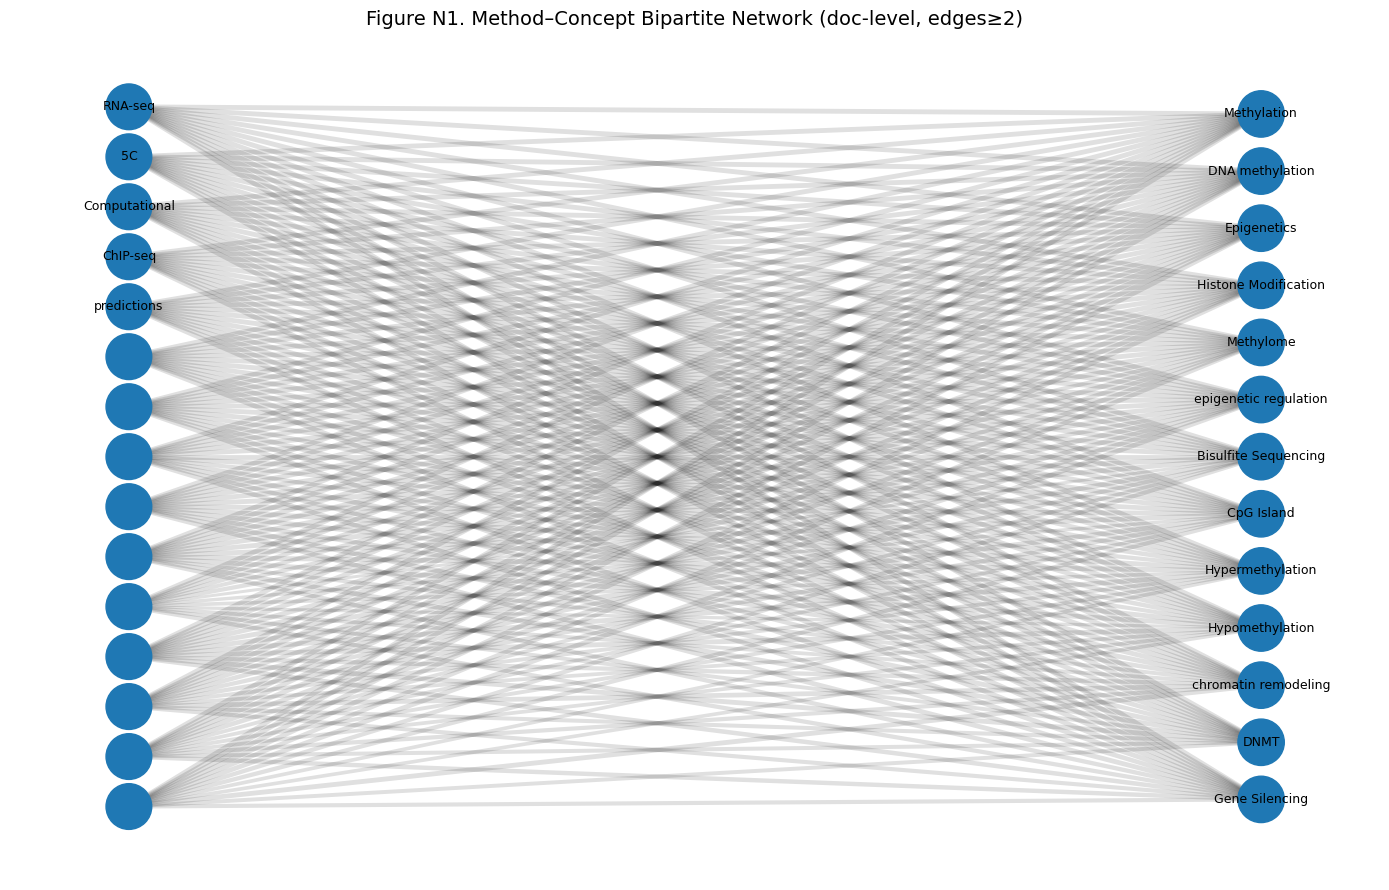

Saved figure:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_add/FigureN1_method_concept_bipartite_clean_doc_labels.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_add/FigureN1_method_concept_bipartite_clean_doc_labels.pdf


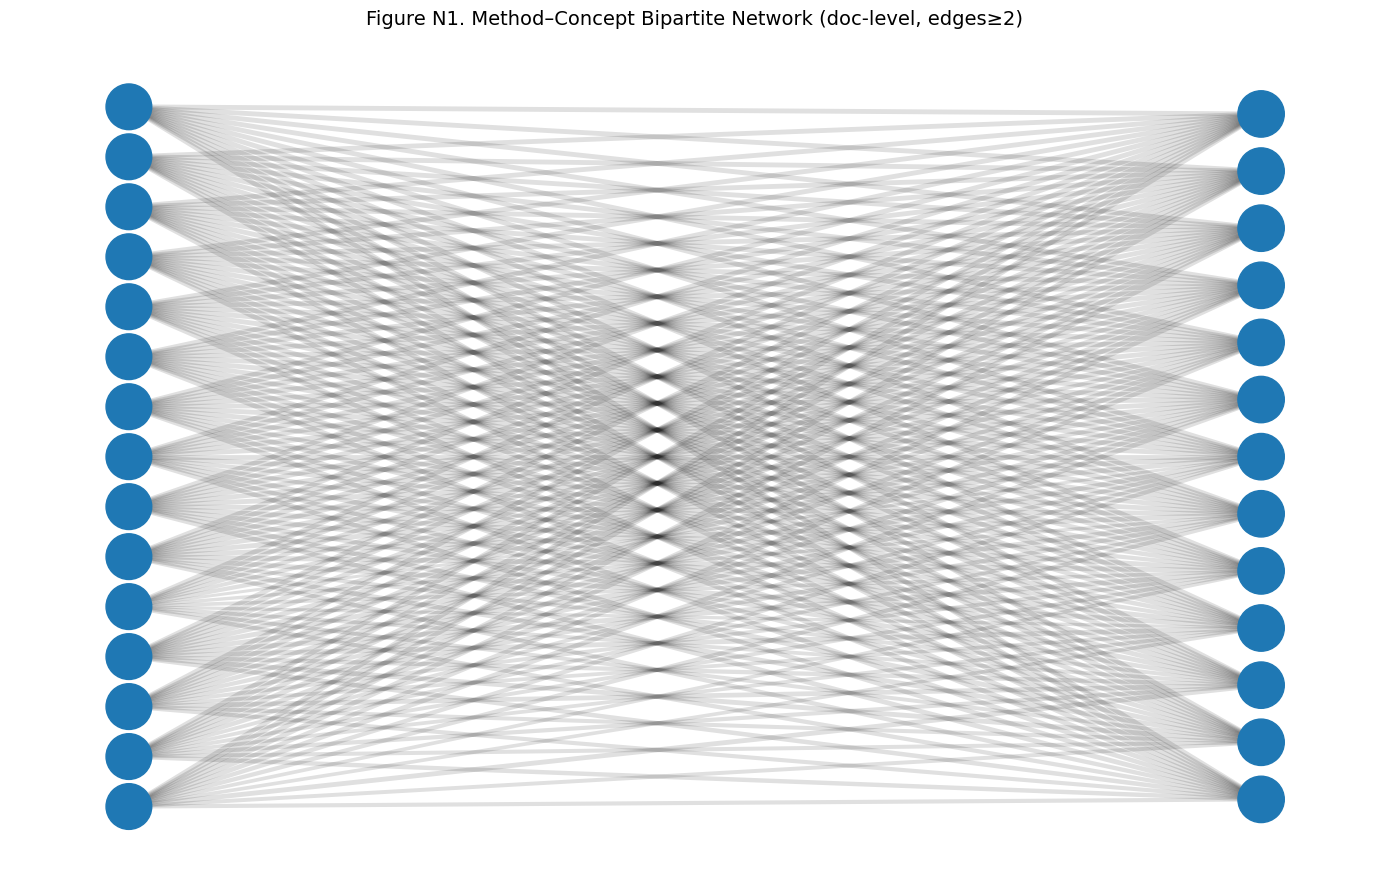

Saved figure:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_add/FigureN1_method_concept_bipartite_clean_doc_nolabels.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_add/FigureN1_method_concept_bipartite_clean_doc_nolabels.pdf

DONE. Output folder:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_add


In [ ]:
# =========================================
# Colab: Method–Concept Network Analysis (Bipartite, paper-ready)
# - Full-text .txt corpus
# - Method keywords × Concept keywords co-occurrence
# - COOC_MODE: 'doc' (fast) or 'sent' (more strict, slower)
# - Saves:
#   (1) edges table (method–concept co-occurrence)
#   (2) top pairs table (Top K)
#   (3) figure N1 (clean bipartite network) PNG 600dpi + PDF
#   (4) optional: labeled-only-top-nodes version
# - Includes "paper styling tips" options inside code
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import re
import math
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# =========================
# 1) PATHS
# =========================
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR   = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_add"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) KEYWORDS (your research sets)
# =========================
method_keywords = [
    "5C", "ChIA-PET", "Hi-C", "DNase-seq", "FAIRE-seq", "ATAC-seq", "ChIP-seq",
    "WGBS", "RRBS", "methylation array",
    "RNA-seq", "CLIP-seq", "RIP-seq",
    "Computational", "predictions"
]

concept_keywords = [
    "DNA methylation", "Methylation", "CpG Island", "Hypermethylation", "Hypomethylation",
    "Epigenetics", "Histone Modification", "Gene Silencing", "DNMT",
    "Methylome", "Bisulfite Sequencing", "chromatin remodeling", "epigenetic regulation"
]

# =========================
# 3) SETTINGS
# =========================
COOC_MODE = "doc"          # "doc" or "sent"
EDGE_MIN_WEIGHT = 2        # keep edges >= this weight in outputs (and plotting)
TOP_PAIRS_K = 30           # table size

PROGRESS_EVERY = 200

# Paper-ready plotting controls
PLOT_TOP_METHODS = 15      # keep most frequent methods for figure
PLOT_TOP_CONCEPTS = 15     # keep most frequent concepts for figure
PLOT_TOP_EDGES = 250       # keep top-weight edges for figure (None for all)

# Label controls (paper tip)
LABEL_MODE = "top"         # "all" or "top"
LABEL_TOP_N = 18           # if LABEL_MODE="top", only label top-N nodes by degree

# Save two figures: with labels + without labels
SAVE_FIG_WITH_LABELS = True
SAVE_FIG_NO_LABELS = True

# =========================
# 4) HELPERS
# =========================
def normalize_text(t: str) -> str:
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

def split_sentences(text: str):
    return re.split(r"(?<=[.!?])\s+", text)

def load_txt_files_from_folder(folder_path: str):
    files = []
    for fn in sorted(os.listdir(folder_path)):
        if fn.lower().endswith(".txt"):
            fp = os.path.join(folder_path, fn)
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                files.append((fn, f.read()))
    return files

def find_hits(text_lower: str, terms):
    hits = []
    for t in terms:
        if t.lower() in text_lower:
            hits.append(t)
    return sorted(set(hits))

def bipartite_positions(left_nodes, right_nodes, x_left=0.05, x_right=0.95):
    pos = {}
    left_nodes = list(left_nodes)
    right_nodes = list(right_nodes)

    for i, n in enumerate(left_nodes):
        y = 1 - (i + 1) / (len(left_nodes) + 1)
        pos[n] = (x_left, y)

    for i, n in enumerate(right_nodes):
        y = 1 - (i + 1) / (len(right_nodes) + 1)
        pos[n] = (x_right, y)

    return pos

# =========================
# 5) LOAD CORPUS
# =========================
docs = load_txt_files_from_folder(CORPUS_DIR)
total_docs = len(docs)
print("Found documents:", total_docs)

# =========================
# 6) CO-OCCURRENCE COUNT
# =========================
edge_w = defaultdict(int)
method_doc_freq = defaultdict(int)
concept_doc_freq = defaultdict(int)

for i, (filename, text) in enumerate(docs, 1):
    t = normalize_text(text)

    if COOC_MODE == "doc":
        mhits = find_hits(t, method_keywords)
        chits = find_hits(t, concept_keywords)

        # doc-level freq (for selecting top nodes)
        for m in mhits: method_doc_freq[m] += 1
        for c in chits: concept_doc_freq[c] += 1

        for m in mhits:
            for c in chits:
                edge_w[(m, c)] += 1

    elif COOC_MODE == "sent":
        sents = split_sentences(t)
        seen_m = set()
        seen_c = set()

        for sent in sents:
            mhits = find_hits(sent, method_keywords)
            chits = find_hits(sent, concept_keywords)

            for m in mhits: seen_m.add(m)
            for c in chits: seen_c.add(c)

            for m in mhits:
                for c in chits:
                    edge_w[(m, c)] += 1

        for m in seen_m: method_doc_freq[m] += 1
        for c in seen_c: concept_doc_freq[c] += 1

    else:
        raise ValueError("COOC_MODE must be 'doc' or 'sent'")

    if i % PROGRESS_EVERY == 0 or i == 1 or i == total_docs:
        print(f"Processed {i}/{total_docs} docs...")

print("Done co-occurrence counting.")
print("Unique edges:", len(edge_w))

# =========================
# 7) BUILD EDGES TABLE + SAVE
# =========================
edges_df = pd.DataFrame(
    [{"method": m, "concept": c, "cooc_count": w} for (m, c), w in edge_w.items()]
).sort_values("cooc_count", ascending=False)

# keep only >= threshold for main output
edges_df_filt = edges_df[edges_df["cooc_count"] >= EDGE_MIN_WEIGHT].copy()

edges_path = os.path.join(OUT_DIR, f"method_concept_edges_{COOC_MODE}_edgesge{EDGE_MIN_WEIGHT}.csv")
edges_df_filt.to_csv(edges_path, index=False, encoding="utf-8-sig")

top_pairs_df = edges_df_filt.head(TOP_PAIRS_K).copy()
top_pairs_path = os.path.join(OUT_DIR, f"TableN1_top_pairs_TOP{TOP_PAIRS_K}_{COOC_MODE}.csv")
top_pairs_df.to_csv(top_pairs_path, index=False, encoding="utf-8-sig")

print("Saved tables:")
print(" -", edges_path)
print(" -", top_pairs_path)

# =========================
# 8) SELECT NODES FOR FIGURE (paper tip)
#    - 너무 많이 그리면 지저분 → 상위만 선택
# =========================
methods_top = sorted(method_doc_freq.items(), key=lambda x: x[1], reverse=True)[:PLOT_TOP_METHODS]
concepts_top = sorted(concept_doc_freq.items(), key=lambda x: x[1], reverse=True)[:PLOT_TOP_CONCEPTS]
methods_keep = [m for m, _ in methods_top]
concepts_keep = [c for c, _ in concepts_top]

# =========================
# 9) BUILD BIPARTITE GRAPH
# =========================
B = nx.Graph()

# add nodes with bipartite attribute
for m in methods_keep:
    B.add_node(m, bipartite=0, doc_freq=method_doc_freq.get(m, 0))
for c in concepts_keep:
    B.add_node(c, bipartite=1, doc_freq=concept_doc_freq.get(c, 0))

# add edges (only among kept nodes, and >= EDGE_MIN_WEIGHT)
for _, r in edges_df_filt.iterrows():
    m, c, w = r["method"], r["concept"], int(r["cooc_count"])
    if (m in methods_keep) and (c in concepts_keep):
        B.add_edge(m, c, weight=w)

print("\nFigure subgraph:")
print(" - nodes:", B.number_of_nodes())
print(" - edges:", B.number_of_edges())

# Optional: keep only top-weight edges for readability (paper tip)
if PLOT_TOP_EDGES is not None and B.number_of_edges() > PLOT_TOP_EDGES:
    edges_sorted = sorted(B.edges(data=True), key=lambda x: x[2].get("weight", 1), reverse=True)
    keep = edges_sorted[:PLOT_TOP_EDGES]
    keep_set = {(u, v) for u, v, _ in keep}
    for (u, v) in list(B.edges()):
        if (u, v) not in keep_set and (v, u) not in keep_set:
            B.remove_edge(u, v)
    print(" - after top-edge filter:", B.number_of_edges())

# =========================
# 10) PAPER-READY DRAW FUNCTION
#     (fixes: oversized nodes + thick edges + black blob)
# =========================
def draw_bipartite_clean(G, out_prefix, with_labels=True):
    methods = [n for n, d in G.nodes(data=True) if d.get("bipartite") == 0]
    concepts = [n for n, d in G.nodes(data=True) if d.get("bipartite") == 1]
    pos = bipartite_positions(methods, concepts, x_left=0.08, x_right=0.92)

    # Node sizes (폭발 방지: sqrt + cap)
    deg = dict(G.degree())
    NODE_BASE = 650
    NODE_SCALE = 120
    node_sizes = []
    for n in G.nodes():
        s = NODE_BASE + NODE_SCALE * math.sqrt(max(1, deg.get(n, 1)))
        s = min(s, 2200)
        node_sizes.append(s)

    # Edge widths (log-scale + cap)
    EDGE_BASE = 0.35
    EDGE_SCALE = 0.65
    edge_widths = []
    for u, v, d in G.edges(data=True):
        w = d.get("weight", 1)
        ew = EDGE_BASE + EDGE_SCALE * math.log1p(w)
        edge_widths.append(min(ew, 3.5))

    EDGE_ALPHA = 0.12

    plt.figure(figsize=(14, 9))
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes)
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=EDGE_ALPHA)

    if with_labels:
        # 라벨 전략 (paper tip)
        if LABEL_MODE == "all":
            label_nodes = list(G.nodes())
        else:
            # degree 상위 N만 라벨
            deg_sorted = sorted(deg.items(), key=lambda x: x[1], reverse=True)
            label_nodes = [n for n, _ in deg_sorted[:LABEL_TOP_N]]

        labels = {n: n for n in label_nodes}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

    plt.title(f"Figure N1. Method–Concept Bipartite Network ({COOC_MODE}-level, edges≥{EDGE_MIN_WEIGHT})", fontsize=14)
    plt.axis("off")
    plt.tight_layout()

    fig_png = os.path.join(OUT_DIR, f"{out_prefix}.png")
    fig_pdf = os.path.join(OUT_DIR, f"{out_prefix}.pdf")
    plt.savefig(fig_png, dpi=600)
    plt.savefig(fig_pdf)
    plt.show()

    print("Saved figure:")
    print(" -", fig_png)
    print(" -", fig_pdf)

# =========================
# 11) DRAW: with labels / without labels (both)
# =========================
if SAVE_FIG_WITH_LABELS:
    draw_bipartite_clean(
        B,
        out_prefix=f"FigureN1_method_concept_bipartite_clean_{COOC_MODE}_labels"
    )

if SAVE_FIG_NO_LABELS:
    draw_bipartite_clean(
        B,
        out_prefix=f"FigureN1_method_concept_bipartite_clean_{COOC_MODE}_nolabels",
        with_labels=False
    )

print("\nDONE. Output folder:")
print(" -", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found documents: 6152
Processed 1/6152 docs...
Processed 200/6152 docs...
Processed 400/6152 docs...
Processed 600/6152 docs...
Processed 800/6152 docs...
Processed 1000/6152 docs...
Processed 1200/6152 docs...
Processed 1400/6152 docs...
Processed 1600/6152 docs...
Processed 1800/6152 docs...
Processed 2000/6152 docs...
Processed 2200/6152 docs...
Processed 2400/6152 docs...
Processed 2600/6152 docs...
Processed 2800/6152 docs...
Processed 3000/6152 docs...
Processed 3200/6152 docs...
Processed 3400/6152 docs...
Processed 3600/6152 docs...
Processed 3800/6152 docs...
Processed 4000/6152 docs...
Processed 4200/6152 docs...
Processed 4400/6152 docs...
Processed 4600/6152 docs...
Processed 4800/6152 docs...
Processed 5000/6152 docs...
Processed 5200/6152 docs...
Processed 5400/6152 docs...
Processed 5600/6152 docs...
Processed 5800/6152 docs...
Processed 6000/6

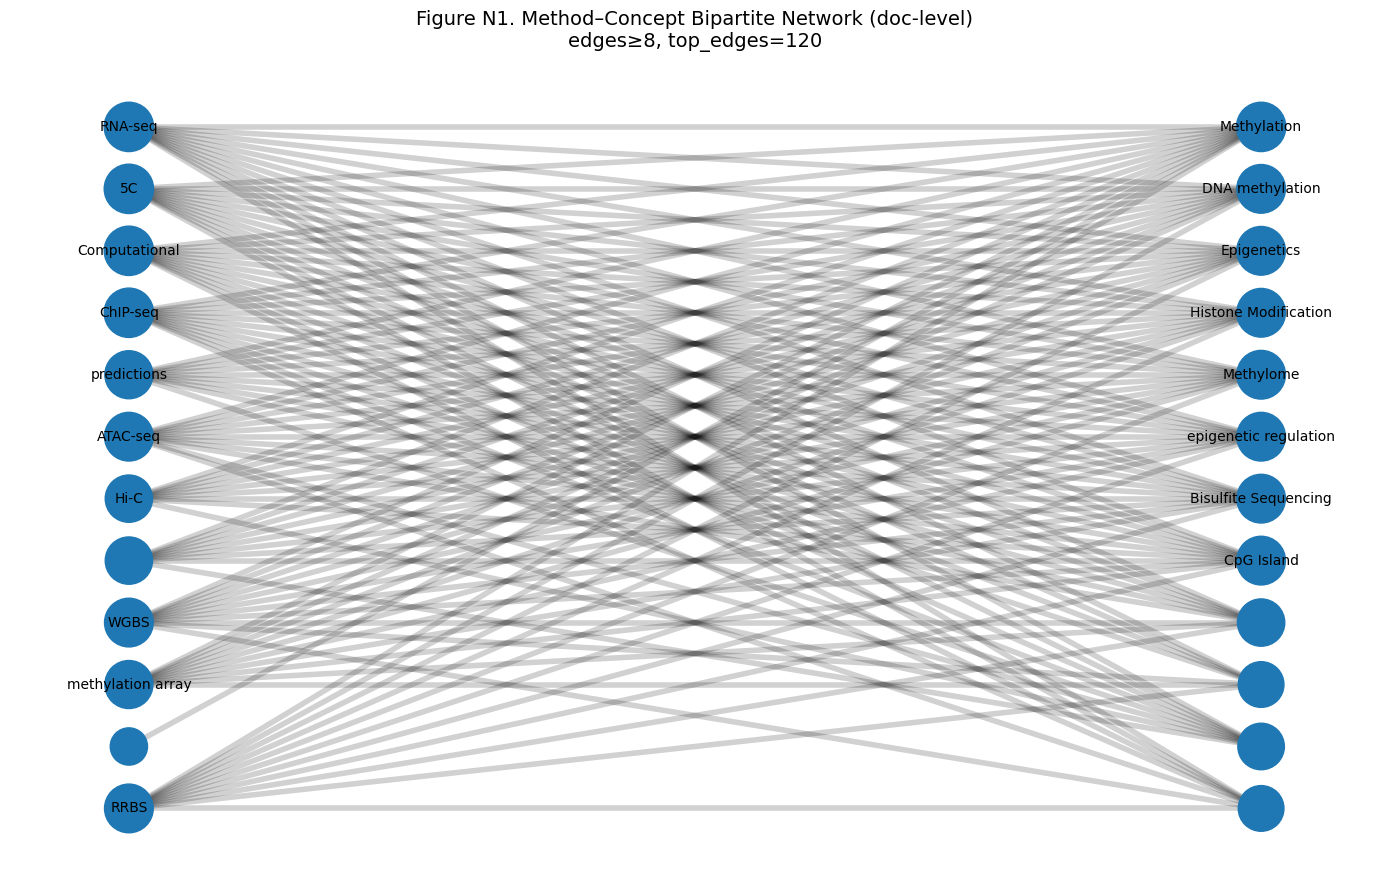

Saved figure:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_ad/FigureN1_method_concept_bipartite_clean_doc_labels.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_ad/FigureN1_method_concept_bipartite_clean_doc_labels.pdf


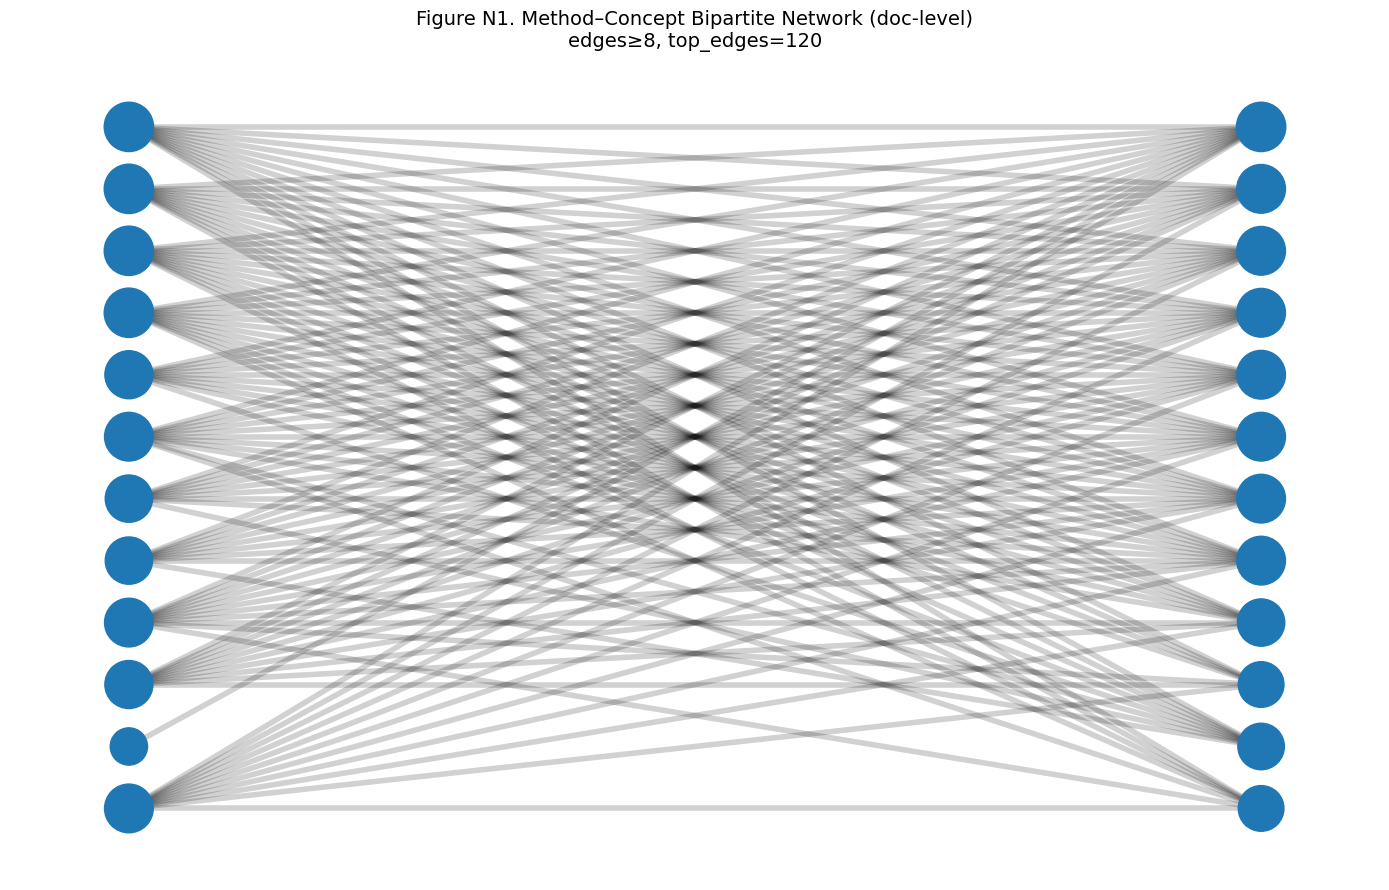

Saved figure:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_ad/FigureN1_method_concept_bipartite_clean_doc_nolabels.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_ad/FigureN1_method_concept_bipartite_clean_doc_nolabels.pdf

DONE. Output folder:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_ad


In [ ]:
# =========================================
# Colab: Method–Concept Network Analysis (Bipartite, paper-ready)
# - Full-text .txt corpus
# - Method keywords × Concept keywords co-occurrence
# - COOC_MODE: 'doc' (fast) or 'sent' (more strict, slower)
# - Saves: edges/table + clean bipartite figures (PNG 600dpi + PDF)
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import re
import math
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# =========================
# 1) PATHS
# =========================
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR   = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_ad"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) KEYWORDS (your research sets)
# =========================
method_keywords = [
    "5C", "ChIA-PET", "Hi-C", "DNase-seq", "FAIRE-seq", "ATAC-seq", "ChIP-seq",
    "WGBS", "RRBS", "methylation array",
    "RNA-seq", "CLIP-seq", "RIP-seq",
    "Computational", "predictions"
]

concept_keywords = [
    "DNA methylation", "Methylation", "CpG Island", "Hypermethylation", "Hypomethylation",
    "Epigenetics", "Histone Modification", "Gene Silencing", "DNMT",
    "Methylome", "Bisulfite Sequencing", "chromatin remodeling", "epigenetic regulation"
]

# =========================
# 3) SETTINGS
# =========================
COOC_MODE = "doc"           # "doc" or "sent"

# ---- 핵심(헤어볼 방지) ----
EDGE_MIN_WEIGHT = 8         # ★ 2는 너무 낮아서 거의 다 연결됨 → 6~15 정도 권장
PLOT_TOP_EDGES = 120        # ★ 그림에는 상위 엣지만 (표/CSV는 전체 저장 가능)
KEEP_ONLY_CONNECTED_NODES = True  # 엣지 끊긴 고립 노드 제거(그림 깔끔)

# ---- 표 저장 ----
TOP_PAIRS_K = 30

# ---- 진행률 ----
PROGRESS_EVERY = 200

# ---- 노드 선택(너무 많으면 여전히 지저분) ----
PLOT_TOP_METHODS = 12
PLOT_TOP_CONCEPTS = 12

# ---- 라벨(논문용) ----
LABEL_TOP_N = 18            # 상위 N개 노드만 라벨

# ---- 출력(라벨 버전/무라벨 버전 둘다) ----
SAVE_FIG_WITH_LABELS = True
SAVE_FIG_NO_LABELS = True

# =========================
# 4) HELPERS
# =========================
def normalize_text(t: str) -> str:
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

def split_sentences(text: str):
    return re.split(r"(?<=[.!?])\s+", text)

def load_txt_files_from_folder(folder_path: str):
    files = []
    for fn in sorted(os.listdir(folder_path)):
        if fn.lower().endswith(".txt"):
            fp = os.path.join(folder_path, fn)
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                files.append((fn, f.read()))
    return files

def find_hits(text_lower: str, terms):
    hits = []
    for t in terms:
        if t.lower() in text_lower:
            hits.append(t)
    return sorted(set(hits))

def bipartite_positions(left_nodes, right_nodes, x_left=0.08, x_right=0.92):
    pos = {}
    left_nodes = list(left_nodes)
    right_nodes = list(right_nodes)

    for i, n in enumerate(left_nodes):
        y = 1 - (i + 1) / (len(left_nodes) + 1)
        pos[n] = (x_left, y)

    for i, n in enumerate(right_nodes):
        y = 1 - (i + 1) / (len(right_nodes) + 1)
        pos[n] = (x_right, y)

    return pos

# =========================
# 5) LOAD CORPUS
# =========================
docs = load_txt_files_from_folder(CORPUS_DIR)
total_docs = len(docs)
print("Found documents:", total_docs)

# =========================
# 6) CO-OCCURRENCE COUNT
# =========================
edge_w = defaultdict(int)
method_doc_freq = defaultdict(int)
concept_doc_freq = defaultdict(int)

for i, (_, text) in enumerate(docs, 1):
    t = normalize_text(text)

    if COOC_MODE == "doc":
        mhits = find_hits(t, method_keywords)
        chits = find_hits(t, concept_keywords)

        for m in mhits: method_doc_freq[m] += 1
        for c in chits: concept_doc_freq[c] += 1

        for m in mhits:
            for c in chits:
                edge_w[(m, c)] += 1

    elif COOC_MODE == "sent":
        sents = split_sentences(t)
        seen_m = set()
        seen_c = set()

        for sent in sents:
            mhits = find_hits(sent, method_keywords)
            chits = find_hits(sent, concept_keywords)

            for m in mhits: seen_m.add(m)
            for c in chits: seen_c.add(c)

            for m in mhits:
                for c in chits:
                    edge_w[(m, c)] += 1

        for m in seen_m: method_doc_freq[m] += 1
        for c in seen_c: concept_doc_freq[c] += 1
    else:
        raise ValueError("COOC_MODE must be 'doc' or 'sent'")

    if i % PROGRESS_EVERY == 0 or i == 1 or i == total_docs:
        print(f"Processed {i}/{total_docs} docs...")

print("Done co-occurrence counting. Unique edges:", len(edge_w))

# =========================
# 7) EDGES TABLE + SAVE (전체는 저장)
# =========================
edges_df = pd.DataFrame(
    [{"method": m, "concept": c, "cooc_count": w} for (m, c), w in edge_w.items()]
).sort_values("cooc_count", ascending=False)

edges_all_path = os.path.join(OUT_DIR, f"method_concept_edges_ALL_{COOC_MODE}.csv")
edges_df.to_csv(edges_all_path, index=False, encoding="utf-8-sig")

# 그림용/분석용 필터
edges_df_filt = edges_df[edges_df["cooc_count"] >= EDGE_MIN_WEIGHT].copy()

edges_filt_path = os.path.join(OUT_DIR, f"method_concept_edges_{COOC_MODE}_edgesge{EDGE_MIN_WEIGHT}.csv")
edges_df_filt.to_csv(edges_filt_path, index=False, encoding="utf-8-sig")

top_pairs_df = edges_df_filt.head(TOP_PAIRS_K).copy()
top_pairs_path = os.path.join(OUT_DIR, f"TableN1_top_pairs_TOP{TOP_PAIRS_K}_{COOC_MODE}_edgesge{EDGE_MIN_WEIGHT}.csv")
top_pairs_df.to_csv(top_pairs_path, index=False, encoding="utf-8-sig")

print("Saved tables:")
print(" -", edges_all_path)
print(" -", edges_filt_path)
print(" -", top_pairs_path)

# =========================
# 8) SELECT NODES FOR FIGURE (doc_freq 기반 상위만)
# =========================
methods_keep = [m for m, _ in sorted(method_doc_freq.items(), key=lambda x: x[1], reverse=True)[:PLOT_TOP_METHODS]]
concepts_keep = [c for c, _ in sorted(concept_doc_freq.items(), key=lambda x: x[1], reverse=True)[:PLOT_TOP_CONCEPTS]]

# =========================
# 9) BUILD GRAPH (figure subgraph)
# =========================
B = nx.Graph()
for m in methods_keep:
    B.add_node(m, bipartite=0, doc_freq=method_doc_freq.get(m, 0))
for c in concepts_keep:
    B.add_node(c, bipartite=1, doc_freq=concept_doc_freq.get(c, 0))

# add edges from filtered table
for _, r in edges_df_filt.iterrows():
    m, c, w = r["method"], r["concept"], int(r["cooc_count"])
    if (m in methods_keep) and (c in concepts_keep):
        B.add_edge(m, c, weight=w)

# ---- 그림용: 상위 엣지만 남기기 (헤어볼 방지 핵심) ----
if PLOT_TOP_EDGES is not None and B.number_of_edges() > PLOT_TOP_EDGES:
    edges_sorted = sorted(B.edges(data=True), key=lambda x: x[2].get("weight", 1), reverse=True)
    keep = edges_sorted[:PLOT_TOP_EDGES]
    keep_set = {(u, v) for u, v, _ in keep}
    for (u, v) in list(B.edges()):
        if (u, v) not in keep_set and (v, u) not in keep_set:
            B.remove_edge(u, v)

# ---- 고립 노드 제거(깔끔) ----
if KEEP_ONLY_CONNECTED_NODES:
    isolates = list(nx.isolates(B))
    B.remove_nodes_from(isolates)

print("\nFigure subgraph after filtering:")
print(" - nodes:", B.number_of_nodes())
print(" - edges:", B.number_of_edges())

# =========================
# 10) DRAW (clean bipartite)
# =========================
def draw_bipartite_clean(G, out_prefix, with_labels=True):
    methods = [n for n, d in G.nodes(data=True) if d.get("bipartite") == 0]
    concepts = [n for n, d in G.nodes(data=True) if d.get("bipartite") == 1]
    pos = bipartite_positions(methods, concepts, x_left=0.08, x_right=0.92)

    deg = dict(G.degree())

    # node size: sqrt + cap (폭발 방지)
    NODE_BASE = 500
    NODE_SCALE = 220
    node_sizes = []
    for n in G.nodes():
        s = NODE_BASE + NODE_SCALE * math.sqrt(max(1, deg.get(n, 1)))
        node_sizes.append(min(s, 2200))

    # edge width: log + cap (헤어볼 완화)
    EDGE_BASE = 0.3
    EDGE_SCALE = 0.9
    edge_widths = []
    for _, _, d in G.edges(data=True):
        w = d.get("weight", 1)
        ew = EDGE_BASE + EDGE_SCALE * math.log1p(w)
        edge_widths.append(min(ew, 4.0))

    plt.figure(figsize=(14, 9))
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes)

    # alpha를 더 낮게 → 겹쳐도 검은 덩어리 덜 생김
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.18)

    if with_labels:
        # degree 상위 LABEL_TOP_N만 라벨
        deg_sorted = sorted(deg.items(), key=lambda x: x[1], reverse=True)
        label_nodes = [n for n, _ in deg_sorted[:LABEL_TOP_N]]
        labels = {n: n for n in label_nodes}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)

    plt.title(f"Figure N1. Method–Concept Bipartite Network ({COOC_MODE}-level)\n"
              f"edges≥{EDGE_MIN_WEIGHT}, top_edges={PLOT_TOP_EDGES}", fontsize=14)
    plt.axis("off")
    plt.tight_layout()

    fig_png = os.path.join(OUT_DIR, f"{out_prefix}.png")
    fig_pdf = os.path.join(OUT_DIR, f"{out_prefix}.pdf")
    plt.savefig(fig_png, dpi=600)
    plt.savefig(fig_pdf)
    plt.show()

    print("Saved figure:")
    print(" -", fig_png)
    print(" -", fig_pdf)

# =========================
# 11) EXPORT FIGURES
# =========================
if SAVE_FIG_WITH_LABELS:
    draw_bipartite_clean(
        B,
        out_prefix=f"FigureN1_method_concept_bipartite_clean_{COOC_MODE}_labels"
    )

if SAVE_FIG_NO_LABELS:
    draw_bipartite_clean(
        B,
        out_prefix=f"FigureN1_method_concept_bipartite_clean_{COOC_MODE}_nolabels",
        with_labels=False
    )

print("\nDONE. Output folder:")
print(" -", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded documents: 6152
Initial nodes: 26
Initial edges: 169
After cleaning nodes: 26
After cleaning edges: 169
Final nodes: 26
Final edges: 120


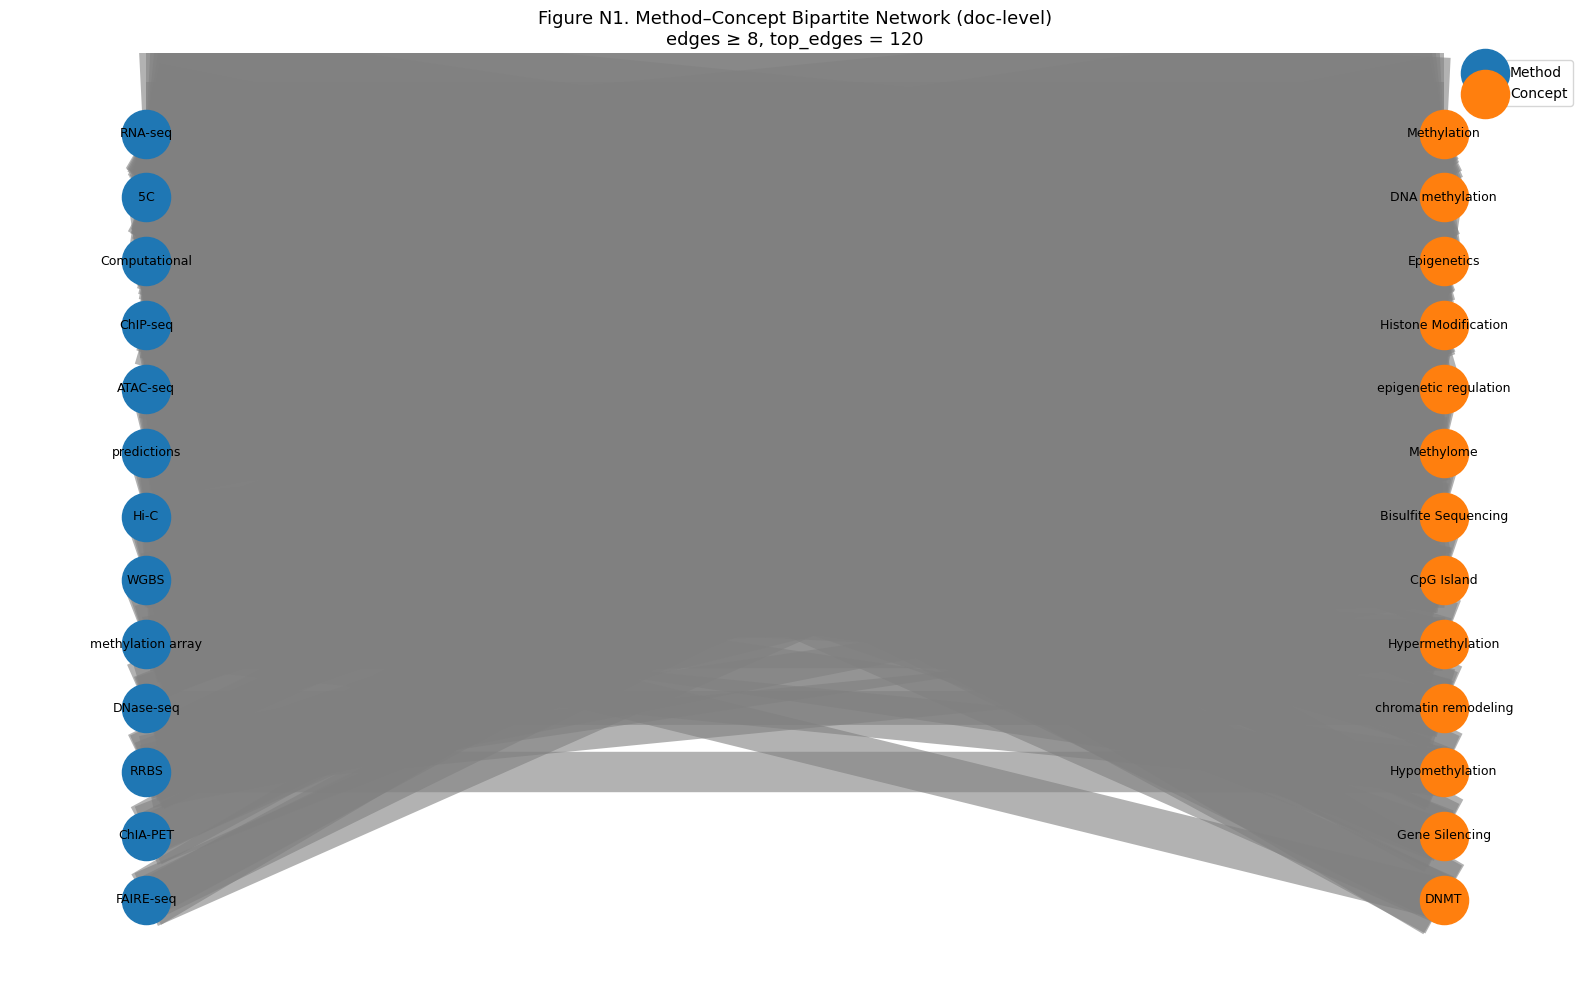

Saved:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_as/Figure_N1_Method_Concept_Bipartite.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_as/Figure_N1_Method_Concept_Bipartite.pdf


In [ ]:
# =========================================
# Figure N1. Method–Concept Bipartite Network (paper-ready)
# - Document-level co-occurrence
# - Removes isolated / weakly connected nodes
# - Keeps only strong edges
# - Clean bipartite layout for publication
# - Saves PNG (600dpi) + PDF
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict

# =========================
# 1) PATHS
# =========================
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_as"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) KEYWORDS
# =========================
method_keywords = [
    "RNA-seq", "ChIP-seq", "ATAC-seq", "Hi-C", "WGBS",
    "RRBS", "DNase-seq", "ChIA-PET", "FAIRE-seq",
    "methylation array", "5C", "Computational", "predictions"
]

concept_keywords = [
    "DNA methylation", "Methylation", "Epigenetics",
    "Histone Modification", "Methylome",
    "epigenetic regulation", "Bisulfite Sequencing",
    "CpG Island", "Hypermethylation",
    "Hypomethylation", "DNMT", "Gene Silencing",
    "chromatin remodeling"
]

# =========================
# 3) PARAMETERS
# =========================
EDGE_MIN_WEIGHT = 8          # 강한 관계만
TOP_EDGES_TO_PLOT = 120      # 엣지 수 제한
REMOVE_LOW_DEGREE = True     # degree ≤1 노드 제거
FIGSIZE = (16, 10)
NODE_SIZE = 1200

# =========================
# 4) LOAD DOCUMENTS
# =========================
def load_docs(folder):
    docs = []
    for fn in sorted(os.listdir(folder)):
        if fn.lower().endswith(".txt"):
            with open(os.path.join(folder, fn),
                      "r", encoding="utf-8", errors="ignore") as f:
                docs.append(f.read().lower())
    return docs

docs = load_docs(CORPUS_DIR)
print("Loaded documents:", len(docs))

# =========================
# 5) DOC-LEVEL CO-OCCURRENCE
# =========================
edge_counter = defaultdict(int)

for text in docs:
    methods_in_doc = [m for m in method_keywords if m.lower() in text]
    concepts_in_doc = [c for c in concept_keywords if c.lower() in text]

    for m in methods_in_doc:
        for c in concepts_in_doc:
            edge_counter[(m, c)] += 1

# =========================
# 6) BUILD BIPARTITE GRAPH
# =========================
B = nx.Graph()

for (m, c), w in edge_counter.items():
    if w >= EDGE_MIN_WEIGHT:
        B.add_node(m, bipartite=0, kind="METHOD")
        B.add_node(c, bipartite=1, kind="CONCEPT")
        B.add_edge(m, c, weight=w)

print("Initial nodes:", B.number_of_nodes())
print("Initial edges:", B.number_of_edges())

# =========================
# 7) CLEAN GRAPH (중요)
# =========================
# 7-1) 고립 노드 제거
isolates = list(nx.isolates(B))
B.remove_nodes_from(isolates)

# 7-2) degree ≤1 노드 제거 (논문용 핵심 구조만)
if REMOVE_LOW_DEGREE:
    low_deg = [n for n, d in B.degree() if d <= 1]
    B.remove_nodes_from(low_deg)

print("After cleaning nodes:", B.number_of_nodes())
print("After cleaning edges:", B.number_of_edges())

# =========================
# 8) EDGE 상위 N개만 유지
# =========================
edges_sorted = sorted(B.edges(data=True),
                      key=lambda x: x[2]["weight"],
                      reverse=True)

edges_to_keep = edges_sorted[:TOP_EDGES_TO_PLOT]

B2 = nx.Graph()
for u, v, d in edges_to_keep:
    B2.add_node(u, **B.nodes[u])
    B2.add_node(v, **B.nodes[v])
    B2.add_edge(u, v, weight=d["weight"])

print("Final nodes:", B2.number_of_nodes())
print("Final edges:", B2.number_of_edges())

# =========================
# 9) BIPARTITE LAYOUT (안정적)
# =========================
methods = [n for n, a in B2.nodes(data=True) if a["kind"] == "METHOD"]
concepts = [n for n, a in B2.nodes(data=True) if a["kind"] == "CONCEPT"]

pos = {}

for i, m in enumerate(methods):
    pos[m] = (0, -i)

for i, c in enumerate(concepts):
    pos[c] = (1, -i)

# =========================
# 10) DRAW
# =========================
plt.figure(figsize=FIGSIZE)

# nodes
nx.draw_networkx_nodes(
    B2, pos,
    nodelist=methods,
    node_color="tab:blue",
    node_size=NODE_SIZE,
    label="Method"
)

nx.draw_networkx_nodes(
    B2, pos,
    nodelist=concepts,
    node_color="tab:orange",
    node_size=NODE_SIZE,
    label="Concept"
)

# edges
edge_widths = [d["weight"] * 0.15 for _, _, d in B2.edges(data=True)]
nx.draw_networkx_edges(
    B2, pos,
    width=edge_widths,
    alpha=0.6,
    edge_color="gray"
)

# labels
nx.draw_networkx_labels(B2, pos, font_size=9)

plt.title(
    "Figure N1. Method–Concept Bipartite Network (doc-level)\n"
    f"edges ≥ {EDGE_MIN_WEIGHT}, top_edges = {TOP_EDGES_TO_PLOT}",
    fontsize=13
)
plt.axis("off")
plt.legend()
plt.tight_layout()

# =========================
# 11) SAVE
# =========================
png_path = os.path.join(OUT_DIR, "Figure_N1_Method_Concept_Bipartite.png")
pdf_path = os.path.join(OUT_DIR, "Figure_N1_Method_Concept_Bipartite.pdf")

plt.savefig(png_path, dpi=600)
plt.savefig(pdf_path)
plt.show()

print("Saved:")
print(" -", png_path)
print(" -", pdf_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found .txt files: 6152
Processed 200/6152 docs
Processed 600/6152 docs
Processed 800/6152 docs
Processed 1000/6152 docs
Processed 1200/6152 docs
Processed 1600/6152 docs
Processed 2200/6152 docs
Processed 2400/6152 docs
Processed 3200/6152 docs
Processed 4200/6152 docs
Processed 5000/6152 docs
Processed 5200/6152 docs
Processed 5400/6152 docs
Processed 5800/6152 docs
Processed 6000/6152 docs
Processed 6152/6152 docs

DONE
matched_docs: 3610
unique edges: 169
Saved:
- /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_line/method_concept_edges_doc.csv
- /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_line/Table_N1_top10_pairs.csv
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_line/method_concept_nodes_stats_doc.csv


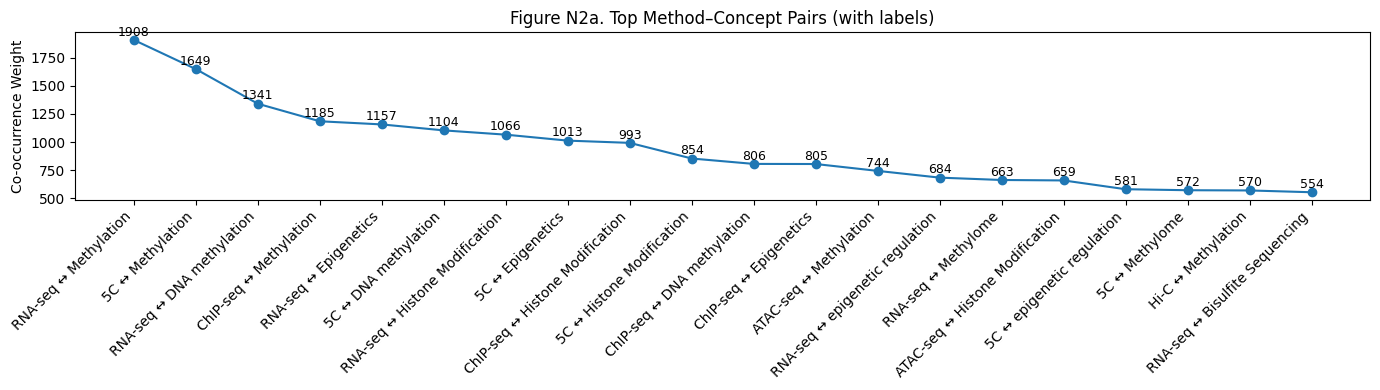

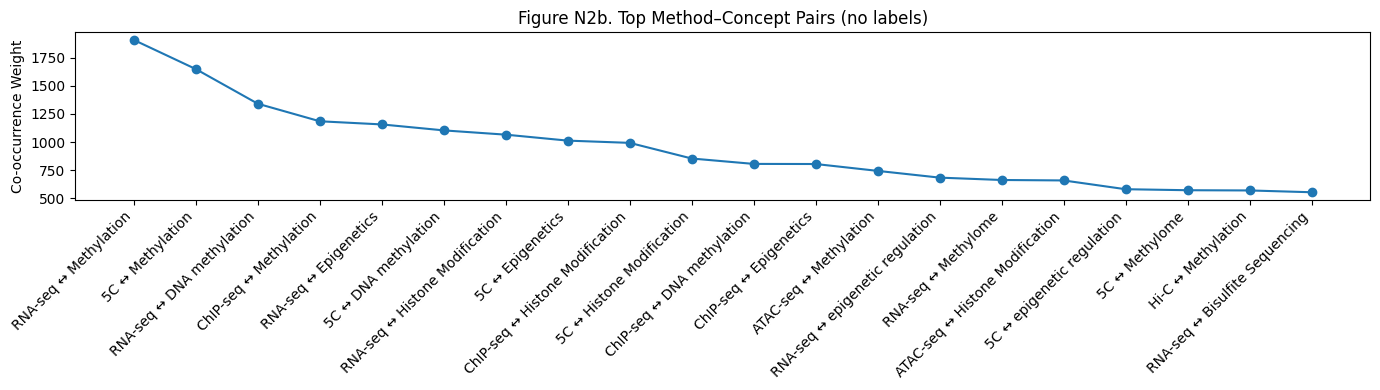

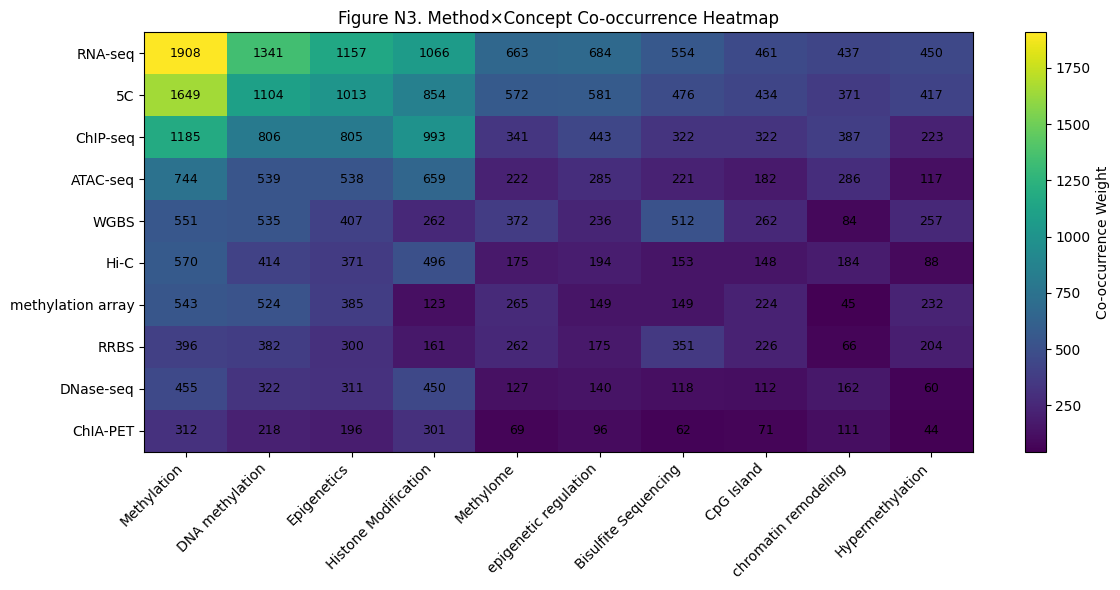


DONE. Output folder:
- /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_line


In [ ]:
# =========================================
# Colab: Method–Concept Network Analysis (Bipartite, Figure N1 REMOVED)
# - Full-text .txt corpus
# - Method–Concept co-occurrence
# - Outputs:
#   (1) Edge list CSV
#   (2) Node stats CSV
#   (3) Table N1: Top co-occurrence pairs
#   (4) Figure N2a/N2b: Line plots (with / without labels)
#   (5) Figure N3: Method×Concept heatmap (optional)
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# =========================
# 1) PATHS
# =========================
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR    = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/method_concept_network_240126_line"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) KEYWORDS
# =========================
method_keywords = [
    "5C", "ChIA-PET", "Hi-C", "DNase-seq", "FAIRE-seq",
    "ATAC-seq", "ChIP-seq", "WGBS", "RRBS",
    "methylation array", "RNA-seq", "CLIP-seq", "RIP-seq"
]

concept_keywords = [
    "DNA methylation", "Methylation", "CpG Island",
    "Hypermethylation", "Hypomethylation",
    "Epigenetics", "Histone Modification",
    "Gene Silencing", "DNMT", "Methylome",
    "Bisulfite Sequencing", "chromatin remodeling",
    "epigenetic regulation"
]

# =========================
# 3) SETTINGS
# =========================
COOC_MODE = "doc"   # "doc" or "sent"
PROGRESS_EVERY = 200
MAX_SENTENCES_PER_DOC = 2000

TOP_PAIRS_FOR_TABLE = 10
TOP_PAIRS_FOR_PLOT  = 20

MAKE_HEATMAP = True
HEATMAP_TOP_METHODS  = 10
HEATMAP_TOP_CONCEPTS = 10

# =========================
# 4) HELPERS
# =========================
def normalize_text(t):
    t = t.lower()
    return re.sub(r"\s+", " ", t)

def load_txt_files(folder):
    files = []
    for fn in sorted(os.listdir(folder)):
        if fn.lower().endswith(".txt"):
            with open(os.path.join(folder, fn), "r", encoding="utf-8", errors="ignore") as f:
                files.append((fn, f.read()))
    return files

def split_sentences(text):
    return re.split(r"(?<=[.!?])\s+", text)

def find_hits(text, kws):
    return sorted({k for k in kws if k.lower() in text})

# =========================
# 5) LOAD CORPUS
# =========================
docs = load_txt_files(CORPUS_DIR)
print("Found .txt files:", len(docs))

# =========================
# 6) BUILD CO-OCCURRENCE
# =========================
edge_w = defaultdict(int)
method_freq = Counter()
concept_freq = Counter()

matched_docs = 0
used_units = 0

for i, (_, raw) in enumerate(docs, 1):
    text = normalize_text(raw)

    if COOC_MODE == "doc":
        m_hits = find_hits(text, method_keywords)
        c_hits = find_hits(text, concept_keywords)
        if not m_hits or not c_hits:
            continue

        matched_docs += 1
        used_units += 1

        for m in m_hits:
            for c in c_hits:
                edge_w[(m, c)] += 1
        for m in m_hits:
            method_freq[m] += 1
        for c in c_hits:
            concept_freq[c] += 1

    if i % PROGRESS_EVERY == 0 or i == len(docs):
        print(f"Processed {i}/{len(docs)} docs")

print("\nDONE")
print("matched_docs:", matched_docs)
print("unique edges:", len(edge_w))

# =========================
# 7) SAVE EDGE LIST + TABLE N1
# =========================
edges_df = pd.DataFrame(
    [{"method": m, "concept": c, "weight": w} for (m, c), w in edge_w.items()]
).sort_values("weight", ascending=False)

edges_path = os.path.join(OUT_DIR, f"method_concept_edges_{COOC_MODE}.csv")
edges_df.to_csv(edges_path, index=False, encoding="utf-8-sig")

top_pairs_df = edges_df.head(TOP_PAIRS_FOR_TABLE)
table_n1_path = os.path.join(OUT_DIR, f"Table_N1_top{TOP_PAIRS_FOR_TABLE}_pairs.csv")
top_pairs_df.to_csv(table_n1_path, index=False, encoding="utf-8-sig")

print("Saved:")
print("-", edges_path)
print("-", table_n1_path)

# =========================
# 8) NODE STATS CSV
# =========================
nodes = []
for m in method_keywords:
    nodes.append({"node": m, "type": "METHOD", "freq": method_freq.get(m, 0)})
for c in concept_keywords:
    nodes.append({"node": c, "type": "CONCEPT", "freq": concept_freq.get(c, 0)})

nodes_df = pd.DataFrame(nodes)
nodes_path = os.path.join(OUT_DIR, f"method_concept_nodes_stats_{COOC_MODE}.csv")
nodes_df.to_csv(nodes_path, index=False, encoding="utf-8-sig")
print("Saved:", nodes_path)

# =========================
# 10) FIGURE N2a: Line plot (with labels)
# =========================
top_plot = edges_df.head(TOP_PAIRS_FOR_PLOT).copy()
top_plot["pair"] = top_plot["method"] + " ↔ " + top_plot["concept"]

x = range(len(top_plot))
y = top_plot["weight"].tolist()

plt.figure(figsize=(14, 4))
plt.plot(x, y, marker="o")
plt.xticks(x, top_plot["pair"], rotation=45, ha="right")
plt.ylabel("Co-occurrence Weight")
plt.title("Figure N2a. Top Method–Concept Pairs (with labels)")

for i, v in enumerate(y):
    plt.text(i, v + 0.02*max(y), str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "Figure_N2a_line_with_labels.png"), dpi=600)
plt.savefig(os.path.join(OUT_DIR, "Figure_N2a_line_with_labels.pdf"))
plt.show()

# =========================
# 11) FIGURE N2b: Line plot (no labels)
# =========================
plt.figure(figsize=(14, 4))
plt.plot(x, y, marker="o")
plt.xticks(x, top_plot["pair"], rotation=45, ha="right")
plt.ylabel("Co-occurrence Weight")
plt.title("Figure N2b. Top Method–Concept Pairs (no labels)")
plt.tight_layout()

plt.savefig(os.path.join(OUT_DIR, "Figure_N2b_line_no_labels.png"), dpi=600)
plt.savefig(os.path.join(OUT_DIR, "Figure_N2b_line_no_labels.pdf"))
plt.show()

# =========================
# 12) FIGURE N3: Heatmap (optional)
# =========================
if MAKE_HEATMAP and not edges_df.empty:
    top_m = edges_df.groupby("method")["weight"].sum().nlargest(HEATMAP_TOP_METHODS).index
    top_c = edges_df.groupby("concept")["weight"].sum().nlargest(HEATMAP_TOP_CONCEPTS).index

    mat = [[edge_w.get((m, c), 0) for c in top_c] for m in top_m]

    plt.figure(figsize=(12, 6))
    im = plt.imshow(mat, aspect="auto")
    plt.colorbar(im, label="Co-occurrence Weight")
    plt.xticks(range(len(top_c)), top_c, rotation=45, ha="right")
    plt.yticks(range(len(top_m)), top_m)
    plt.title("Figure N3. Method×Concept Co-occurrence Heatmap")

    for i in range(len(top_m)):
        for j in range(len(top_c)):
            plt.text(j, i, mat[i][j], ha="center", va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "Figure_N3_heatmap.png"), dpi=600)
    plt.savefig(os.path.join(OUT_DIR, "Figure_N3_heatmap.pdf"))
    plt.show()

print("\nDONE. Output folder:")
print("-", OUT_DIR)